# CNET 5442 — Sports Analytics Through Data and Networks (Spring 2026)

## Class 15: Pitch Passing Networks in Soccer


In the previous notebook we represented passing as a network **between players**. Here we keep the same kind of event data, but change one modeling decision: the nodes are no longer players, but **zones of the pitch**.

That sounds like a small change. It is not!! Once the nodes become spatial regions, the graph asks different questions. A player network emphasizes **who** interacted with whom. A pitch network emphasizes **where** the ball moved, which areas organized circulation, and which spatial transitions were repeated.


![](images/ppn.png)

The central lesson for today is simple:

> the event log is not itself a graph.

A graph appears only after we decide what counts as a node, what counts as an edge, what an edge weight means, which time window we care about, which pass types are included, whether self-loops are kept, and how finely we discretize the pitch.

### What you'll learn

By the end of the notebook, you should be able to

- explain why a pitch passing network is a **modeling choice** rather than a raw object sitting inside the data,
- inspect StatsBomb event data and identify the fields needed for spatial pass analysis,
- convert continuous pass coordinates into **discrete pitch zones**,
- build a **directed weighted zone-to-zone network** from event data,
- interpret adjacency matrices, self-loops, density, reciprocity, and centrality in a **zone-based** setting,
- compare a **player passing network** and a **pitch passing network** built from the same match window, and
- evaluate how time window, pass definition, and grid resolution change the network we end up studying.

## 1. Why a pitch passing network is a modeling choice

The same raw pass can support more than one graph.

In a **player passing network**, players are nodes and a directed edge $i 	o j$ records that player $i$ passed to player $j$. In a **pitch passing network**, pitch zones are nodes and a directed edge $i 	o j$ records that a pass started in zone $i$ and ended in zone $j$.

Those graphs are built from the same event log, but they answer different questions. The player graph preserves identity and role relationships. The pitch graph preserves territorial movement and repeated spatial channels.

The event log is richer than either graph. It contains timestamps, coordinates, period, team, player, pass outcome, pass type, play pattern, and much more. A network is therefore a **compression** of the event stream, not a complete description of the match.

That viewpoint is well aligned with the passing-network literature. Player-based work such as López Peña and Touchette (2012) and Grund (2012) helped establish network analysis in football. Reviews such as Buldú et al. (2018) and Caicedo-Parada et al. (2020) make clear that **space** and **time** are not optional extras. More recent pitch-network work, including Herrera-Diestra et al. (2020), Garrido et al. (2020), Narizuka et al. (2014), and Huang et al. (2025), motivates the zone-based comparisons we will build later.

Our teaching sequence will mirror that logic:

1. build the idea on a tiny toy grid,
2. construct one real network slowly on a readable classroom grid,
3. only then abstract the workflow into reusable helpers,
4. and finally compare teams, halves, windows, and grid resolutions.

In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.patches import Rectangle, Circle, Arc, FancyArrowPatch
from IPython.display import display

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10
plt.rcParams["figure.dpi"] = 120

PITCH_LENGTH = 120
PITCH_WIDTH = 80

DATA_ROOT = Path("data") / "statsbomb_open_data"

SET_PIECE_PASS_TYPES = {"Free Kick", "Corner", "Throw-in", "Goal Kick", "Kick Off"}

def official_window_clock(period, match_time):
    """Map StatsBomb's running match clock to an official 0–120 clock for 15-minute windows."""
    if pd.isna(period) or pd.isna(match_time):
        return np.nan
    if period == 1:
        return min(float(match_time), 44.999)
    if period == 2:
        return min(float(match_time), 89.999)
    if period == 3:
        return min(float(match_time), 104.999)
    if period == 4:
        return min(float(match_time), 119.999)
    return np.nan

def extract_xy(location):
    """Return the first two coordinate values from a StatsBomb location list."""
    if isinstance(location, (list, tuple)) and len(location) >= 2:
        return float(location[0]), float(location[1])
    return np.nan, np.nan

def flatten_statsbomb_events(events):
    """Flatten a raw StatsBomb event list into a dataframe with convenient pass columns."""
    df = pd.json_normalize(events, sep=".")

    if "location" not in df.columns:
        df["location"] = np.nan
    if "pass.end_location" not in df.columns:
        df["pass.end_location"] = np.nan

    df[["x", "y"]] = pd.DataFrame(df["location"].apply(extract_xy).tolist(), index=df.index)
    df[["end_x", "end_y"]] = pd.DataFrame(df["pass.end_location"].apply(extract_xy).tolist(), index=df.index)

    df["event_type"] = df["type.name"]
    df["team_name"] = df.get("team.name")
    df["player_name"] = df.get("player.name")
    df["pass_recipient_name"] = df.get("pass.recipient.name")
    df["pass_type_clean"] = df.get("pass.type.name")
    if "pass_type_clean" not in df.columns:
        df["pass_type_clean"] = np.nan
    df["pass_type_clean"] = df["pass_type_clean"].fillna("Regular")

    df["pass_outcome"] = df.get("pass.outcome.name")
    if "pass_outcome" not in df.columns:
        df["pass_outcome"] = np.nan

    df["complete"] = df["event_type"].eq("Pass") & df["pass_outcome"].isna()
    df["play_pattern_name"] = df.get("play_pattern.name")
    df["match_time"] = df["minute"].fillna(0) + df["second"].fillna(0) / 60.0
    df["window_clock"] = [
        official_window_clock(period, match_time)
        for period, match_time in zip(df["period"], df["match_time"])
    ]
    return df

def draw_statsbomb_pitch(ax, line_color="black", lw=1.2):
    """Draw a simple StatsBomb-style 120 x 80 pitch."""
    ax.add_patch(Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, ec=line_color, lw=lw))
    ax.plot([PITCH_LENGTH / 2, PITCH_LENGTH / 2], [0, PITCH_WIDTH], color=line_color, lw=lw)
    ax.add_patch(Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 10, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 0.8, color=line_color))
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Circle((12, 40), 0.8, color=line_color))
    ax.add_patch(Circle((108, 40), 0.8, color=line_color))
    ax.add_patch(Arc((12, 40), 20, 20, theta1=310, theta2=50, color=line_color, lw=lw))
    ax.add_patch(Arc((108, 40), 20, 20, theta1=130, theta2=230, color=line_color, lw=lw))
    ax.set_xlim(0, PITCH_LENGTH)
    ax.set_ylim(PITCH_WIDTH, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

def make_zone_edges(n_cols, n_rows, x_max=PITCH_LENGTH, y_max=PITCH_WIDTH):
    """Return equally spaced bin edges for a rectangular pitch grid."""
    return np.linspace(0, x_max, n_cols + 1), np.linspace(0, y_max, n_rows + 1)

def compute_bin(values, n_bins, max_value):
    """Assign coordinates to 1-indexed bins, clipping edge cases to the valid range."""
    values = np.asarray(values, dtype=float)
    edges = np.linspace(0, max_value, n_bins + 1)
    idx = np.searchsorted(edges, values, side="right") - 1
    idx = np.clip(idx, 0, n_bins - 1)
    return idx + 1

def zone_lookup_table(n_cols, n_rows):
    """Create a lookup table for zone ids, labels, boundaries, and centers."""
    x_edges, y_edges = make_zone_edges(n_cols, n_rows)
    rows = []
    for x_bin in range(1, n_cols + 1):
        for y_bin in range(1, n_rows + 1):
            zone_id = (x_bin - 1) * n_rows + y_bin
            rows.append(
                {
                    "zone_id": zone_id,
                    "zone_label": f"x{x_bin}_y{y_bin}",
                    "x_bin": x_bin,
                    "y_bin": y_bin,
                    "x0": float(x_edges[x_bin - 1]),
                    "x1": float(x_edges[x_bin]),
                    "y0": float(y_edges[y_bin - 1]),
                    "y1": float(y_edges[y_bin]),
                    "x_center": float((x_edges[x_bin - 1] + x_edges[x_bin]) / 2),
                    "y_center": float((y_edges[y_bin - 1] + y_edges[y_bin]) / 2),
                }
            )
    return pd.DataFrame(rows)

def draw_pitch_grid(
    ax,
    n_cols,
    n_rows,
    line_color="0.75",
    lw=0.9,
    linestyle="--",
    label_zones=False,
    label_ids=False,
    fontsize=8,
    alpha=1.0,
):
    """Draw a rectangular grid over the pitch."""
    draw_statsbomb_pitch(ax)
    x_edges, y_edges = make_zone_edges(n_cols, n_rows)

    for x in x_edges[1:-1]:
        ax.plot([x, x], [0, PITCH_WIDTH], color=line_color, lw=lw, linestyle=linestyle, alpha=alpha)
    for y in y_edges[1:-1]:
        ax.plot([0, PITCH_LENGTH], [y, y], color=line_color, lw=lw, linestyle=linestyle, alpha=alpha)

    lookup = zone_lookup_table(n_cols, n_rows)
    if label_zones or label_ids:
        for row in lookup.itertuples():
            parts = []
            if label_ids:
                parts.append(str(row.zone_id))
            if label_zones:
                parts.append(row.zone_label)
            ax.text(
                row.x_center,
                row.y_center,
                "\n".join(parts),
                ha="center",
                va="center",
                fontsize=fontsize,
                color="0.35",
            )
    return ax

def add_zone_columns(pass_df, n_cols, n_rows):
    """Assign each pass start and end coordinate to a rectangular grid cell."""
    out = pass_df.copy()

    for col, max_value in [("x", PITCH_LENGTH), ("y", PITCH_WIDTH), ("end_x", PITCH_LENGTH), ("end_y", PITCH_WIDTH)]:
        out[col] = out[col].clip(lower=0, upper=max_value)

    out["start_x_bin"] = compute_bin(out["x"].to_numpy(), n_cols, PITCH_LENGTH)
    out["start_y_bin"] = compute_bin(out["y"].to_numpy(), n_rows, PITCH_WIDTH)
    out["end_x_bin"] = compute_bin(out["end_x"].to_numpy(), n_cols, PITCH_LENGTH)
    out["end_y_bin"] = compute_bin(out["end_y"].to_numpy(), n_rows, PITCH_WIDTH)

    out["start_zone_id"] = (out["start_x_bin"] - 1) * n_rows + out["start_y_bin"]
    out["end_zone_id"] = (out["end_x_bin"] - 1) * n_rows + out["end_y_bin"]

    out["start_zone_label"] = [f"x{x}_y{y}" for x, y in zip(out["start_x_bin"], out["start_y_bin"])]
    out["end_zone_label"] = [f"x{x}_y{y}" for x, y in zip(out["end_x_bin"], out["end_y_bin"])]
    return out

In [13]:
assert DATA_ROOT.exists(), f"Expected local data folder at {DATA_ROOT.resolve()}"

expected_paths = [
    DATA_ROOT / "competitions.json",
    DATA_ROOT / "matches" / "43" / "106.json",
    DATA_ROOT / "events",
    DATA_ROOT / "lineups",
]
for path in expected_paths:
    assert path.exists(), f"Missing required path: {path}"

with open(DATA_ROOT / "competitions.json", "r", encoding="utf-8") as f:
    competitions = json.load(f)
competitions_df = pd.DataFrame(competitions)

with open(DATA_ROOT / "matches" / "43" / "106.json", "r", encoding="utf-8") as f:
    matches = json.load(f)
matches_df = pd.json_normalize(matches, sep=".")

world_cup_2022 = competitions_df.loc[
    (competitions_df["competition_id"] == 43) & (competitions_df["season_id"] == 106),
    ["competition_id", "competition_name", "season_id", "season_name", "country_name", "match_updated"],
].copy()

focus_matches = matches_df.loc[
    matches_df["home_team.home_team_name"].isin(["Argentina", "France", "Croatia"])
    | matches_df["away_team.away_team_name"].isin(["Argentina", "France", "Croatia"]),
    [
        "match_id",
        "match_date",
        "competition_stage.name",
        "stadium.name",
        "home_team.home_team_name",
        "away_team.away_team_name",
        "home_score",
        "away_score",
    ],
].sort_values(["match_date", "match_id"]).reset_index(drop=True)

print(f"Using local data root: {DATA_ROOT.resolve()}")
display(world_cup_2022)
display(focus_matches)

Using local data root: /Users/brennan/Desktop/code/teaching/cnet5442_sp26/notebooks/class_15/data/statsbomb_open_data


,competition_id,competition_name,season_id,season_name,country_name,match_updated
29,43,FIFA World Cup,106,2022,International,2024-12-16T10:15:11.055845


,match_id,match_date,competition_stage.name,stadium.name,home_team.home_team_name,away_team.away_team_name,home_score,away_score
0,3857279,2022-11-22,Group Stage,Al Janoub Stadium,France,Australia,4,1
1,3857300,2022-11-22,Group Stage,Lusail Stadium,Argentina,Saudi Arabia,1,2
2,3857277,2022-11-23,Group Stage,Al Bayt Stadium,Morocco,Croatia,0,0
3,3857266,2022-11-26,Group Stage,Stadium 974,France,Denmark,2,1
4,3857289,2022-11-26,Group Stage,Lusail Stadium,Argentina,Mexico,2,0
5,3857281,2022-11-27,Group Stage,Sheikh Khalifa International Stadium,Croatia,Canada,4,1
6,3857264,2022-11-30,Group Stage,Stadium 974,Poland,Argentina,0,2
7,3857275,2022-11-30,Group Stage,Education City Stadium,Tunisia,France,1,0
8,3857296,2022-12-01,Group Stage,Ahmad bin Ali Stadium,Croatia,Belgium,0,0
9,3869151,2022-12-03,Round of 16,Ahmad bin Ali Stadium,Argentina,Australia,2,1


In [14]:
final_row = matches_df.loc[
    (matches_df["home_team.home_team_name"] == "Argentina")
    & (matches_df["away_team.away_team_name"] == "France")
].copy()
assert len(final_row) == 1, "Expected exactly one Argentina–France final in the local match file."

MAIN_MATCH_ID = int(final_row["match_id"].iloc[0])
MAIN_TEAM = "Argentina"
OTHER_TEAM = "France"

event_path = DATA_ROOT / "events" / f"{MAIN_MATCH_ID}.json"
lineup_path = DATA_ROOT / "lineups" / f"{MAIN_MATCH_ID}.json"
assert event_path.exists(), f"Missing event file for match {MAIN_MATCH_ID}"
assert lineup_path.exists(), f"Missing lineup file for match {MAIN_MATCH_ID}"

with open(event_path, "r", encoding="utf-8") as f:
    events = json.load(f)
with open(lineup_path, "r", encoding="utf-8") as f:
    lineups = json.load(f)

semifinal_row = matches_df.loc[
    (matches_df["home_team.home_team_name"] == "Argentina")
    & (matches_df["away_team.away_team_name"] == "Croatia")
].copy()
HAS_SEMIFINAL = len(semifinal_row) == 1

if HAS_SEMIFINAL:
    SEMIFINAL_MATCH_ID = int(semifinal_row["match_id"].iloc[0])
    semifinal_event_path = DATA_ROOT / "events" / f"{SEMIFINAL_MATCH_ID}.json"
    semifinal_lineup_path = DATA_ROOT / "lineups" / f"{SEMIFINAL_MATCH_ID}.json"
    HAS_SEMIFINAL = semifinal_event_path.exists() and semifinal_lineup_path.exists()

main_match_info = final_row[
    [
        "match_id",
        "match_date",
        "kick_off",
        "competition_stage.name",
        "stadium.name",
        "home_team.home_team_name",
        "away_team.away_team_name",
        "home_score",
        "away_score",
    ]
].reset_index(drop=True)

display(main_match_info)

print(f"Loaded {len(events):,} events and {len(lineups)} lineup records for match {MAIN_MATCH_ID}.")
print(f"Optional Argentina–Croatia semifinal comparison available locally: {HAS_SEMIFINAL}")

,match_id,match_date,kick_off,competition_stage.name,stadium.name,home_team.home_team_name,away_team.away_team_name,home_score,away_score
0,3869685,2022-12-18,17:00:00.000,Final,Lusail Stadium,Argentina,France,3,3


Loaded 4,407 events and 2 lineup records for match 3869685.
Optional Argentina–Croatia semifinal comparison available locally: False


![](images/multilayer_player_pitch_network.png)

## 3. Intro to event data and spatial coordinates

A StatsBomb event file is a **list of dictionaries**. Each dictionary is one on-ball event. Some fields appear in almost every event, such as the event type, team, period, minute, second, and location. Other fields are event-specific. Passes carry a nested `pass` dictionary. Shots carry a nested `shot` dictionary. Carries carry a nested `carry` dictionary.

That is why we will inspect one raw pass event before flattening anything into a dataframe.

In [15]:
first_event = events[0]
first_pass_event = next(event for event in events if event["type"]["name"] == "Pass")

selected_pass_preview = pd.Series(
    {
        "id": first_pass_event["id"],
        "index": first_pass_event["index"],
        "period": first_pass_event["period"],
        "minute": first_pass_event["minute"],
        "second": first_pass_event["second"],
        "team": first_pass_event["team"]["name"],
        "player": first_pass_event["player"]["name"],
        "location": first_pass_event["location"],
        "pass_recipient": first_pass_event["pass"]["recipient"]["name"],
        "pass_end_location": first_pass_event["pass"]["end_location"],
        "pass_type": first_pass_event["pass"].get("type", {}).get("name", "Regular"),
    },
    name="value",
)

print("Top-level keys in the first event:")
print(sorted(first_event.keys()))
print()
print("Keys inside the first pass event's nested pass dictionary:")
print(sorted(first_pass_event["pass"].keys()))
print()

display(selected_pass_preview.to_frame())

Top-level keys in the first event:
['duration', 'id', 'index', 'minute', 'period', 'play_pattern', 'possession', 'possession_team', 'second', 'tactics', 'team', 'timestamp', 'type']

Keys inside the first pass event's nested pass dictionary:
['angle', 'body_part', 'end_location', 'height', 'length', 'recipient', 'type']



,value
id,f651a6c4-55e3-4e0f-a178-59414ba83d6a
index,5
period,1
minute,0
second,0
team,France
player,Antoine Griezmann
location,"[61.0, 40.1]"
pass_recipient,Aurélien Djani Tchouaméni
pass_end_location,"[48.0, 43.2]"


In [16]:
events_df = flatten_statsbomb_events(events)

core_columns = [
    "index",
    "period",
    "minute",
    "second",
    "event_type",
    "team_name",
    "player_name",
    "pass_recipient_name",
    "x",
    "y",
    "end_x",
    "end_y",
    "pass_type_clean",
    "pass_outcome",
    "play_pattern_name",
]

print(f"Flattened event dataframe shape: {events_df.shape}")
display(events_df[core_columns].head(12))

event_type_counts = events_df["event_type"].value_counts().head(12).rename_axis("event_type").to_frame("count")
pass_counts_by_team_period = (
    events_df.loc[events_df["event_type"].eq("Pass")]
    .groupby(["team_name", "period"])
    .size()
    .unstack(fill_value=0)
)

display(event_type_counts)
display(pass_counts_by_team_period)

Flattened event dataframe shape: (4407, 135)


,index,period,minute,second,event_type,team_name,player_name,pass_recipient_name,x,y,end_x,end_y,pass_type_clean,pass_outcome,play_pattern_name
0,1,1,0,0,Starting XI,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,Regular,NaN,Regular Play
1,2,1,0,0,Starting XI,France,NaN,NaN,NaN,NaN,NaN,NaN,Regular,NaN,Regular Play
2,3,1,0,0,Half Start,France,NaN,NaN,NaN,NaN,NaN,NaN,Regular,NaN,Regular Play
3,4,1,0,0,Half Start,Argentina,NaN,NaN,NaN,NaN,NaN,NaN,Regular,NaN,Regular Play
4,5,1,0,0,Pass,France,Antoine Griezmann,Aurélien Djani Tchouaméni,61.0,40.1,48.0,43.2,Kick Off,NaN,From Kick Off
5,6,1,0,1,Ball Receipt*,France,Aurélien Djani Tchouaméni,NaN,48.0,43.2,NaN,NaN,Regular,NaN,From Kick Off
6,7,1,0,1,Carry,France,Aurélien Djani Tchouaméni,NaN,48.0,43.2,NaN,NaN,Regular,NaN,From Kick Off
7,8,1,0,2,Pass,France,Aurélien Djani Tchouaméni,Olivier Giroud,49.7,43.6,96.0,1.8,Regular,Out,From Kick Off
8,9,1,0,6,Ball Receipt*,France,Olivier Giroud,NaN,92.7,11.7,NaN,NaN,Regular,NaN,From Kick Off
9,10,1,0,16,Pass,Argentina,Nahuel Molina Lucero,Rodrigo Javier De Paul,22.7,80.0,36.0,75.2,Throw-in,NaN,From Throw In


,count
event_type,
Pass,1263
Ball Receipt*,1114
Carry,940
Pressure,361
Ball Recovery,115
Duel,98
Dribble,54
Block,50
Foul Committed,48


period,1,2,3,4
team_name,,,,
Argentina,312,220,90,71
France,210,266,57,37


,min,max,missing
x,1.8,120.0,0
y,0.1,80.0,0
end_x,1.8,120.0,0
end_y,0.1,80.0,0


,min,25%,50%,75%,max
team_name,,,,,
Argentina,92.2,98.725,106.55,109.025,116.6
France,89.8,102.800,108.00,108.100,113.4


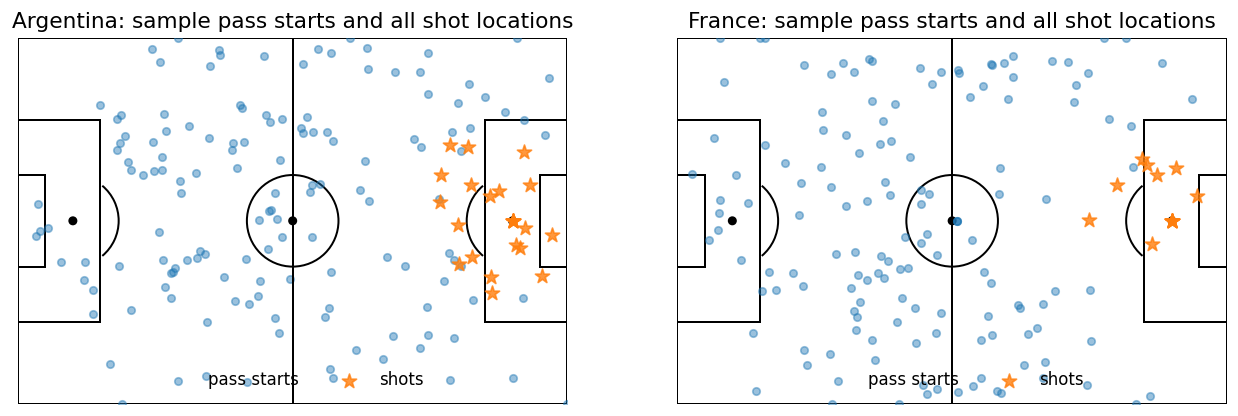

In [17]:
pass_rows = events_df.loc[events_df["event_type"].eq("Pass")].copy()
coord_summary = pd.DataFrame(
    {
        "min": pass_rows[["x", "y", "end_x", "end_y"]].min(),
        "max": pass_rows[["x", "y", "end_x", "end_y"]].max(),
        "missing": pass_rows[["x", "y", "end_x", "end_y"]].isna().sum(),
    }
)

shots = events_df.loc[
    events_df["event_type"].eq("Shot"),
    ["team_name", "x", "y", "minute", "second", "player_name", "shot.outcome.name"],
].copy()

shot_x_summary = shots.groupby("team_name")["x"].describe()[["min", "25%", "50%", "75%", "max"]]

display(coord_summary)
display(shot_x_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

for ax, team_name in zip(axes, [MAIN_TEAM, OTHER_TEAM]):
    sample = pass_rows.loc[pass_rows["team_name"].eq(team_name)].head(140)
    team_shots = shots.loc[shots["team_name"].eq(team_name)]

    draw_statsbomb_pitch(ax)
    ax.scatter(sample["x"], sample["y"], s=20, alpha=0.45, label="pass starts")
    ax.scatter(team_shots["x"], team_shots["y"], s=80, marker="*", alpha=0.8, label="shots")
    ax.set_title(f"{team_name}: sample pass starts and all shot locations")
    ax.legend(loc="lower center", ncol=2, frameon=False)

plt.show()

### A note on coordinates and attacking direction

StatsBomb open event data use a **120 × 80** coordinate system. In the final we are studying, both teams' shot locations cluster at large $x$ values. That inspection strongly suggests that, for this event file, larger $x$ behaves like **more advanced attacking territory for the team performing the action**.

That is convenient for single-team pitch-network analysis. It also means that when we compare Argentina and France side by side, we are usually comparing each team in its own attacking frame rather than in one fixed stadium frame. So the safe interpretation is not "left side of the broadcast view" versus "right side of the broadcast view." The safe interpretation is **deeper** versus **more advanced** territory for the team taking the action.

That distinction matters whenever we compare teams or halves.

## Your Turn!

Create a function to turn a 120x80 rectangle into a grid of 2 equally-sized cells.

Now 4 cells.

Now 16 cells.

Now 30 cells.


Visualize each in a multi-subplot figure.

__________

## 4. Tiny toy example: from pass coordinates to pitch zones

Before touching the real match, it helps to make the modeling move completely concrete.

We will use a tiny **3 × 2** grid. Every pass has a start coordinate $(x, y)$ and an end coordinate $(x', y')$. We will assign the start and end locations to zones, count repeated zone-to-zone transitions, and treat those counts as edge weights in a directed graph.

Nothing in this section is hidden inside a big helper function.

,pass_id,x,y,end_x,end_y
0,1,12,16,32,18
1,2,15,62,48,65
2,3,46,22,78,56
3,4,52,60,86,61
4,5,88,18,108,26
5,6,94,58,68,28
6,7,70,30,96,18
7,8,42,72,38,52


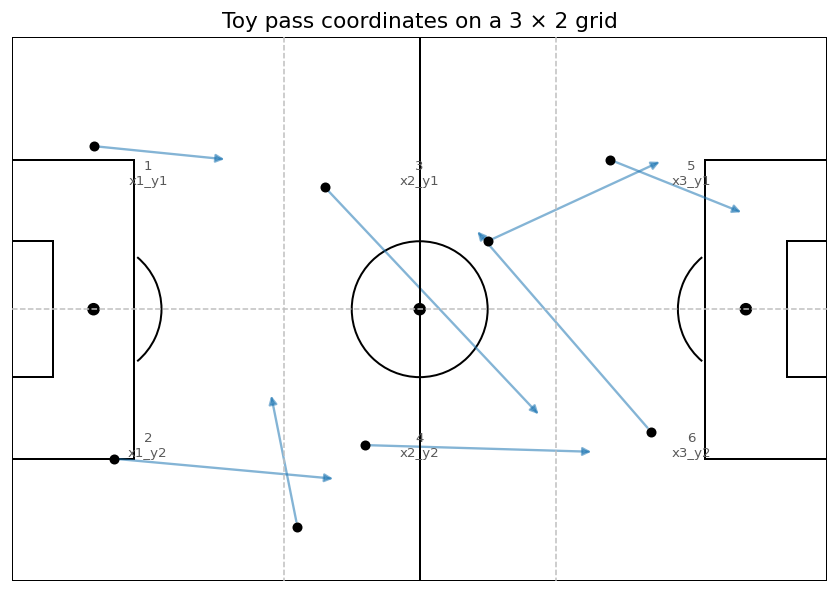

In [18]:
toy_passes = pd.DataFrame(
    {
        "pass_id": range(1, 9),
        "x": [12, 15, 46, 52, 88, 94, 70, 42],
        "y": [16, 62, 22, 60, 18, 58, 30, 72],
        "end_x": [32, 48, 78, 86, 108, 68, 96, 38],
        "end_y": [18, 65, 56, 61, 26, 28, 18, 52],
    }
)

display(toy_passes)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
draw_pitch_grid(ax, 3, 2, label_zones=True, label_ids=True, fontsize=8)

for row in toy_passes.itertuples():
    arrow = FancyArrowPatch(
        (row.x, row.y),
        (row.end_x, row.end_y),
        arrowstyle="-|>",
        mutation_scale=10,
        linewidth=1.4,
        alpha=0.55,
        shrinkA=3,
        shrinkB=3,
        color="tab:blue",
    )
    ax.add_patch(arrow)
    ax.scatter([row.x], [row.y], s=25, color="black", zorder=5)

ax.set_title("Toy pass coordinates on a 3 × 2 grid")
plt.show()

In [19]:
toy_zoned = toy_passes.copy()

toy_zoned["start_x_bin"] = compute_bin(toy_zoned["x"], n_bins=3, max_value=PITCH_LENGTH)
toy_zoned["start_y_bin"] = compute_bin(toy_zoned["y"], n_bins=2, max_value=PITCH_WIDTH)
toy_zoned["end_x_bin"] = compute_bin(toy_zoned["end_x"], n_bins=3, max_value=PITCH_LENGTH)
toy_zoned["end_y_bin"] = compute_bin(toy_zoned["end_y"], n_bins=2, max_value=PITCH_WIDTH)

toy_zoned["start_zone_label"] = [
    f"x{x}_y{y}" for x, y in zip(toy_zoned["start_x_bin"], toy_zoned["start_y_bin"])
]
toy_zoned["end_zone_label"] = [
    f"x{x}_y{y}" for x, y in zip(toy_zoned["end_x_bin"], toy_zoned["end_y_bin"])
]

assert toy_zoned.loc[0, "start_zone_label"] == "x1_y1"
assert toy_zoned.loc[0, "end_zone_label"] == "x1_y1"
assert toy_zoned.loc[3, "start_zone_label"] == "x2_y2"
assert toy_zoned.loc[4, "end_zone_label"] == "x3_y1"

display(
    toy_zoned[
        [
            "pass_id",
            "x",
            "y",
            "end_x",
            "end_y",
            "start_x_bin",
            "start_y_bin",
            "end_x_bin",
            "end_y_bin",
            "start_zone_label",
            "end_zone_label",
        ]
    ]
)

,pass_id,x,y,end_x,end_y,start_x_bin,start_y_bin,end_x_bin,end_y_bin,start_zone_label,end_zone_label
0,1,12,16,32,18,1,1,1,1,x1_y1,x1_y1
1,2,15,62,48,65,1,2,2,2,x1_y2,x2_y2
2,3,46,22,78,56,2,1,2,2,x2_y1,x2_y2
3,4,52,60,86,61,2,2,3,2,x2_y2,x3_y2
4,5,88,18,108,26,3,1,3,1,x3_y1,x3_y1
5,6,94,58,68,28,3,2,2,1,x3_y2,x2_y1
6,7,70,30,96,18,2,1,3,1,x2_y1,x3_y1
7,8,42,72,38,52,2,2,1,2,x2_y2,x1_y2


,start_zone_label,end_zone_label,weight
0,x1_y1,x1_y1,1
1,x1_y2,x2_y2,1
2,x2_y1,x2_y2,1
3,x2_y1,x3_y1,1
4,x2_y2,x1_y2,1
5,x2_y2,x3_y2,1
6,x3_y1,x3_y1,1
7,x3_y2,x2_y1,1


end_zone_label,x1_y1,x1_y2,x2_y1,x2_y2,x3_y1,x3_y2
start_zone_label,,,,,,
x1_y1,1,0,0,0,0,0
x1_y2,0,0,0,1,0,0
x2_y1,0,0,0,1,1,0
x2_y2,0,1,0,0,0,1
x3_y1,0,0,0,0,1,0
x3_y2,0,0,1,0,0,0


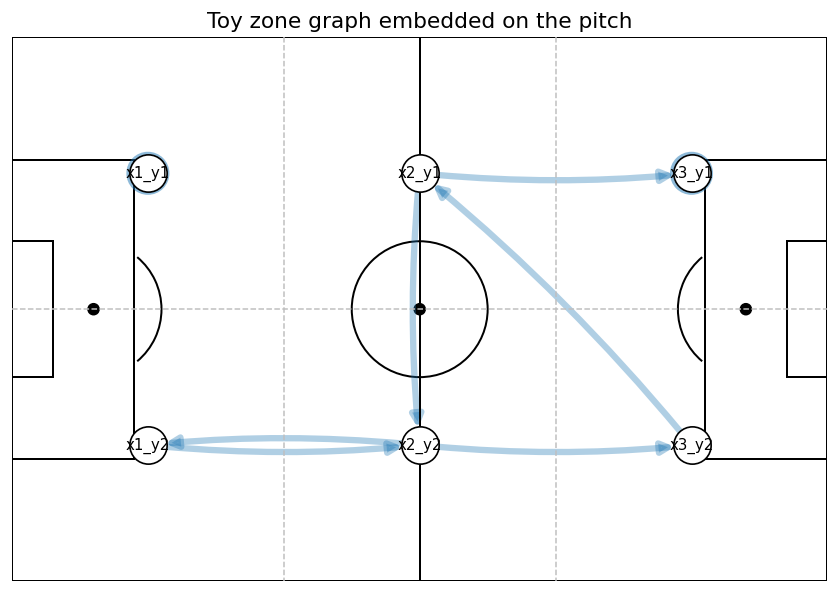

In [20]:
toy_edge_df = (
    toy_zoned.groupby(["start_zone_label", "end_zone_label"], as_index=False)
    .size()
    .rename(columns={"size": "weight"})
    .sort_values(["weight", "start_zone_label", "end_zone_label"], ascending=[False, True, True])
    .reset_index(drop=True)
)

toy_zone_order = [f"x{x}_y{y}" for x in range(1, 4) for y in range(1, 3)]
toy_adjacency = (
    toy_edge_df.pivot(index="start_zone_label", columns="end_zone_label", values="weight")
    .reindex(index=toy_zone_order, columns=toy_zone_order)
    .fillna(0)
    .astype(int)
)

toy_lookup = zone_lookup_table(3, 2)

toy_graph = nx.DiGraph()
for row in toy_lookup.itertuples():
    toy_graph.add_node(
        row.zone_label,
        x=row.x_center,
        y=row.y_center,
        zone_id=row.zone_id,
    )
for row in toy_edge_df.itertuples():
    toy_graph.add_edge(row.start_zone_label, row.end_zone_label, weight=int(row.weight))

assert toy_adjacency.to_numpy().sum() == len(toy_passes)

display(toy_edge_df)
display(toy_adjacency)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
draw_pitch_grid(ax, 3, 2, label_zones=True, fontsize=8)

max_weight = max((data["weight"] for _, _, data in toy_graph.edges(data=True)), default=1)

for source, target, data in toy_graph.edges(data=True):
    x1, y1 = toy_graph.nodes[source]["x"], toy_graph.nodes[source]["y"]
    x2, y2 = toy_graph.nodes[target]["x"], toy_graph.nodes[target]["y"]

    if source == target:
        ax.add_patch(
            Circle(
                (x1, y1),
                radius=2.8,
                fill=False,
                ec="tab:blue",
                lw=1.0 + 2.0 * data["weight"] / max_weight,
                alpha=0.5,
            )
        )
    else:
        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=10 + 4 * data["weight"] / max_weight,
            linewidth=0.8 + 3.0 * data["weight"] / max_weight,
            color="tab:blue",
            alpha=0.35,
            shrinkA=10,
            shrinkB=10,
            connectionstyle="arc3,rad=0.05",
        )
        ax.add_patch(arrow)

ax.scatter(
    toy_lookup["x_center"],
    toy_lookup["y_center"],
    s=500,
    facecolor="white",
    edgecolor="black",
    zorder=4,
)
for row in toy_lookup.itertuples():
    ax.text(row.x_center, row.y_center, row.zone_label, ha="center", va="center", fontsize=9, zorder=5)

ax.set_title("Toy zone graph embedded on the pitch")
plt.show()

Each row of the toy edge list is now a **zone-to-zone transition**. If a pass starts and ends in the same zone, we get a **self-loop**. In this setting, a self-loop means local circulation inside one cell, not literal immobility.

The toy example already contains the whole logic of a pitch passing network:

1. keep start and end coordinates,
2. assign each coordinate pair to a zone,
3. count repeated start-zone $	o$ end-zone transitions,
4. treat those counts as directed edge weights.

Now we will do the same thing with real event data.

## 5. Discretizing the pitch

The event data give us **continuous** coordinates. A pitch passing network needs **discrete** nodes. So we must choose a partition of the field.

That choice is part of the model, not a technical footnote.

A coarser grid is easier to read but collapses distinct tactical actions into the same zone. A finer grid preserves more detail but creates a larger and sparser graph. We will use three scales for three different teaching purposes:

- **3 × 2** for the tiny toy logic,
- **6 × 4** for the first full classroom build,
- **7 × 7** later for finer centrality maps and sensitivity analysis.

We will index zones as `x{column}_y{row}`. Columns increase from left to right in the attacking frame. Rows increase from top to bottom in the plot, following the underlying coordinate system.

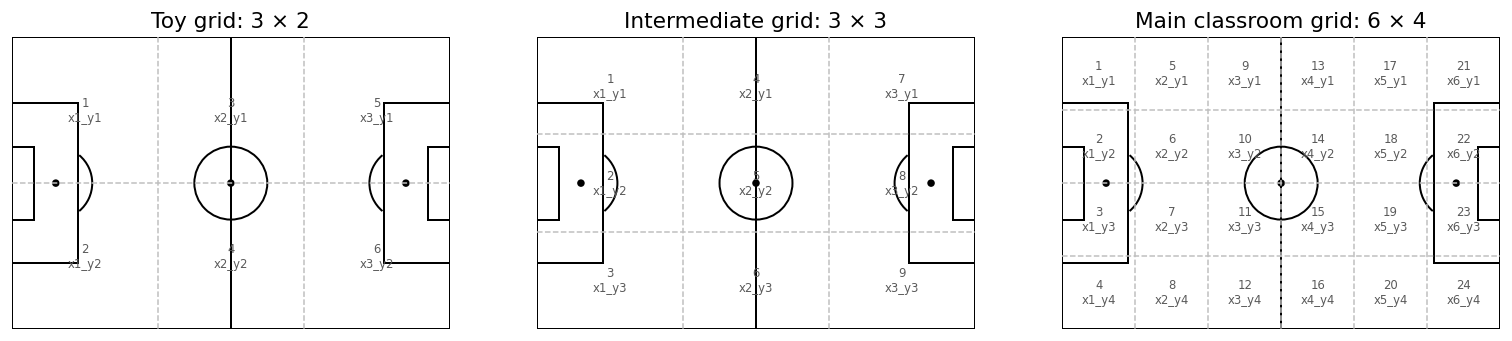

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)

for ax, (n_cols, n_rows, title) in zip(
    axes,
    [
        (3, 2, "Toy grid: 3 × 2"),
        (3, 3, "Intermediate grid: 3 × 3"),
        (6, 4, "Main classroom grid: 6 × 4"),
    ],
):
    draw_pitch_grid(ax, n_cols, n_rows, label_zones=True, label_ids=True, fontsize=7)
    ax.set_title(title)

plt.show()

In [22]:
lookup_64 = zone_lookup_table(6, 4)
display(lookup_64.head(12))
display(lookup_64.tail(4))

zone_size_summary = pd.DataFrame(
    {
        "grid": ["3 × 2", "6 × 4", "7 × 7"],
        "zones": [6, 24, 49],
        "cell_length": [PITCH_LENGTH / 3, PITCH_LENGTH / 6, PITCH_LENGTH / 7],
        "cell_width": [PITCH_WIDTH / 2, PITCH_WIDTH / 4, PITCH_WIDTH / 7],
    }
)
display(zone_size_summary.round(2))

,zone_id,zone_label,x_bin,y_bin,x0,x1,y0,y1,x_center,y_center
0,1,x1_y1,1,1,0.0,20.0,0.0,20.0,10.0,10.0
1,2,x1_y2,1,2,0.0,20.0,20.0,40.0,10.0,30.0
2,3,x1_y3,1,3,0.0,20.0,40.0,60.0,10.0,50.0
3,4,x1_y4,1,4,0.0,20.0,60.0,80.0,10.0,70.0
4,5,x2_y1,2,1,20.0,40.0,0.0,20.0,30.0,10.0
5,6,x2_y2,2,2,20.0,40.0,20.0,40.0,30.0,30.0
6,7,x2_y3,2,3,20.0,40.0,40.0,60.0,30.0,50.0
7,8,x2_y4,2,4,20.0,40.0,60.0,80.0,30.0,70.0
8,9,x3_y1,3,1,40.0,60.0,0.0,20.0,50.0,10.0
9,10,x3_y2,3,2,40.0,60.0,20.0,40.0,50.0,30.0


,zone_id,zone_label,x_bin,y_bin,x0,x1,y0,y1,x_center,y_center
20,21,x6_y1,6,1,100.0,120.0,0.0,20.0,110.0,10.0
21,22,x6_y2,6,2,100.0,120.0,20.0,40.0,110.0,30.0
22,23,x6_y3,6,3,100.0,120.0,40.0,60.0,110.0,50.0
23,24,x6_y4,6,4,100.0,120.0,60.0,80.0,110.0,70.0


,grid,zones,cell_length,cell_width
0,3 × 2,6,40.00,40.00
1,6 × 4,24,20.00,20.00
2,7 × 7,49,17.14,11.43


## 6. Choosing the main worked example and pass definition

For the first full real-data construction we will keep the slice very explicit:

- **match:** Argentina vs France, 2022 World Cup final,
- **team:** Argentina,
- **time window:** first half,
- **pass set:** completed passes,
- **pass-type filter:** keep open-play-like passes and remove obvious set-piece categories,
- **self-loops:** keep them in the full graph, then remove them only when we compute path-based metrics.

Why inspect the pass types first? Because the event log schema matters. In StatsBomb open data, many ordinary passes have missing `pass.type.name`, which we cleaned into `Regular`. Set pieces such as corners, free kicks, throw-ins, goal kicks, and kick-offs can dominate certain locations for reasons that are different from open-play circulation, so we will exclude them for the main build and revisit that choice later.

In [23]:
argentina_h1_all_passes = events_df.loc[
    events_df["event_type"].eq("Pass")
    & events_df["team_name"].eq(MAIN_TEAM)
    & events_df["period"].eq(1)
].copy()

pass_type_table = (
    argentina_h1_all_passes.groupby("pass_type_clean")
    .agg(
        attempted_passes=("id", "size"),
        completed_passes=("complete", "sum"),
    )
    .sort_values("attempted_passes", ascending=False)
)

filter_counts = pd.DataFrame(
    {
        "stage": [
            "All Argentina first-half pass attempts",
            "Completed Argentina first-half passes",
            "Completed passes after removing set-piece pass types",
        ],
        "count": [
            len(argentina_h1_all_passes),
            int(argentina_h1_all_passes["complete"].sum()),
            int(
                argentina_h1_all_passes.loc[
                    argentina_h1_all_passes["complete"]
                    & ~argentina_h1_all_passes["pass_type_clean"].isin(SET_PIECE_PASS_TYPES)
                ].shape[0]
            ),
        ],
    }
)

display(pass_type_table)
display(filter_counts)
print("Set-piece pass types excluded in the main build:", sorted(SET_PIECE_PASS_TYPES))

,attempted_passes,completed_passes
pass_type_clean,,
Regular,254,221
Recovery,33,25
Free Kick,10,8
Throw-in,9,7
Interception,4,4
Corner,2,0


,stage,count
0,All Argentina first-half pass attempts,312
1,Completed Argentina first-half passes,265
2,Completed passes after removing set-piece pass...,250


Set-piece pass types excluded in the main build: ['Corner', 'Free Kick', 'Goal Kick', 'Kick Off', 'Throw-in']


In [24]:
arg_h1_passes = (
    events_df.loc[
        events_df["event_type"].eq("Pass")
        & events_df["team_name"].eq(MAIN_TEAM)
        & events_df["period"].eq(1)
        & events_df["complete"]
        & ~events_df["pass_type_clean"].isin(SET_PIECE_PASS_TYPES)
    ,
        [
            "id",
            "index",
            "period",
            "minute",
            "second",
            "match_time",
            "team_name",
            "player_name",
            "pass_recipient_name",
            "pass_type_clean",
            "play_pattern_name",
            "x",
            "y",
            "end_x",
            "end_y",
        ],
    ]
    .dropna(subset=["x", "y", "end_x", "end_y"])
    .reset_index(drop=True)
)

assert len(arg_h1_passes) == 250, "Unexpected main-slice pass count."

print(f"Main worked example pass count: {len(arg_h1_passes)} completed open-play-like Argentina passes in period 1.")
display(arg_h1_passes.head(12))

Main worked example pass count: 250 completed open-play-like Argentina passes in period 1.


,id,index,period,minute,second,match_time,team_name,player_name,pass_recipient_name,pass_type_clean,play_pattern_name,x,y,end_x,end_y
0,59420b0c-94cc-4fb8-86fb-e1105936f6eb,19,1,0,34,0.566667,Argentina,Cristian Gabriel Romero,Nicolás Hernán Otamendi,Regular,From Free Kick,24.7,59.4,21.5,32.2
1,71cb648d-11fe-4275-b838-cbcfc62bee04,22,1,0,39,0.650000,Argentina,Nicolás Hernán Otamendi,Cristian Gabriel Romero,Regular,From Free Kick,24.0,27.1,21.7,49.3
2,4fd86774-8f37-4ea2-b562-b1a43c5adedf,25,1,0,43,0.716667,Argentina,Cristian Gabriel Romero,Nicolás Hernán Otamendi,Regular,From Free Kick,22.1,49.8,24.0,27.3
3,4a4fd288-9139-4987-9c2a-3ab0e1793310,28,1,0,45,0.750000,Argentina,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,Regular,From Free Kick,21.7,24.5,26.6,3.1
4,bdf6b02c-1c04-4777-9617-bf73ececbf6c,32,1,0,47,0.783333,Argentina,Nicolás Alejandro Tagliafico,Alexis Mac Allister,Regular,From Free Kick,29.2,2.5,45.6,4.2
5,03684593-83f8-4faa-9039-721b694edad8,40,1,1,4,1.066667,Argentina,Nicolás Hernán Otamendi,Cristian Gabriel Romero,Regular,From Free Kick,21.7,17.7,19.7,33.3
6,b90345b4-bb59-44ab-a670-08eb54053252,43,1,1,12,1.200000,Argentina,Cristian Gabriel Romero,Nicolás Hernán Otamendi,Regular,From Free Kick,30.9,42.5,27.9,22.6
7,7897d215-0dda-4db9-91d1-cc80e1a70920,46,1,1,17,1.283333,Argentina,Nicolás Hernán Otamendi,Cristian Gabriel Romero,Regular,From Free Kick,29.8,29.2,27.0,45.9
8,1323f1d6-6eae-458b-8113-a170c40afd7f,49,1,1,22,1.366667,Argentina,Cristian Gabriel Romero,Nicolás Hernán Otamendi,Regular,From Free Kick,32.1,54.5,25.9,31.6
9,833d1fbd-c458-4b27-8ff5-c6d349d8edc9,52,1,1,24,1.400000,Argentina,Nicolás Hernán Otamendi,Damián Emiliano Martínez,Regular,From Free Kick,24.7,29.0,5.6,42.3


In [25]:
arg_h1_zoned_64 = add_zone_columns(arg_h1_passes, n_cols=6, n_rows=4)

display(
    arg_h1_zoned_64[
        [
            "minute",
            "second",
            "player_name",
            "pass_recipient_name",
            "x",
            "y",
            "end_x",
            "end_y",
            "start_zone_label",
            "end_zone_label",
        ]
    ].head(12)
)

zone_diagnostic = pd.DataFrame(
    {
        "top_start_zones": arg_h1_zoned_64["start_zone_label"].value_counts().head(8),
        "top_end_zones": arg_h1_zoned_64["end_zone_label"].value_counts().head(8),
    }
)
display(zone_diagnostic.fillna(""))

,minute,second,player_name,pass_recipient_name,x,y,end_x,end_y,start_zone_label,end_zone_label
0,0,34,Cristian Gabriel Romero,Nicolás Hernán Otamendi,24.7,59.4,21.5,32.2,x2_y3,x2_y2
1,0,39,Nicolás Hernán Otamendi,Cristian Gabriel Romero,24.0,27.1,21.7,49.3,x2_y2,x2_y3
2,0,43,Cristian Gabriel Romero,Nicolás Hernán Otamendi,22.1,49.8,24.0,27.3,x2_y3,x2_y2
3,0,45,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,21.7,24.5,26.6,3.1,x2_y2,x2_y1
4,0,47,Nicolás Alejandro Tagliafico,Alexis Mac Allister,29.2,2.5,45.6,4.2,x2_y1,x3_y1
5,1,4,Nicolás Hernán Otamendi,Cristian Gabriel Romero,21.7,17.7,19.7,33.3,x2_y1,x1_y2
6,1,12,Cristian Gabriel Romero,Nicolás Hernán Otamendi,30.9,42.5,27.9,22.6,x2_y3,x2_y2
7,1,17,Nicolás Hernán Otamendi,Cristian Gabriel Romero,29.8,29.2,27.0,45.9,x2_y2,x2_y3
8,1,22,Cristian Gabriel Romero,Nicolás Hernán Otamendi,32.1,54.5,25.9,31.6,x2_y3,x2_y2
9,1,24,Nicolás Hernán Otamendi,Damián Emiliano Martínez,24.7,29.0,5.6,42.3,x2_y2,x1_y3


,top_start_zones,top_end_zones
x1_y3,13.0,
x2_y2,27.0,26.0
x2_y3,21.0,17.0
x3_y1,17.0,21.0
x3_y2,21.0,22.0
x3_y3,20.0,20.0
x3_y4,,17.0
x4_y1,17.0,15.0
x5_y1,14.0,14.0


In [26]:
edge_df_64 = (
    arg_h1_zoned_64.groupby(
        [
            "start_zone_id",
            "end_zone_id",
            "start_zone_label",
            "end_zone_label",
            "start_x_bin",
            "start_y_bin",
            "end_x_bin",
            "end_y_bin",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "weight"})
    .sort_values(["weight", "start_zone_id", "end_zone_id"], ascending=[False, True, True])
    .reset_index(drop=True)
)

zone_order_64 = lookup_64.sort_values("zone_id")["zone_label"].tolist()
adjacency_64 = (
    edge_df_64.pivot(index="start_zone_label", columns="end_zone_label", values="weight")
    .reindex(index=zone_order_64, columns=zone_order_64)
    .fillna(0)
    .astype(int)
)

G_zone_full_64 = nx.DiGraph(n_cols=6, n_rows=4, team=MAIN_TEAM, period=1)

for row in lookup_64.itertuples():
    G_zone_full_64.add_node(
        row.zone_id,
        zone_label=row.zone_label,
        x_bin=int(row.x_bin),
        y_bin=int(row.y_bin),
        x_center=float(row.x_center),
        y_center=float(row.y_center),
    )

for row in edge_df_64.itertuples():
    G_zone_full_64.add_edge(
        int(row.start_zone_id),
        int(row.end_zone_id),
        weight=int(row.weight),
        distance=1.0 / float(row.weight),
    )

start_counts_64 = arg_h1_zoned_64["start_zone_id"].value_counts()
end_counts_64 = arg_h1_zoned_64["end_zone_id"].value_counts()
within_counts_64 = arg_h1_zoned_64.loc[
    arg_h1_zoned_64["start_zone_id"].eq(arg_h1_zoned_64["end_zone_id"]),
    "start_zone_id",
].value_counts()

zone_table_64_manual = lookup_64.copy()
zone_table_64_manual["start_count"] = zone_table_64_manual["zone_id"].map(start_counts_64).fillna(0).astype(int)
zone_table_64_manual["end_count"] = zone_table_64_manual["zone_id"].map(end_counts_64).fillna(0).astype(int)
zone_table_64_manual["involvement"] = zone_table_64_manual["start_count"] + zone_table_64_manual["end_count"]
zone_table_64_manual["within_count"] = zone_table_64_manual["zone_id"].map(within_counts_64).fillna(0).astype(int)

for row in zone_table_64_manual.itertuples():
    G_zone_full_64.nodes[row.zone_id]["start_count"] = int(row.start_count)
    G_zone_full_64.nodes[row.zone_id]["end_count"] = int(row.end_count)
    G_zone_full_64.nodes[row.zone_id]["involvement"] = int(row.involvement)
    G_zone_full_64.nodes[row.zone_id]["within_count"] = int(row.within_count)

assert adjacency_64.to_numpy().sum() == len(arg_h1_zoned_64)

manual_summary_64 = pd.Series(
    {
        "nodes": G_zone_full_64.number_of_nodes(),
        "edges_including_loops": G_zone_full_64.number_of_edges(),
        "total_passes": adjacency_64.to_numpy().sum(),
        "occupied_zones": int((zone_table_64_manual["involvement"] > 0).sum()),
        "within_zone_passes": int(
            edge_df_64.loc[edge_df_64["start_zone_id"].eq(edge_df_64["end_zone_id"]), "weight"].sum()
        ),
    },
    name="value",
)

display(edge_df_64.head(20))
display(adjacency_64)
display(manual_summary_64.to_frame())

,start_zone_id,end_zone_id,start_zone_label,end_zone_label,start_x_bin,start_y_bin,end_x_bin,end_y_bin,weight
0,7,6,x2_y3,x2_y2,2,3,2,2,9
1,10,10,x3_y2,x3_y2,3,2,3,2,9
2,17,17,x5_y1,x5_y1,5,1,5,1,9
3,6,6,x2_y2,x2_y2,2,2,2,2,7
4,6,9,x2_y2,x3_y1,2,2,3,1,6
5,9,5,x3_y1,x2_y1,3,1,2,1,6
6,13,13,x4_y1,x4_y1,4,1,4,1,6
7,8,12,x2_y4,x3_y4,2,4,3,4,5
8,9,10,x3_y1,x3_y2,3,1,3,2,5
9,13,9,x4_y1,x3_y1,4,1,3,1,5


end_zone_label,x1_y1,x1_y2,x1_y3,x1_y4,x2_y1,x2_y2,x2_y3,x2_y4,x3_y1,x3_y2,...,x4_y3,x4_y4,x5_y1,x5_y2,x5_y3,x5_y4,x6_y1,x6_y2,x6_y3,x6_y4
start_zone_label,,,,,,,,,,,,,,,,,,,,,
x1_y1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
x1_y2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
x1_y3,0,0,3,0,0,2,4,2,0,0,...,0,0,0,0,0,0,0,0,0,0
x1_y4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
x2_y1,1,2,1,0,1,1,1,0,3,0,...,0,0,0,0,0,0,0,0,0,0
x2_y2,0,0,3,0,3,7,4,0,6,1,...,0,0,0,0,0,0,0,0,0,0
x2_y3,0,0,1,0,0,9,3,1,0,1,...,0,0,0,0,0,0,0,0,0,0
x2_y4,0,0,0,1,0,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
x3_y1,0,0,0,0,6,0,1,0,4,5,...,0,0,0,0,0,0,0,0,0,0


,value
nodes,24
edges_including_loops,117
total_passes,250
occupied_zones,24
within_zone_passes,64


## 7. Visualizing the pitch passing network

No single figure tells the whole story. A pitch passing network is easier to understand when we look at it in several complementary ways.

We will use four views of the same Argentina first-half 6 × 4 network:

1. a **zone heatmap** for how involved each cell was,
2. a **pitch-embedded node-link view** that preserves space,
3. an **adjacency-matrix heatmap** that emphasizes the transition counts directly,
4. and an **abstract graph layout** that shows connectivity while ignoring geography.

Each view reveals something and hides something.

In [27]:
def scale_values(values, min_size=80, max_size=700):
    """Scale an array of values into marker sizes."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    if np.allclose(values.max(), values.min()):
        return np.full(values.shape, 0.5 * (min_size + max_size))
    return min_size + (values - values.min()) * (max_size - min_size) / (values.max() - values.min())

def metric_matrix(zone_table, metric, n_cols, n_rows):
    """Map a zone-level metric table into a matrix laid out like the pitch grid."""
    matrix = np.zeros((n_rows, n_cols), dtype=float)
    for row in zone_table.itertuples():
        matrix[int(row.y_bin) - 1, int(row.x_bin) - 1] = getattr(row, metric)
    return matrix

def plot_zone_heatmap(
    zone_table,
    metric,
    n_cols,
    n_rows,
    ax=None,
    cmap="Reds",
    title=None,
    vmin=None,
    vmax=None,
    annotate=False,
    fmt="{:.0f}",
    colorbar=True,
    cbar_label=None,
):
    """Plot a zone-level metric as a heatmap over the pitch."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

    matrix = metric_matrix(zone_table, metric, n_cols, n_rows)

    if vmin is None:
        vmin = float(np.nanmin(matrix)) if matrix.size else 0.0
    if vmax is None:
        vmax = float(np.nanmax(matrix)) if matrix.size else 1.0
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-9

    im = ax.imshow(
        matrix,
        extent=(0, PITCH_LENGTH, PITCH_WIDTH, 0),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=0.78,
    )

    draw_statsbomb_pitch(ax)
    x_edges, y_edges = make_zone_edges(n_cols, n_rows)
    for x in x_edges[1:-1]:
        ax.plot([x, x], [0, PITCH_WIDTH], color="white", lw=1.0, alpha=0.8)
    for y in y_edges[1:-1]:
        ax.plot([0, PITCH_LENGTH], [y, y], color="white", lw=1.0, alpha=0.8)

    if annotate:
        lookup = zone_lookup_table(n_cols, n_rows)
        for row in lookup.itertuples():
            value = matrix[row.y_bin - 1, row.x_bin - 1]
            norm_value = 0.0 if np.isclose(vmax, vmin) else (value - vmin) / (vmax - vmin)
            text_color = "white" if norm_value > 0.62 else "black"
            ax.text(
                row.x_center,
                row.y_center,
                fmt.format(value),
                ha="center",
                va="center",
                fontsize=7,
                color=text_color,
            )

    if title:
        ax.set_title(title)

    if colorbar:
        cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label(cbar_label or metric.replace("_", " ").title())

    return im

def plot_zone_network_on_pitch(
    G_full,
    node_values=None,
    n_cols=None,
    n_rows=None,
    ax=None,
    min_weight=2,
    top_n_edges=35,
    draw_loops=False,
    title=None,
    label_metric=False,
):
    """Plot a pitch-embedded zone graph with node size and weighted directed edges."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

    if n_cols is None:
        n_cols = G_full.graph.get("n_cols") or max(nx.get_node_attributes(G_full, "x_bin").values())
    if n_rows is None:
        n_rows = G_full.graph.get("n_rows") or max(nx.get_node_attributes(G_full, "y_bin").values())

    draw_pitch_grid(ax, n_cols, n_rows, line_color="0.82", lw=0.8, linestyle="-", alpha=0.8)

    edges = []
    for source, target, data in G_full.edges(data=True):
        if source == target and not draw_loops:
            continue
        if data["weight"] < min_weight:
            continue
        edges.append((source, target, data["weight"]))

    edges = sorted(edges, key=lambda item: item[2])
    if top_n_edges is not None and len(edges) > top_n_edges:
        edges = edges[-top_n_edges:]

    max_weight = max([weight for _, _, weight in edges], default=1)

    for source, target, weight in edges:
        if source == target:
            node = G_full.nodes[source]
            ax.add_patch(
                Circle(
                    (node["x_center"], node["y_center"]),
                    radius=2.3 + 1.2 * weight / max_weight,
                    fill=False,
                    ec="tab:blue",
                    lw=1.0 + 2.5 * weight / max_weight,
                    alpha=0.4,
                )
            )
        else:
            x1, y1 = G_full.nodes[source]["x_center"], G_full.nodes[source]["y_center"]
            x2, y2 = G_full.nodes[target]["x_center"], G_full.nodes[target]["y_center"]
            arrow = FancyArrowPatch(
                (x1, y1),
                (x2, y2),
                arrowstyle="-|>",
                mutation_scale=8 + 5 * weight / max_weight,
                linewidth=0.6 + 3.2 * weight / max_weight,
                color="tab:blue",
                alpha=0.25,
                shrinkA=8,
                shrinkB=8,
                connectionstyle="arc3,rad=0.04",
            )
            ax.add_patch(arrow)

    nodes = list(G_full.nodes())
    if node_values is None:
        node_values = {node: G_full.nodes[node].get("involvement", 0) for node in nodes}

    sizes = scale_values([node_values.get(node, 0) for node in nodes], min_size=140, max_size=900)
    xs = [G_full.nodes[node]["x_center"] for node in nodes]
    ys = [G_full.nodes[node]["y_center"] for node in nodes]

    ax.scatter(xs, ys, s=sizes, facecolor="white", edgecolors="black", linewidths=0.8, zorder=4)

    for node in nodes:
        label = G_full.nodes[node]["zone_label"]
        if label_metric:
            ax.text(
                G_full.nodes[node]["x_center"],
                G_full.nodes[node]["y_center"],
                f"{label}\n{node_values.get(node, 0):.0f}",
                ha="center",
                va="center",
                fontsize=6.4,
                zorder=5,
            )
        else:
            ax.text(
                G_full.nodes[node]["x_center"],
                G_full.nodes[node]["y_center"],
                label,
                ha="center",
                va="center",
                fontsize=6.6,
                zorder=5,
            )

    if title:
        ax.set_title(title)

    return ax

def plot_adjacency_heatmap(adjacency, ax=None, title=None, cmap="Blues", annotate=False, vmax=None):
    """Plot an adjacency matrix as a heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7), dpi=120)

    matrix = adjacency.to_numpy()
    if vmax is None:
        vmax = matrix.max() if matrix.size else 1

    im = ax.imshow(matrix, cmap=cmap, vmax=vmax)
    ax.set_xticks(range(len(adjacency.columns)))
    ax.set_yticks(range(len(adjacency.index)))
    ax.set_xticklabels(adjacency.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(adjacency.index, fontsize=7)
    ax.set_xlabel("End zone")
    ax.set_ylabel("Start zone")
    if title:
        ax.set_title(title)

    if annotate and len(adjacency) <= 10:
        for i in range(len(adjacency.index)):
            for j in range(len(adjacency.columns)):
                ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=7)

    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    return ax

def plot_abstract_zone_network(G_full, node_values=None, ax=None, min_weight=2, title=None, occupied_only=True):
    """Plot the loopless zone graph in an abstract spring layout."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

    G_path = G_full.copy()
    G_path.remove_edges_from(list(nx.selfloop_edges(G_path)))

    if occupied_only:
        keep_nodes = [node for node in G_path.nodes() if G_full.nodes[node].get("involvement", 0) > 0]
        G_path = G_path.subgraph(keep_nodes).copy()

    if G_path.number_of_nodes() == 0:
        ax.set_axis_off()
        if title:
            ax.set_title(title)
        return ax

    pos = nx.spring_layout(G_path, weight="weight", seed=7)

    edges = [(u, v, d) for u, v, d in G_path.edges(data=True) if d["weight"] >= min_weight]
    max_weight = max([d["weight"] for _, _, d in edges], default=1)

    nx.draw_networkx_edges(
        G_path,
        pos,
        ax=ax,
        edgelist=[(u, v) for u, v, _ in edges],
        width=[0.8 + 4.0 * d["weight"] / max_weight for _, _, d in edges],
        alpha=0.35,
        edge_color="tab:blue",
        arrows=True,
        arrowsize=10,
        connectionstyle="arc3,rad=0.07",
    )

    if node_values is None:
        node_values = {
            node: G_path.out_degree(node, weight="weight") + G_path.in_degree(node, weight="weight")
            for node in G_path.nodes()
        }

    sizes = scale_values([node_values.get(node, 0) for node in G_path.nodes()], min_size=160, max_size=1100)

    nx.draw_networkx_nodes(
        G_path,
        pos,
        ax=ax,
        node_size=sizes,
        node_color="white",
        edgecolors="black",
        linewidths=0.9,
    )
    nx.draw_networkx_labels(
        G_path,
        pos,
        labels={node: G_path.nodes[node]["zone_label"] for node in G_path.nodes()},
        font_size=7,
        ax=ax,
    )

    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return ax

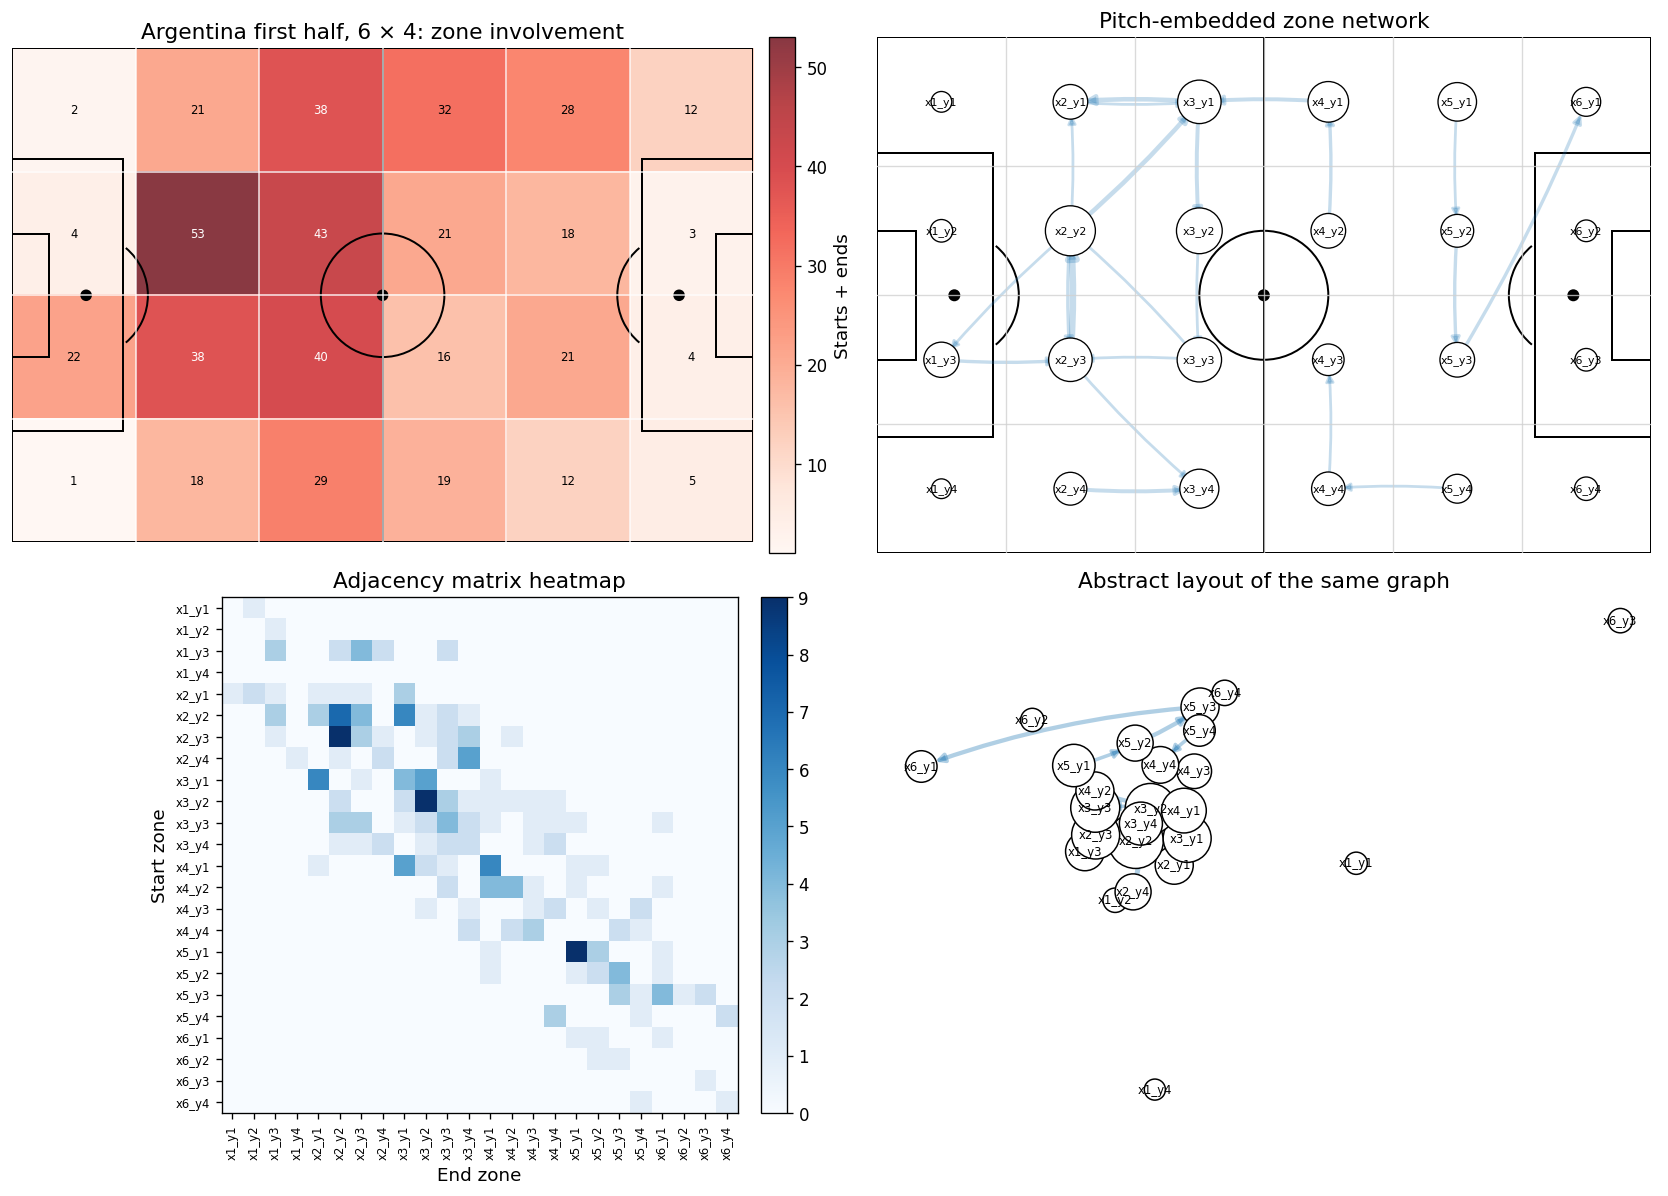

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

plot_zone_heatmap(
    zone_table_64_manual,
    metric="involvement",
    n_cols=6,
    n_rows=4,
    ax=axes[0, 0],
    cmap="Reds",
    title="Argentina first half, 6 × 4: zone involvement",
    annotate=True,
    colorbar=True,
    cbar_label="Starts + ends",
)

plot_zone_network_on_pitch(
    G_zone_full_64,
    node_values=dict(zip(zone_table_64_manual["zone_id"], zone_table_64_manual["involvement"])),
    n_cols=6,
    n_rows=4,
    ax=axes[0, 1],
    min_weight=3,
    top_n_edges=35,
    title="Pitch-embedded zone network",
)

plot_adjacency_heatmap(
    adjacency_64,
    ax=axes[1, 0],
    title="Adjacency matrix heatmap",
)

plot_abstract_zone_network(
    G_zone_full_64,
    node_values=dict(zip(zone_table_64_manual["zone_id"], zone_table_64_manual["involvement"])),
    ax=axes[1, 1],
    min_weight=3,
    title="Abstract layout of the same graph",
)

plt.tight_layout()
plt.show()

The four views are complementary.

The **pitch heatmap** preserves geography but collapses the directed transition structure. The **pitch-embedded network** preserves both geography and direction, but can become visually busy. The **adjacency matrix** makes the transition counts explicit, but geography disappears. The **abstract layout** makes connectivity easier to inspect, but no longer tells us where those nodes sit on the field.

That is why pitch-network analysis usually works best when we move back and forth between spatial and non-spatial views rather than insisting on a single hero figure.

## 8. Building reusable helper functions after the manual walkthrough

At this point we have built one real network entirely in the open. That is the right moment to package the repeated steps into reusable helpers. From here on, we want to compare teams, halves, windows, and grid resolutions without rewriting the same grouping and graph-construction code each time.

In [29]:
def prepare_pass_dataframe(
    events_df,
    team_name,
    periods=None,
    minute_min=None,
    minute_max=None,
    completed_only=True,
    open_play_like=True,
    clock_column="match_time",
):
    """Return a clean pass dataframe for one team, one time slice, and one pass definition."""
    if clock_column not in events_df.columns:
        raise KeyError(f"Clock column '{clock_column}' is not present in the event dataframe.")

    df = events_df.loc[events_df["event_type"].eq("Pass")].copy()
    df = df.loc[df["team_name"].eq(team_name)].copy()

    if periods is not None:
        if np.isscalar(periods):
            periods = [periods]
        df = df.loc[df["period"].isin(list(periods))].copy()

    if minute_min is not None:
        df = df.loc[df[clock_column] >= minute_min].copy()
    if minute_max is not None:
        df = df.loc[df[clock_column] < minute_max].copy()

    if completed_only:
        df = df.loc[df["complete"]].copy()

    if open_play_like:
        df = df.loc[~df["pass_type_clean"].isin(SET_PIECE_PASS_TYPES)].copy()

    keep_cols = [
        "id",
        "index",
        "period",
        "minute",
        "second",
        "match_time",
        "window_clock",
        "timestamp",
        "team_name",
        "player_name",
        "pass_recipient_name",
        "pass_type_clean",
        "play_pattern_name",
        "complete",
        "x",
        "y",
        "end_x",
        "end_y",
    ]

    df = df[keep_cols].dropna(subset=["x", "y", "end_x", "end_y"]).reset_index(drop=True)
    return df

def build_zone_network_from_passes(pass_df, n_cols, n_rows):
    """Convert a pass dataframe into zoned passes, an edge list, an adjacency matrix, and a zone graph."""
    zoned = add_zone_columns(pass_df, n_cols=n_cols, n_rows=n_rows)
    lookup = zone_lookup_table(n_cols, n_rows)

    edge_df = (
        zoned.groupby(
            [
                "start_zone_id",
                "end_zone_id",
                "start_zone_label",
                "end_zone_label",
                "start_x_bin",
                "start_y_bin",
                "end_x_bin",
                "end_y_bin",
            ],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "weight"})
        .sort_values(["weight", "start_zone_id", "end_zone_id"], ascending=[False, True, True])
        .reset_index(drop=True)
    )

    zone_order = lookup.sort_values("zone_id")["zone_label"].tolist()
    adjacency = (
        edge_df.pivot(index="start_zone_label", columns="end_zone_label", values="weight")
        .reindex(index=zone_order, columns=zone_order)
        .fillna(0)
        .astype(int)
    )

    G_full = nx.DiGraph(n_cols=n_cols, n_rows=n_rows)

    for row in lookup.itertuples():
        G_full.add_node(
            row.zone_id,
            zone_label=row.zone_label,
            x_bin=int(row.x_bin),
            y_bin=int(row.y_bin),
            x_center=float(row.x_center),
            y_center=float(row.y_center),
        )

    for row in edge_df.itertuples():
        G_full.add_edge(
            int(row.start_zone_id),
            int(row.end_zone_id),
            weight=int(row.weight),
            distance=1.0 / float(row.weight),
        )

    start_counts = zoned["start_zone_id"].value_counts()
    end_counts = zoned["end_zone_id"].value_counts()
    within_counts = zoned.loc[zoned["start_zone_id"].eq(zoned["end_zone_id"]), "start_zone_id"].value_counts()

    for node in G_full.nodes():
        G_full.nodes[node]["start_count"] = int(start_counts.get(node, 0))
        G_full.nodes[node]["end_count"] = int(end_counts.get(node, 0))
        G_full.nodes[node]["involvement"] = int(start_counts.get(node, 0) + end_counts.get(node, 0))
        G_full.nodes[node]["within_count"] = int(within_counts.get(node, 0))

    assert adjacency.to_numpy().sum() == len(zoned)
    return zoned, edge_df, adjacency, G_full, lookup

def build_zone_network_from_events(
    events_df,
    team_name,
    periods=None,
    minute_min=None,
    minute_max=None,
    n_cols=6,
    n_rows=4,
    completed_only=True,
    open_play_like=True,
    clock_column="match_time",
):
    """Build a pitch passing network directly from the flattened event dataframe."""
    pass_df = prepare_pass_dataframe(
        events_df,
        team_name=team_name,
        periods=periods,
        minute_min=minute_min,
        minute_max=minute_max,
        completed_only=completed_only,
        open_play_like=open_play_like,
        clock_column=clock_column,
    )

    zoned, edge_df, adjacency, G_full, lookup = build_zone_network_from_passes(
        pass_df,
        n_cols=n_cols,
        n_rows=n_rows,
    )

    G_full.graph.update(
        {
            "team_name": team_name,
            "periods": periods,
            "minute_min": minute_min,
            "minute_max": minute_max,
            "n_cols": n_cols,
            "n_rows": n_rows,
            "completed_only": completed_only,
            "open_play_like": open_play_like,
            "clock_column": clock_column,
        }
    )
    return pass_df, zoned, edge_df, adjacency, G_full, lookup

def zone_graph_without_loops(G_full):
    """Return a copy of the zone graph with self-loops removed."""
    G_path = G_full.copy()
    G_path.remove_edges_from(list(nx.selfloop_edges(G_path)))
    return G_path

def outward_harmonic_centrality(G, distance="distance"):
    """Compute outward harmonic centrality so unreachable nodes contribute zero."""
    n_nodes = G.number_of_nodes()
    scores = {}

    for source in G.nodes():
        if distance is None:
            lengths = nx.single_source_shortest_path_length(G, source)
        else:
            lengths = nx.single_source_dijkstra_path_length(G, source, weight=distance)

        total = 0.0
        for target in G.nodes():
            if target == source:
                continue
            d = lengths.get(target, np.inf)
            if np.isfinite(d) and d > 0:
                total += 1.0 / d

        scores[source] = total / max(n_nodes - 1, 1)

    return scores

def zone_metric_table(G_full):
    """Compute node-level metrics for a zone graph."""
    G_path = zone_graph_without_loops(G_full)

    out_degree = dict(G_path.out_degree())
    in_degree = dict(G_path.in_degree())
    out_strength = dict(G_full.out_degree(weight="weight"))
    in_strength = dict(G_full.in_degree(weight="weight"))

    if G_path.number_of_edges() > 0:
        out_harmonic = outward_harmonic_centrality(G_path, distance="distance")
        betweenness = nx.betweenness_centrality(G_path, weight="distance", normalized=True)
    else:
        out_harmonic = {node: 0.0 for node in G_path.nodes()}
        betweenness = {node: 0.0 for node in G_path.nodes()}

    total_passes = sum(data["weight"] for _, _, data in G_full.edges(data=True))

    rows = []
    for node, attrs in G_full.nodes(data=True):
        rows.append(
            {
                "zone_id": node,
                "zone_label": attrs["zone_label"],
                "x_bin": attrs["x_bin"],
                "y_bin": attrs["y_bin"],
                "x_center": attrs["x_center"],
                "y_center": attrs["y_center"],
                "start_count": attrs["start_count"],
                "end_count": attrs["end_count"],
                "involvement": attrs["involvement"],
                "within_count": attrs["within_count"],
                "out_degree": int(out_degree.get(node, 0)),
                "in_degree": int(in_degree.get(node, 0)),
                "out_strength": float(out_strength.get(node, 0)),
                "in_strength": float(in_strength.get(node, 0)),
                "out_strength_share": float(out_strength.get(node, 0) / total_passes) if total_passes else np.nan,
                "in_strength_share": float(in_strength.get(node, 0) / total_passes) if total_passes else np.nan,
                "involvement_share": float(attrs["involvement"] / (2 * total_passes)) if total_passes else np.nan,
                "out_harmonic": float(out_harmonic.get(node, 0.0)),
                "betweenness": float(betweenness.get(node, 0.0)),
            }
        )

    return pd.DataFrame(rows).sort_values("zone_id").reset_index(drop=True)

def network_summary(G_full):
    """Compute a compact network summary for a zone graph."""
    G_path = zone_graph_without_loops(G_full)

    total_passes = sum(data["weight"] for _, _, data in G_full.edges(data=True))
    within_zone_passes = sum(data["weight"] for u, v, data in G_full.edges(data=True) if u == v)

    out_strength = np.array([G_full.out_degree(node, weight="weight") for node in G_full.nodes()], dtype=float)
    shares = out_strength / out_strength.sum() if out_strength.sum() else np.array([])

    reciprocity_value = nx.reciprocity(G_path)

    return pd.Series(
        {
            "nodes": G_full.number_of_nodes(),
            "edges_including_loops": G_full.number_of_edges(),
            "between_zone_edges": G_path.number_of_edges(),
            "occupied_zones": int(sum(G_full.nodes[node]["involvement"] > 0 for node in G_full.nodes())),
            "total_passes": float(total_passes),
            "within_zone_passes": float(within_zone_passes),
            "within_zone_share": float(within_zone_passes / total_passes) if total_passes else np.nan,
            "density": float(nx.density(G_path)),
            "reciprocity": float(reciprocity_value) if reciprocity_value is not None else 0.0,
            "out_strength_hhi": float((shares ** 2).sum()) if len(shares) else np.nan,
        }
    )

def duration_minutes_for_periods(periods):
    """Return official scheduled minutes for a list of match periods."""
    duration_map = {1: 45, 2: 45, 3: 15, 4: 15}
    return sum(duration_map.get(period, 0) for period in periods)

In [30]:
main_pass_df, main_zoned_df, main_edge_df, main_adjacency, main_G_zone, main_lookup = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[1],
    n_cols=6,
    n_rows=4,
    completed_only=True,
    open_play_like=True,
)

assert main_adjacency.equals(adjacency_64)
assert len(main_pass_df) == len(arg_h1_passes)
assert network_summary(main_G_zone)["total_passes"] == len(arg_h1_passes)

zone_table_64 = zone_metric_table(main_G_zone)
display(network_summary(main_G_zone).round(3).to_frame("Argentina first half, 6 × 4"))
display(zone_table_64.sort_values("out_strength", ascending=False).head(10))

,"Argentina first half, 6 × 4"
nodes,24.000
edges_including_loops,117.000
between_zone_edges,98.000
occupied_zones,24.000
total_passes,250.000
within_zone_passes,64.000
within_zone_share,0.256
density,0.178
reciprocity,0.612
out_strength_hhi,0.063


,zone_id,zone_label,x_bin,y_bin,x_center,y_center,start_count,end_count,involvement,within_count,out_degree,in_degree,out_strength,in_strength,out_strength_share,in_strength_share,involvement_share,out_harmonic,betweenness
5,6,x2_y2,2,2,30.0,30.0,27,26,53,7,7,7,27.0,26.0,0.108,0.104,0.106,1.468898,0.098814
9,10,x3_y2,3,2,50.0,30.0,21,22,43,9,8,7,21.0,22.0,0.084,0.088,0.086,1.037785,0.136364
6,7,x2_y3,2,3,30.0,50.0,21,17,38,3,7,6,21.0,17.0,0.084,0.068,0.076,1.574396,0.101779
10,11,x3_y3,3,3,50.0,50.0,20,20,40,4,10,8,20.0,20.0,0.080,0.080,0.080,1.182195,0.156456
8,9,x3_y1,3,1,50.0,10.0,17,21,38,4,4,5,17.0,21.0,0.068,0.084,0.076,1.243172,0.219368
12,13,x4_y1,4,1,70.0,10.0,17,15,32,6,6,6,17.0,15.0,0.068,0.060,0.064,1.115559,0.144269
16,17,x5_y1,5,1,90.0,10.0,14,14,28,9,3,5,14.0,14.0,0.056,0.056,0.056,0.752926,0.030632
2,3,x1_y3,1,3,10.0,50.0,13,9,22,3,4,4,13.0,9.0,0.052,0.036,0.044,1.160650,0.100791
13,14,x4_y2,4,2,70.0,30.0,13,8,21,4,5,3,13.0,8.0,0.052,0.032,0.042,1.105226,0.088933
11,12,x3_y4,3,4,50.0,70.0,12,17,29,2,7,7,12.0,17.0,0.048,0.068,0.058,0.970293,0.154809


## 9. Network measures for the pitch-network setting

We will use a compact set of measures that fit this application well:

- out-strength and in-strength,
- out-degree and in-degree,
- density,
- reciprocity,
- outward harmonic centrality,
- betweenness centrality,
- and a global concentration measure based on the Herfindahl-Hirschman Index.

### A small but important modeling choice for path-based metrics

Our edge weights are pass counts. For shortest-path ideas, large weights should mean **easier** or **shorter** connections, not longer ones. So for path-based metrics we define an edge cost

$$
c_{ij} = \frac{1}{w_{ij}},
$$

where $w_{ij}$ is the pass count from zone $i$ to zone $j$.

We also remove self-loops for path-based metrics. A pass that stays inside one zone is meaningful for local circulation, but it does not help connect that zone to a **different** zone. So the full graph and the loopless path graph play different roles in the notebook.

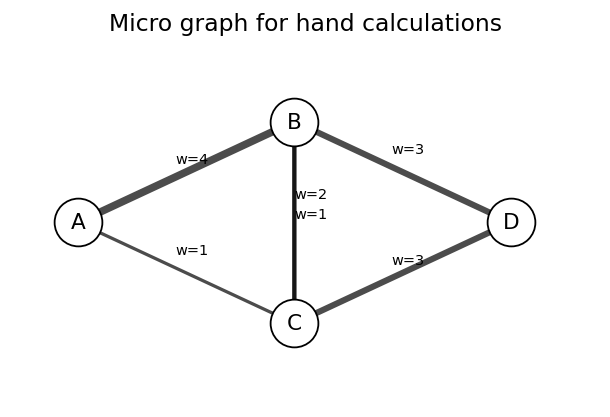

In [31]:
G_micro = nx.DiGraph()

micro_edges_weighted = [
    ("A", "B", 4),
    ("A", "C", 1),
    ("B", "C", 2),
    ("C", "B", 1),
    ("B", "D", 3),
    ("C", "D", 3),
]

for source, target, weight in micro_edges_weighted:
    G_micro.add_edge(source, target, weight=weight, distance=1 / weight)

micro_pos = {
    "A": (0.0, 1.0),
    "B": (1.0, 1.5),
    "C": (1.0, 0.5),
    "D": (2.0, 1.0),
}

fig, ax = plt.subplots(figsize=(5.8, 3.7), dpi=130)

for source, target, data in G_micro.edges(data=True):
    x1, y1 = micro_pos[source]
    x2, y2 = micro_pos[target]
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=1 + 0.8 * data["weight"], alpha=0.7),
    )
    ax.text(0.55 * x1 + 0.45 * x2, 0.55 * y1 + 0.45 * y2 + 0.07, f'w={data["weight"]}', fontsize=8)

for node, (x, y) in micro_pos.items():
    ax.scatter(x, y, s=700, facecolor="white", edgecolor="black", zorder=4)
    ax.text(x, y, node, ha="center", va="center", fontsize=12, zorder=5)

ax.set_title("Micro graph for hand calculations")
ax.set_xlim(-0.3, 2.4)
ax.set_ylim(0.1, 1.9)
ax.axis("off")
plt.show()

### Degree and strength

For a directed zone graph with $N$ zones, let $w_{ij}$ be the weight from zone $i$ to zone $j$.

The **out-strength** and **in-strength** are

$$
s_i^{out} = \sum_{j=1}^{N} w_{ij},
\qquad
s_i^{in} = \sum_{j=1}^{N} w_{ji}.
$$

The **out-degree** and **in-degree** count distinct between-zone neighbors, so we remove the diagonal first and define

$$
k_i^{out} = \sum_{j 
e i} \mathbf{1}(w_{ij} > 0),
\qquad
k_i^{in} = \sum_{j 
e i} \mathbf{1}(w_{ji} > 0).
$$

Here $N$ is the number of zones, $w_{ij}$ is the count of passes from zone $i$ to zone $j$, and $\mathbf{1}(\cdot)$ is the indicator function.

**Plain-language intuition:** strength measures **volume**; degree measures **breadth**.

**Pitch interpretation:** a zone with high out-strength sent many passes, while a zone with high out-degree connected to many different destination zones.

**Code mapping:** `out_strength` and `in_strength` come from weighted out-degree and in-degree in the full graph. `out_degree` and `in_degree` come from the loopless path graph.

**Limitation:** degree ignores how often a link was used, while strength depends strongly on grid resolution.

In [32]:
micro_out_strength_A = sum(G_micro["A"][nbr]["weight"] for nbr in G_micro.successors("A"))
micro_in_strength_A = sum(G_micro[pred]["A"]["weight"] for pred in G_micro.predecessors("A"))
micro_out_degree_A = G_micro.out_degree("A")
micro_in_degree_A = G_micro.in_degree("A")

micro_degree_strength = pd.DataFrame(
    {
        "quantity": ["out-strength(A)", "in-strength(A)", "out-degree(A)", "in-degree(A)"],
        "value": [micro_out_strength_A, micro_in_strength_A, micro_out_degree_A, micro_in_degree_A],
    }
)

display(micro_degree_strength)
display(
    zone_table_64.sort_values(["out_strength", "out_degree"], ascending=[False, False])[
        ["zone_label", "out_strength", "in_strength", "out_degree", "in_degree", "within_count"]
    ].head(10)
)

,quantity,value
0,out-strength(A),5
1,in-strength(A),0
2,out-degree(A),2
3,in-degree(A),0


,zone_label,out_strength,in_strength,out_degree,in_degree,within_count
5,x2_y2,27.0,26.0,7,7,7
9,x3_y2,21.0,22.0,8,7,9
6,x2_y3,21.0,17.0,7,6,3
10,x3_y3,20.0,20.0,10,8,4
12,x4_y1,17.0,15.0,6,6,6
8,x3_y1,17.0,21.0,4,5,4
16,x5_y1,14.0,14.0,3,5,9
13,x4_y2,13.0,8.0,5,3,4
2,x1_y3,13.0,9.0,4,4,3
11,x3_y4,12.0,17.0,7,7,2


### Density and reciprocity

For a directed graph without self-loops, if $m$ is the number of observed directed edges, then density is

$$
	ext{density} = \frac{m}{N(N - 1)}.
$$

The denominator $N(N - 1)$ is the number of possible directed edges between distinct nodes.

For reciprocity, let

$$
a_{ij} = \mathbf{1}(w_{ij} > 0).
$$

Then one common binary version is

$$
r = \frac{\sum_{i 
e j} a_{ij} a_{ji}}{\sum_{i 
e j} a_{ij}}.
$$

**Plain-language intuition:** density asks how full the graph is; reciprocity asks how often a directed connection has a return connection.

**Pitch interpretation:** high density means many zone pairs were used. High reciprocity means circulation often moved both ways between zones.

**Code mapping:** both are computed on the **loopless** graph.

**Limitation:** reciprocity is usually binary. It cares whether the reverse edge exists, not whether the reverse flow is equally large.

In [33]:
micro_n = G_micro.number_of_nodes()
micro_density = G_micro.number_of_edges() / (micro_n * (micro_n - 1))
micro_reciprocal_edges = sum(G_micro.has_edge(v, u) for u, v in G_micro.edges())
micro_reciprocity = micro_reciprocal_edges / G_micro.number_of_edges()

micro_density_reciprocity = pd.DataFrame(
    {
        "quantity": ["density", "reciprocity"],
        "value": [micro_density, micro_reciprocity],
    }
)

display(micro_density_reciprocity)

main_summary_table = network_summary(main_G_zone).round(3).to_frame("Argentina first half, 6 × 4")
display(main_summary_table)

,quantity,value
0,density,0.500000
1,reciprocity,0.333333


,"Argentina first half, 6 × 4"
nodes,24.000
edges_including_loops,117.000
between_zone_edges,98.000
occupied_zones,24.000
total_passes,250.000
within_zone_passes,64.000
within_zone_share,0.256
density,0.178
reciprocity,0.612
out_strength_hhi,0.063


### Outward harmonic centrality

Classical out-closeness is useful when all nodes can reach all others, but directed pitch networks are often only partially reachable. To avoid unstable values, we will use the closely related **harmonic** version.

Let $d(i, j)$ be the shortest-path distance from zone $i$ to zone $j$ in the loopless graph, using the edge costs $c_{ij} = 1 / w_{ij}$. Then the normalized outward harmonic centrality is

$$
H_i^{out} = \frac{1}{N - 1} \sum_{j 
e i} \frac{1}{d(i, j)},
$$

with the convention that $1 / d(i, j) = 0$ when $j$ is unreachable from $i$.

**Plain-language intuition:** a zone gets a large value when it can reach many other zones in relatively few effective steps.

**Pitch interpretation:** a zone with high outward harmonic centrality is an efficient **launch point** into the rest of the spatial circulation structure.

**Code mapping:** we compute this on the loopless path graph with the edge attribute `distance = 1 / weight`.

**Limitation:** this is still a shortest-path abstraction. Real football does not literally route the ball by globally shortest routes.

In [34]:
G_micro_unweighted = nx.DiGraph([(u, v) for u, v, _ in micro_edges_weighted])
micro_lengths_from_A = nx.single_source_shortest_path_length(G_micro_unweighted, "A")
micro_out_harmonic_A = (
    1 / micro_lengths_from_A["B"] + 1 / micro_lengths_from_A["C"] + 1 / micro_lengths_from_A["D"]
) / 3

print("Ignoring weights just to keep the arithmetic readable in the toy graph:")
print("Distances from A:", micro_lengths_from_A)
print(f"Normalized outward harmonic centrality of A = (1 + 1 + 1/2) / 3 = {micro_out_harmonic_A:.3f}")

display(
    zone_table_64.sort_values(["out_harmonic", "out_strength"], ascending=[False, False])[
        ["zone_label", "out_harmonic", "out_strength", "out_degree", "betweenness"]
    ].head(10)
)

Ignoring weights just to keep the arithmetic readable in the toy graph:
Distances from A: {'A': 0, 'B': 1, 'C': 1, 'D': 2}
Normalized outward harmonic centrality of A = (1 + 1 + 1/2) / 3 = 0.833


,zone_label,out_harmonic,out_strength,out_degree,betweenness
6,x2_y3,1.574396,21.0,7,0.101779
5,x2_y2,1.468898,27.0,7,0.098814
8,x3_y1,1.243172,17.0,4,0.219368
10,x3_y3,1.182195,20.0,10,0.156456
2,x1_y3,1.160650,13.0,4,0.100791
12,x4_y1,1.115559,17.0,6,0.144269
13,x4_y2,1.105226,13.0,5,0.088933
15,x4_y4,1.096031,10.0,5,0.281621
7,x2_y4,1.044217,11.0,4,0.041502
9,x3_y2,1.037785,21.0,8,0.136364


### Betweenness centrality

Betweenness asks how often a zone lies on shortest paths between other zone pairs.

Let $\sigma_{st}$ be the number of shortest paths from source zone $s$ to target zone $t$, and let $\sigma_{st}(i)$ be the number of those shortest paths that pass through zone $i$. Then

$$
B_i = \sum_{s 
e i 
e t} \frac{\sigma_{st}(i)}{\sigma_{st}}.
$$

NetworkX reports a normalized version, but the core idea is the same.

**Plain-language intuition:** a high-betweenness zone is a bridge.

**Pitch interpretation:** these are transition zones that many efficient routes pass through. They often connect buildup regions to more advanced regions.

**Code mapping:** we compute betweenness on the loopless graph using `weight="distance"`.

**Limitation:** betweenness is a shortest-path metric, so it should be read as an informative simplification, not as a literal causal mechanism.

In [35]:
micro_betweenness = nx.betweenness_centrality(G_micro_unweighted, normalized=False)

display(
    pd.DataFrame(
        {
            "node": list(micro_betweenness.keys()),
            "unnormalized_betweenness": list(micro_betweenness.values()),
        }
    ).sort_values("unnormalized_betweenness", ascending=False)
)

display(
    zone_table_64.sort_values(["betweenness", "out_harmonic"], ascending=[False, False])[
        ["zone_label", "betweenness", "out_harmonic", "out_strength", "out_degree"]
    ].head(10)
)

,node,unnormalized_betweenness
1,B,0.5
2,C,0.5
0,A,0.0
3,D,0.0


,zone_label,betweenness,out_harmonic,out_strength,out_degree
15,x4_y4,0.281621,1.096031,10.0,5
8,x3_y1,0.219368,1.243172,17.0,4
10,x3_y3,0.156456,1.182195,20.0,10
18,x5_y3,0.156126,0.752421,11.0,4
11,x3_y4,0.154809,0.970293,12.0,7
19,x5_y4,0.154150,0.916507,6.0,2
12,x4_y1,0.144269,1.115559,17.0,6
9,x3_y2,0.136364,1.037785,21.0,8
6,x2_y3,0.101779,1.574396,21.0,7
2,x1_y3,0.100791,1.160650,13.0,4


### Flow concentration via the Herfindahl-Hirschman Index

A useful global summary is how concentrated outgoing zone activity is.

Define the share of outgoing passes from zone $i$ as

$$
p_i = \frac{s_i^{out}}{\sum_k s_k^{out}},
$$

and then define the concentration index

$$
	ext{HHI} = \sum_i p_i^2.
$$

Here $s_i^{out}$ is the out-strength of zone $i$ and $p_i$ is its share of all outgoing passes. The index is larger when a team routes much of its circulation through a small number of zones.

**Plain-language intuition:** HHI answers the question "How concentrated is the passing flow?"

**Pitch interpretation:** a large HHI means the team's outgoing circulation is concentrated in relatively few regions.

**Code mapping:** `out_strength_hhi` in our network summaries is computed from the zone-level `out_strength_share`.

**Limitation:** HHI is a coarse scalar summary. It tells us that concentration exists, but not exactly where it lives on the pitch.

In [36]:
out_share_table = zone_table_64[["zone_label", "out_strength_share"]].sort_values(
    "out_strength_share",
    ascending=False,
).reset_index(drop=True)

display(out_share_table.head(10))
print(f"Argentina first-half 6 × 4 out-strength HHI: {network_summary(main_G_zone)['out_strength_hhi']:.4f}")

,zone_label,out_strength_share
0,x2_y2,0.108
1,x3_y2,0.084
2,x2_y3,0.084
3,x3_y3,0.080
4,x3_y1,0.068
5,x4_y1,0.068
6,x5_y1,0.056
7,x1_y3,0.052
8,x4_y2,0.052
9,x3_y4,0.048


Argentina first-half 6 × 4 out-strength HHI: 0.0626


## 10. Heatmaps of centrality over the pitch

One of the main payoffs of a pitch passing network is that the centrality values live on **space**. Once the nodes are zones, we can map strength and centrality back onto the pitch itself.

For the classroom build, the 6 × 4 grid was ideal. For centrality heatmaps, a slightly finer grid is more informative. So in this section we switch to **7 × 7** while keeping the match slice and pass definition fixed unless stated otherwise.

In [37]:
_, _, _, _, G_arg_h1_77, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[1],
    n_cols=7,
    n_rows=7,
    completed_only=True,
    open_play_like=True,
)
_, _, _, _, G_fra_h1_77, _ = build_zone_network_from_events(
    events_df,
    team_name=OTHER_TEAM,
    periods=[1],
    n_cols=7,
    n_rows=7,
    completed_only=True,
    open_play_like=True,
)
_, _, _, _, G_arg_h2_77, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[2],
    n_cols=7,
    n_rows=7,
    completed_only=True,
    open_play_like=True,
)

zone_table_arg_h1_77 = zone_metric_table(G_arg_h1_77)
zone_table_fra_h1_77 = zone_metric_table(G_fra_h1_77)
zone_table_arg_h2_77 = zone_metric_table(G_arg_h2_77)

centrality_slice_summary = pd.DataFrame(
    [
        network_summary(G_arg_h1_77),
        network_summary(G_fra_h1_77),
        network_summary(G_arg_h2_77),
    ],
    index=[
        "Argentina, first half",
        "France, first half",
        "Argentina, second half",
    ],
).round(3)

display(centrality_slice_summary)

,nodes,edges_including_loops,between_zone_edges,occupied_zones,total_passes,within_zone_passes,within_zone_share,density,reciprocity,out_strength_hhi
"Argentina, first half",49.0,181.0,160.0,45.0,250.0,33.0,0.132,0.068,0.412,0.034
"France, first half",49.0,116.0,105.0,39.0,141.0,18.0,0.128,0.045,0.286,0.043
"Argentina, second half",49.0,123.0,105.0,48.0,147.0,23.0,0.156,0.045,0.267,0.033


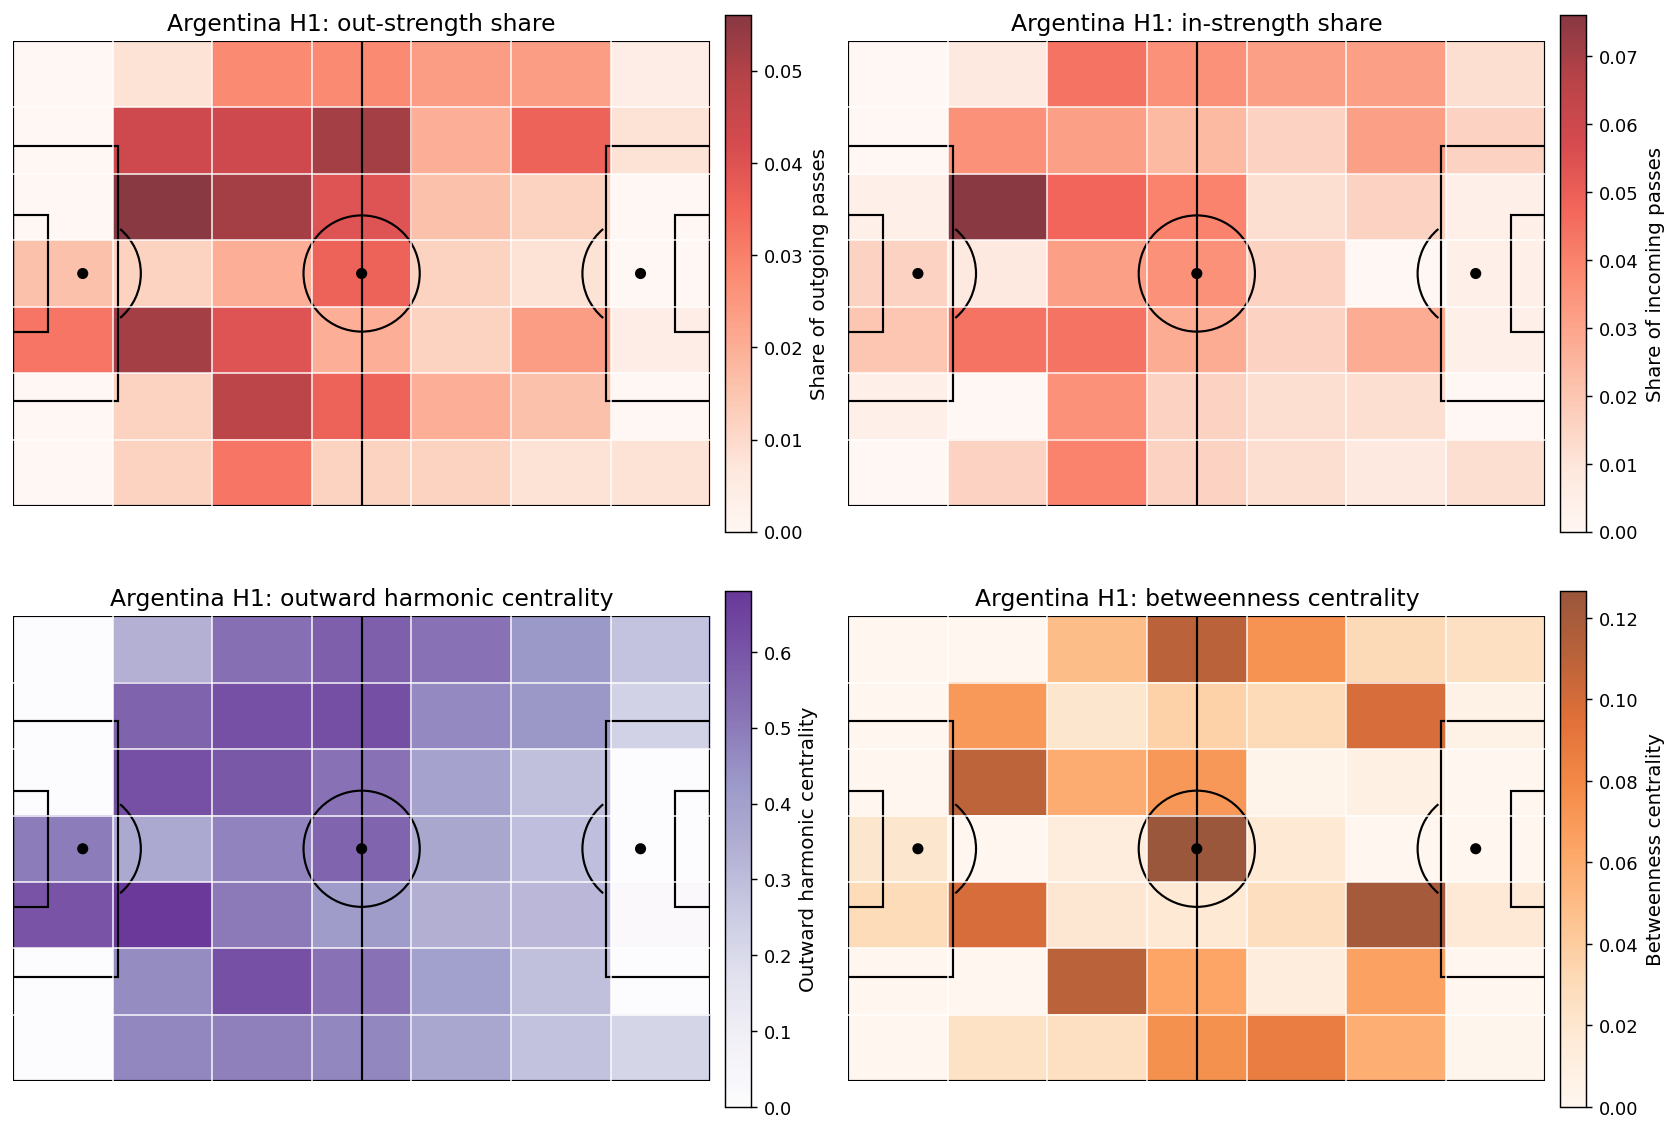

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=130)

plot_zone_heatmap(
    zone_table_arg_h1_77,
    metric="out_strength_share",
    n_cols=7,
    n_rows=7,
    ax=axes[0, 0],
    cmap="Reds",
    title="Argentina H1: out-strength share",
    colorbar=True,
    cbar_label="Share of outgoing passes",
)

plot_zone_heatmap(
    zone_table_arg_h1_77,
    metric="in_strength_share",
    n_cols=7,
    n_rows=7,
    ax=axes[0, 1],
    cmap="Reds",
    title="Argentina H1: in-strength share",
    colorbar=True,
    cbar_label="Share of incoming passes",
)

plot_zone_heatmap(
    zone_table_arg_h1_77,
    metric="out_harmonic",
    n_cols=7,
    n_rows=7,
    ax=axes[1, 0],
    cmap="Purples",
    title="Argentina H1: outward harmonic centrality",
    colorbar=True,
    cbar_label="Outward harmonic centrality",
)

plot_zone_heatmap(
    zone_table_arg_h1_77,
    metric="betweenness",
    n_cols=7,
    n_rows=7,
    ax=axes[1, 1],
    cmap="Oranges",
    title="Argentina H1: betweenness centrality",
    colorbar=True,
    cbar_label="Betweenness centrality",
)

plt.tight_layout()
plt.show()

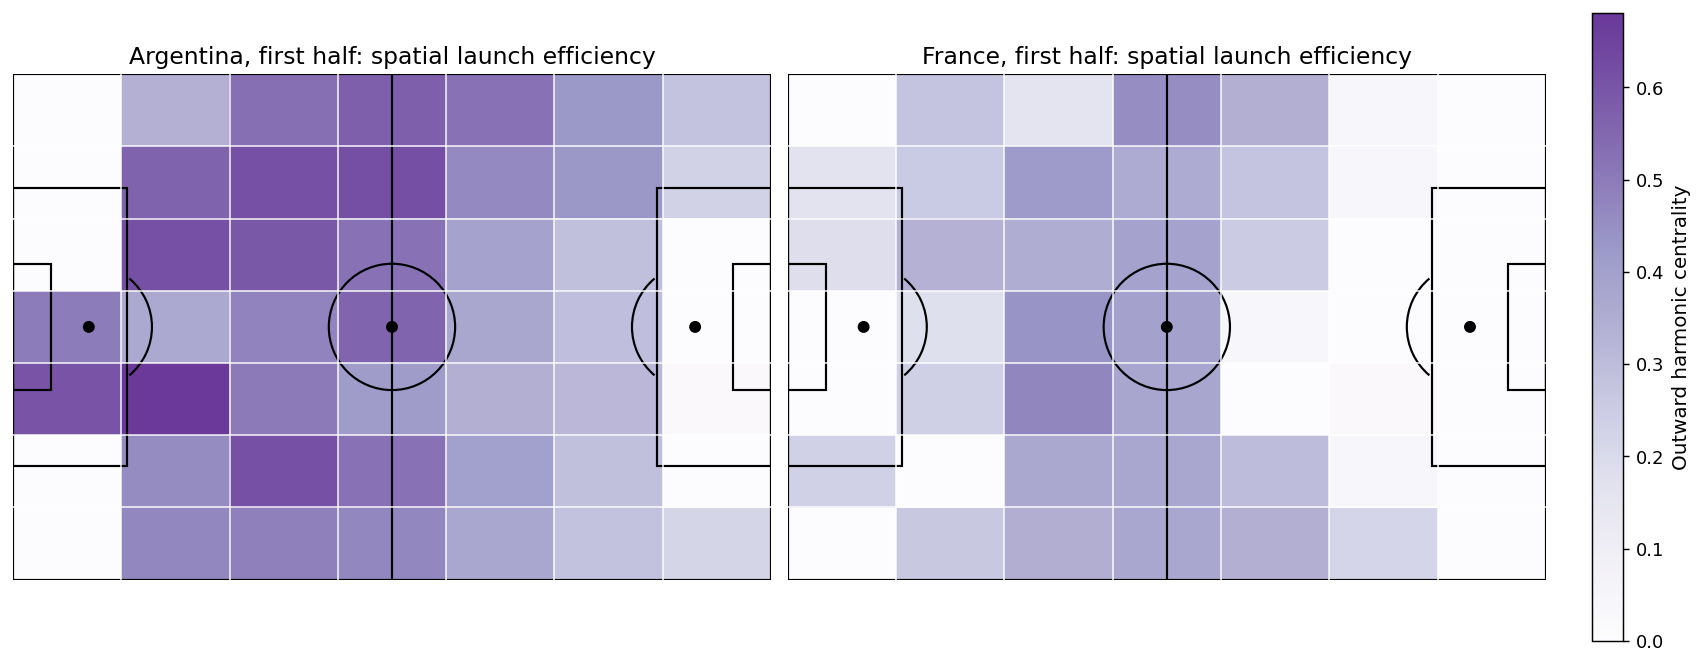

In [39]:
harmonic_vmin = min(zone_table_arg_h1_77["out_harmonic"].min(), zone_table_fra_h1_77["out_harmonic"].min())
harmonic_vmax = max(zone_table_arg_h1_77["out_harmonic"].max(), zone_table_fra_h1_77["out_harmonic"].max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130, constrained_layout=True)

im = plot_zone_heatmap(
    zone_table_arg_h1_77,
    metric="out_harmonic",
    n_cols=7,
    n_rows=7,
    ax=axes[0],
    cmap="Purples",
    title="Argentina, first half",
    vmin=harmonic_vmin,
    vmax=harmonic_vmax,
    colorbar=False,
)
plot_zone_heatmap(
    zone_table_fra_h1_77,
    metric="out_harmonic",
    n_cols=7,
    n_rows=7,
    ax=axes[1],
    cmap="Purples",
    title="France, first half",
    vmin=harmonic_vmin,
    vmax=harmonic_vmax,
    colorbar=False,
)

cbar = plt.colorbar(im, ax=axes, fraction=0.032, pad=0.03)
cbar.set_label("Outward harmonic centrality")

axes[0].set_title("Argentina, first half: spatial launch efficiency")
axes[1].set_title("France, first half: spatial launch efficiency")

plt.show()

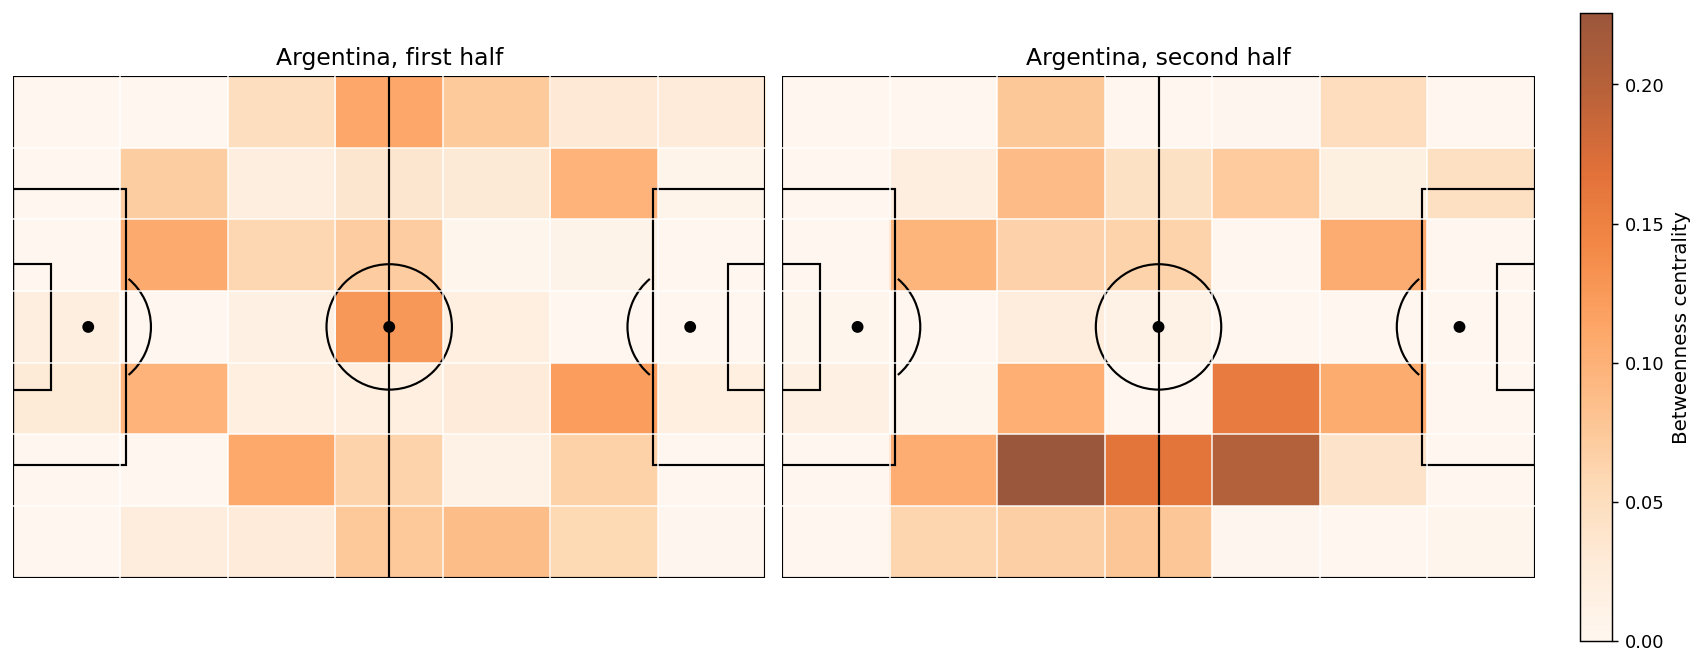

In [40]:
bet_vmin = min(zone_table_arg_h1_77["betweenness"].min(), zone_table_arg_h2_77["betweenness"].min())
bet_vmax = max(zone_table_arg_h1_77["betweenness"].max(), zone_table_arg_h2_77["betweenness"].max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130, constrained_layout=True)

im = plot_zone_heatmap(
    zone_table_arg_h1_77,
    metric="betweenness",
    n_cols=7,
    n_rows=7,
    ax=axes[0],
    cmap="Oranges",
    title="Argentina, first half",
    vmin=bet_vmin,
    vmax=bet_vmax,
    colorbar=False,
)
plot_zone_heatmap(
    zone_table_arg_h2_77,
    metric="betweenness",
    n_cols=7,
    n_rows=7,
    ax=axes[1],
    cmap="Oranges",
    title="Argentina, second half",
    vmin=bet_vmin,
    vmax=bet_vmax,
    colorbar=False,
)

cbar = plt.colorbar(im, ax=axes, fraction=0.032, pad=0.03)
cbar.set_label("Betweenness centrality")

plt.show()

These maps should not be read as duplicates.

- **Out-strength share** highlights where passes were sent from.
- **In-strength share** highlights where passes were received.
- **Outward harmonic centrality** highlights zones that could reach many other zones efficiently.
- **Betweenness** highlights bridge zones that sit on many efficient routes.

That is a major conceptual difference from player networks: the centrality now belongs to **territory** rather than to people.

## 11. Comparing player and pitch passing networks

Now we hold the match window fixed and change only the node definition.

We will build the corresponding **player passing network** for Argentina in the same first-half window and with the same main pass filter. That gives us a direct apples-to-apples comparison between a player-based representation and a zone-based representation.

In [41]:
def get_team_entry(lineups, team_name):
    """Return the lineup dictionary for one team."""
    return next(team for team in lineups if team["team_name"] == team_name)

def get_starters(team_entry):
    """Return the set of players whose first listed position starts in the Starting XI."""
    starters = []
    for player in team_entry["lineup"]:
        positions = player.get("positions", [])
        if positions and positions[0].get("start_reason") == "Starting XI":
            starters.append(player["player_name"])
    return starters

def get_nickname_map(team_entry):
    """Map full player names to nicknames when available, otherwise to a short label."""
    out = {}
    for player in team_entry["lineup"]:
        name = player["player_name"]
        out[name] = player.get("player_nickname") or name.split()[-1]
    return out

def build_player_pass_network(
    events_df,
    lineups,
    team_name,
    periods=None,
    minute_min=None,
    minute_max=None,
    completed_only=True,
    open_play_like=True,
    starters_only=True,
):
    """Build a weighted directed player passing network and average player locations."""
    team_entry = get_team_entry(lineups, team_name)
    starters = set(get_starters(team_entry))
    nickname_map = get_nickname_map(team_entry)

    pass_df = prepare_pass_dataframe(
        events_df,
        team_name=team_name,
        periods=periods,
        minute_min=minute_min,
        minute_max=minute_max,
        completed_only=completed_only,
        open_play_like=open_play_like,
    ).dropna(subset=["player_name", "pass_recipient_name"]).copy()

    if starters_only:
        pass_df = pass_df.loc[
            pass_df["player_name"].isin(starters)
            & pass_df["pass_recipient_name"].isin(starters)
        ].copy()

    touch_df = events_df.loc[
        events_df["team_name"].eq(team_name)
        & events_df["player_name"].notna()
        & events_df["x"].notna()
        & events_df["y"].notna()
    ].copy()

    if periods is not None:
        if np.isscalar(periods):
            periods = [periods]
        touch_df = touch_df.loc[touch_df["period"].isin(list(periods))].copy()

    if minute_min is not None:
        touch_df = touch_df.loc[touch_df["match_time"] >= minute_min].copy()
    if minute_max is not None:
        touch_df = touch_df.loc[touch_df["match_time"] < minute_max].copy()

    if starters_only:
        touch_df = touch_df.loc[touch_df["player_name"].isin(starters)].copy()

    G_player = nx.DiGraph(team=team_name, periods=periods)

    if pass_df.empty:
        candidate_players = sorted(touch_df["player_name"].unique().tolist())
    else:
        candidate_players = sorted(
            pd.unique(
                pd.concat([pass_df["player_name"], pass_df["pass_recipient_name"]], ignore_index=True)
            )
        )

    for player in candidate_players:
        G_player.add_node(player)

    edge_df = (
        pass_df.groupby(["player_name", "pass_recipient_name"], as_index=False)
        .size()
        .rename(columns={"size": "weight"})
        .sort_values(["weight", "player_name", "pass_recipient_name"], ascending=[False, True, True])
        .reset_index(drop=True)
    )

    for row in edge_df.itertuples():
        G_player.add_edge(
            row.player_name,
            row.pass_recipient_name,
            weight=int(row.weight),
            distance=1.0 / float(row.weight),
        )

    if not touch_df.empty:
        avg_pos = touch_df.groupby("player_name")[["x", "y"]].mean()
        involvement = pd.concat([pass_df["player_name"], pass_df["pass_recipient_name"]], ignore_index=True).value_counts()

        for player in avg_pos.index:
            if player not in G_player:
                G_player.add_node(player)
            G_player.nodes[player]["x"] = float(avg_pos.loc[player, "x"])
            G_player.nodes[player]["y"] = float(avg_pos.loc[player, "y"])
            G_player.nodes[player]["involvement"] = int(involvement.get(player, 0))
            G_player.nodes[player]["label"] = nickname_map.get(player, player)

    return pass_df.reset_index(drop=True), touch_df.reset_index(drop=True), G_player, nickname_map

def plot_player_network(G_player, ax=None, min_weight=2, title=None):
    """Plot a player passing network using average player locations on the pitch."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

    draw_statsbomb_pitch(ax)

    edges = [(u, v, d) for u, v, d in G_player.edges(data=True) if d["weight"] >= min_weight]
    max_weight = max([d["weight"] for _, _, d in edges], default=1)

    for source, target, data in sorted(edges, key=lambda item: item[2]["weight"]):
        if "x" not in G_player.nodes[source] or "x" not in G_player.nodes[target]:
            continue
        arrow = FancyArrowPatch(
            (G_player.nodes[source]["x"], G_player.nodes[source]["y"]),
            (G_player.nodes[target]["x"], G_player.nodes[target]["y"]),
            arrowstyle="-|>",
            mutation_scale=8 + 4 * data["weight"] / max_weight,
            linewidth=0.6 + 3.2 * data["weight"] / max_weight,
            alpha=0.25,
            color="tab:orange",
            shrinkA=10,
            shrinkB=10,
            connectionstyle="arc3,rad=0.05",
        )
        ax.add_patch(arrow)

    nodes = [node for node in G_player.nodes() if "x" in G_player.nodes[node]]
    sizes = scale_values(
        [G_player.out_degree(node, weight="weight") + G_player.in_degree(node, weight="weight") for node in nodes],
        min_size=220,
        max_size=1200,
    )

    xs = [G_player.nodes[node]["x"] for node in nodes]
    ys = [G_player.nodes[node]["y"] for node in nodes]

    ax.scatter(xs, ys, s=sizes, facecolor="white", edgecolors="black", linewidths=0.9, zorder=4)

    for node in nodes:
        ax.text(
            G_player.nodes[node]["x"],
            G_player.nodes[node]["y"],
            G_player.nodes[node].get("label", node),
            ha="center",
            va="center",
            fontsize=8,
            zorder=5,
        )

    if title:
        ax.set_title(title)
    return ax

def player_network_summary(G_player):
    """Compute a compact summary for a player passing network."""
    reciprocity_value = nx.reciprocity(G_player)
    return pd.Series(
        {
            "nodes": G_player.number_of_nodes(),
            "edges": G_player.number_of_edges(),
            "total_passes": sum(data["weight"] for _, _, data in G_player.edges(data=True)),
            "density": float(nx.density(G_player)),
            "reciprocity": float(reciprocity_value) if reciprocity_value is not None else 0.0,
        }
    )

def player_metric_table(G_player):
    """Compute a simple player-level metric table."""
    if G_player.number_of_edges():
        betweenness = nx.betweenness_centrality(G_player, weight="distance", normalized=True)
    else:
        betweenness = {node: 0.0 for node in G_player.nodes()}

    rows = []
    for node in G_player.nodes():
        rows.append(
            {
                "player": node,
                "label": G_player.nodes[node].get("label", node),
                "out_degree": G_player.out_degree(node),
                "in_degree": G_player.in_degree(node),
                "out_strength": G_player.out_degree(node, weight="weight"),
                "in_strength": G_player.in_degree(node, weight="weight"),
                "betweenness": betweenness.get(node, 0.0),
            }
        )

    return pd.DataFrame(rows).sort_values("out_strength", ascending=False).reset_index(drop=True)

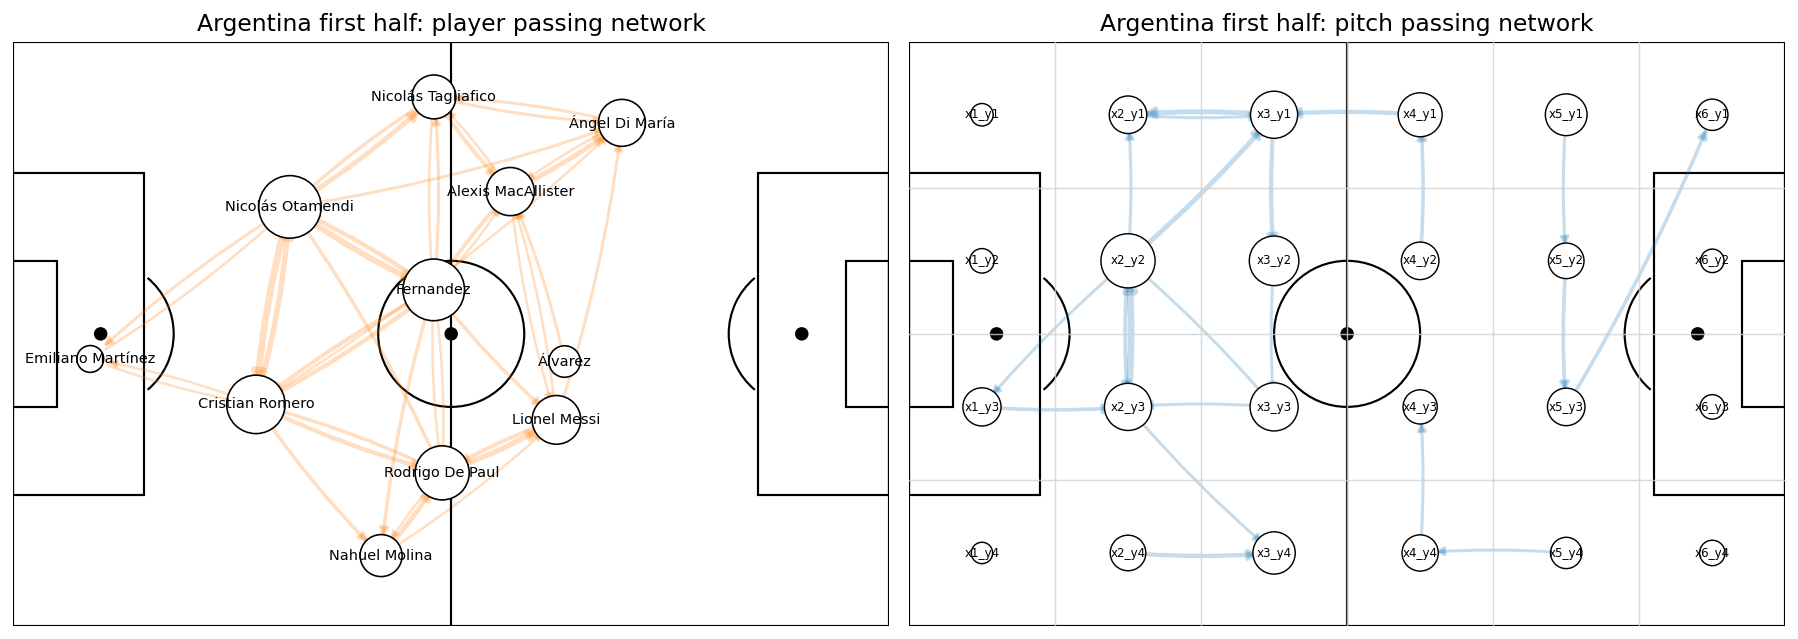

,player_network,pitch_network
nodes,11.000,24.000
edges,70.000,98.000
total_passes,250.000,250.000
density,0.636,0.178
reciprocity,0.857,0.612


,player,label,out_degree,in_degree,out_strength,in_strength,betweenness
0,Nicolás Hernán Otamendi,Nicolás Otamendi,6,9,39,34,0.316667
1,Cristian Gabriel Romero,Cristian Romero,8,6,36,28,0.100000
2,Enzo Fernandez,Fernandez,9,9,36,35,0.188889
3,Rodrigo Javier De Paul,Rodrigo De Paul,6,7,27,28,0.172222
4,Alexis Mac Allister,Alexis MacAllister,6,7,22,22,0.097222
5,Lionel Andrés Messi Cuccittini,Lionel Messi,8,7,20,25,0.069444
6,Nahuel Molina Lucero,Nahuel Molina,8,5,18,16,0.000000
7,Nicolás Alejandro Tagliafico,Nicolás Tagliafico,4,4,18,19,0.066667
8,Ángel Fabián Di María Hernández,Ángel Di María,7,7,16,26,0.000000
9,Julián Álvarez,Álvarez,5,6,11,9,0.000000


In [42]:
arg_player_pass_df, arg_player_touch_df, G_player_arg_h1, arg_nickname_map = build_player_pass_network(
    events_df,
    lineups=lineups,
    team_name=MAIN_TEAM,
    periods=[1],
    completed_only=True,
    open_play_like=True,
    starters_only=True,
)

player_summary = player_network_summary(G_player_arg_h1).round(3).to_frame("Player network")
pitch_summary = network_summary(main_G_zone)[["nodes", "between_zone_edges", "total_passes", "density", "reciprocity"]]
pitch_summary.index = ["nodes", "edges", "total_passes", "density", "reciprocity"]
pitch_summary = pitch_summary.round(3).to_frame("Pitch network")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=130)

plot_player_network(
    G_player_arg_h1,
    ax=axes[0],
    min_weight=3,
    title="Argentina first half: player passing network",
)

plot_zone_network_on_pitch(
    main_G_zone,
    node_values=dict(zip(zone_table_64["zone_id"], zone_table_64["involvement"])),
    n_cols=6,
    n_rows=4,
    ax=axes[1],
    min_weight=3,
    top_n_edges=35,
    title="Argentina first half: pitch passing network",
)

plt.tight_layout()
plt.show()

comparison_summary = pd.DataFrame(
    {
        "player_network": player_network_summary(G_player_arg_h1),
        "pitch_network": pd.Series(
            {
                "nodes": main_G_zone.number_of_nodes(),
                "edges": zone_graph_without_loops(main_G_zone).number_of_edges(),
                "total_passes": sum(data["weight"] for _, _, data in main_G_zone.edges(data=True)),
                "density": nx.density(zone_graph_without_loops(main_G_zone)),
                "reciprocity": nx.reciprocity(zone_graph_without_loops(main_G_zone)),
            }
        ),
    }
).round(3)

display(comparison_summary)
display(player_metric_table(G_player_arg_h1).head(10))

The comparison is substantial, not cosmetic.

**What becomes clearer in the pitch representation?** Spatial circulation, territorial balance, bridge zones, repeated wing-to-center or back-to-front channels, and differences between halves or matches that are not tied to one specific lineup.

**What becomes less clear?** Who made the passes, who received them, whether one zone's role was actually carried by a single player or shared by several, and how substitutions or role swaps changed the pattern.

**What does the player network still do better?** It preserves identity, role relationships, and direct teammate-to-teammate coordination. That is essential when the question is about personnel rather than territory.

So the right conclusion is not that one network replaces the other. They are **complementary models** built from the same event stream.

## 12. Time and context matter

A pitch passing network is not a fixed fingerprint of a team. It changes when we change the time window, the pass definition, the grid, or the match state.

The 2022 final is especially useful for this lesson because its flow changes sharply across regulation and extra time. A full-match network averages over very different contexts, so we should expect important structure to disappear when we aggregate too aggressively.

,team_name,player_name,period,minute,second,shot.type.name,match_time,argentina_score,france_score
0,Argentina,Lionel Andrés Messi Cuccittini,1,22,24,Penalty,22.400000,1,0
1,Argentina,Ángel Fabián Di María Hernández,1,35,22,Open Play,35.366667,2,0
2,France,Kylian Mbappé Lottin,2,79,24,Penalty,79.400000,2,1
3,France,Kylian Mbappé Lottin,2,80,59,Open Play,80.983333,2,2
4,Argentina,Lionel Andrés Messi Cuccittini,4,107,58,Open Play,107.966667,3,2
5,France,Kylian Mbappé Lottin,4,117,5,Penalty,117.083333,3,3


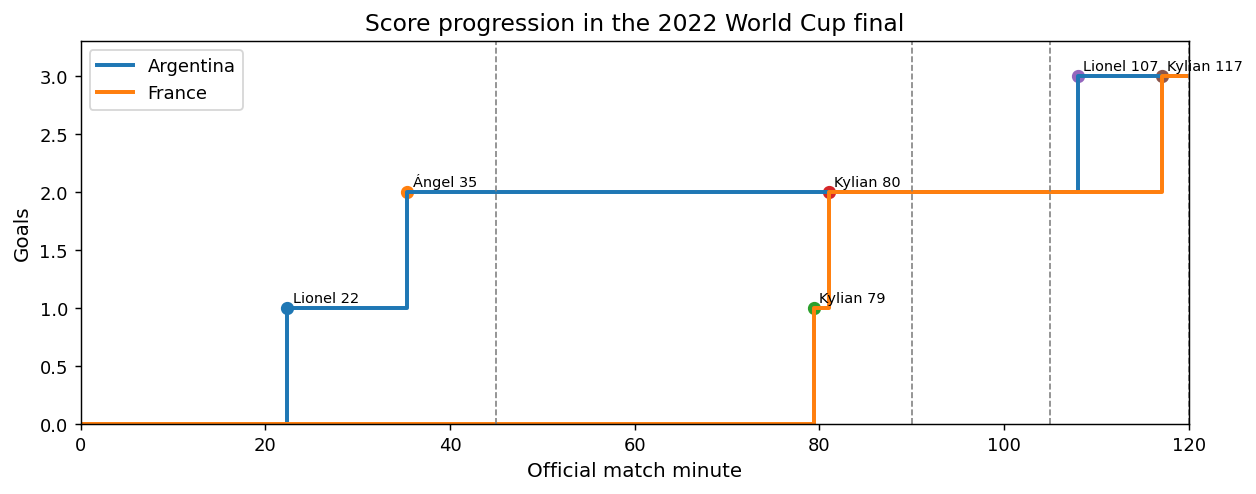

In [43]:
goal_events = events_df.loc[
    events_df["event_type"].eq("Shot")
    & events_df["shot.outcome.name"].eq("Goal")
    & (events_df["period"] < 5),
    ["team_name", "player_name", "period", "minute", "second", "shot.type.name"],
].copy()

goal_events["match_time"] = goal_events["minute"] + goal_events["second"] / 60.0
goal_events = goal_events.sort_values(["match_time"]).reset_index(drop=True)

arg_score = 0
fra_score = 0
arg_scores = []
fra_scores = []

for row in goal_events.itertuples():
    if row.team_name == MAIN_TEAM:
        arg_score += 1
    else:
        fra_score += 1
    arg_scores.append(arg_score)
    fra_scores.append(fra_score)

goal_events["argentina_score"] = arg_scores
goal_events["france_score"] = fra_scores

display(goal_events)

fig, ax = plt.subplots(figsize=(11, 3.9), dpi=130)

times = [0] + goal_events["match_time"].tolist() + [120]
arg_steps = [0] + goal_events["argentina_score"].tolist() + [goal_events["argentina_score"].iloc[-1]]
fra_steps = [0] + goal_events["france_score"].tolist() + [goal_events["france_score"].iloc[-1]]

ax.step(times, arg_steps, where="post", linewidth=2.2, label="Argentina")
ax.step(times, fra_steps, where="post", linewidth=2.2, label="France")

for boundary in [45, 90, 105, 120]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.9)

for row in goal_events.itertuples():
    y_value = row.argentina_score if row.team_name == MAIN_TEAM else row.france_score
    ax.scatter(row.match_time, y_value, s=40)
    ax.text(row.match_time + 0.6, y_value + 0.05, f"{row.player_name.split()[0]} {int(row.minute)}", fontsize=8)

ax.set_xlim(0, 120)
ax.set_ylim(0, 3.3)
ax.set_xlabel("Official match minute")
ax.set_ylabel("Goals")
ax.set_title("Score progression in the 2022 World Cup final")
ax.legend()
plt.show()

### First half versus second half

Halves are coarse, but they are tactically meaningful. Halftime is a natural adjustment point, and the second half of the final also contains a major change in match state.

,team,half,total_passes,occupied_zones,within_zone_share,density,reciprocity,out_strength_hhi
0,Argentina,H1,250.0,24.0,0.256,0.178,0.612,0.063
1,Argentina,H2,147.0,24.0,0.286,0.129,0.479,0.056
2,France,H1,141.0,21.0,0.262,0.112,0.452,0.078
3,France,H2,187.0,21.0,0.257,0.149,0.463,0.073


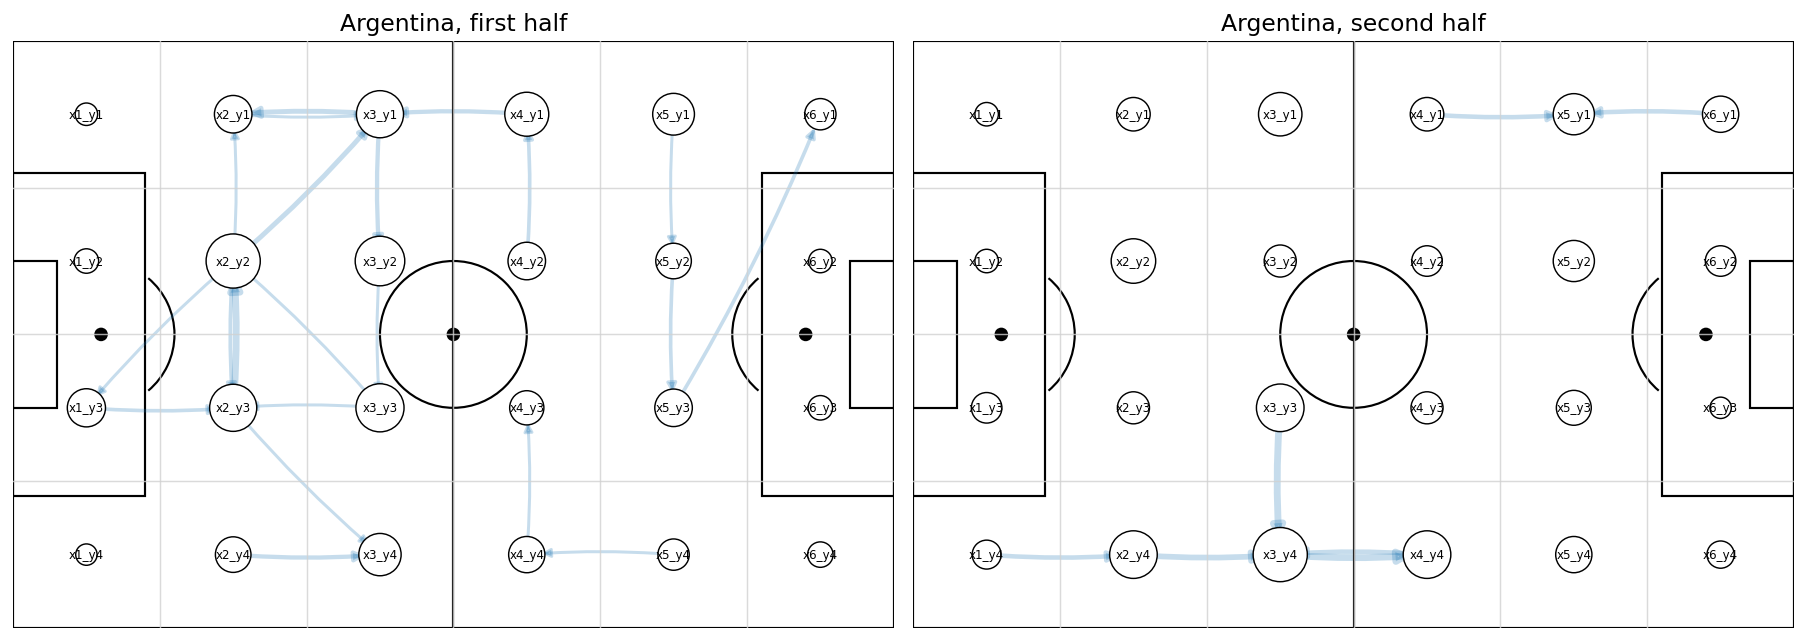

In [44]:
half_rows = []
for team_name in [MAIN_TEAM, OTHER_TEAM]:
    for period in [1, 2]:
        _, _, _, _, G_tmp, _ = build_zone_network_from_events(
            events_df,
            team_name=team_name,
            periods=[period],
            n_cols=6,
            n_rows=4,
            completed_only=True,
            open_play_like=True,
        )
        row = network_summary(G_tmp)
        row["team"] = team_name
        row["half"] = f"H{period}"
        half_rows.append(row)

half_summary_df = pd.DataFrame(half_rows)[
    ["team", "half", "total_passes", "occupied_zones", "within_zone_share", "density", "reciprocity", "out_strength_hhi"]
].round(3)

display(half_summary_df)

_, _, _, _, G_arg_h2_64, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[2],
    n_cols=6,
    n_rows=4,
    completed_only=True,
    open_play_like=True,
)
zone_table_arg_h2_64 = zone_metric_table(G_arg_h2_64)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), dpi=130)

plot_zone_network_on_pitch(
    main_G_zone,
    node_values=dict(zip(zone_table_64["zone_id"], zone_table_64["involvement"])),
    n_cols=6,
    n_rows=4,
    ax=axes[0],
    min_weight=3,
    top_n_edges=35,
    title="Argentina, first half",
)
plot_zone_network_on_pitch(
    G_arg_h2_64,
    node_values=dict(zip(zone_table_arg_h2_64["zone_id"], zone_table_arg_h2_64["involvement"])),
    n_cols=6,
    n_rows=4,
    ax=axes[1],
    min_weight=3,
    top_n_edges=35,
    title="Argentina, second half",
)

plt.tight_layout()
plt.show()

### Completed versus attempted passes

Completed passes emphasize **successful circulation**. Attempted passes preserve something closer to **intended movement**, even when the move fails.

Neither choice is universally right. It depends on the question.

,nodes,edges_including_loops,between_zone_edges,occupied_zones,total_passes,within_zone_passes,within_zone_share,density,reciprocity,out_strength_hhi
Completed,24.0,117.0,98.0,24.0,250.0,64.0,0.256,0.178,0.612,0.063
Attempted,24.0,132.0,113.0,24.0,291.0,75.0,0.258,0.205,0.549,0.061


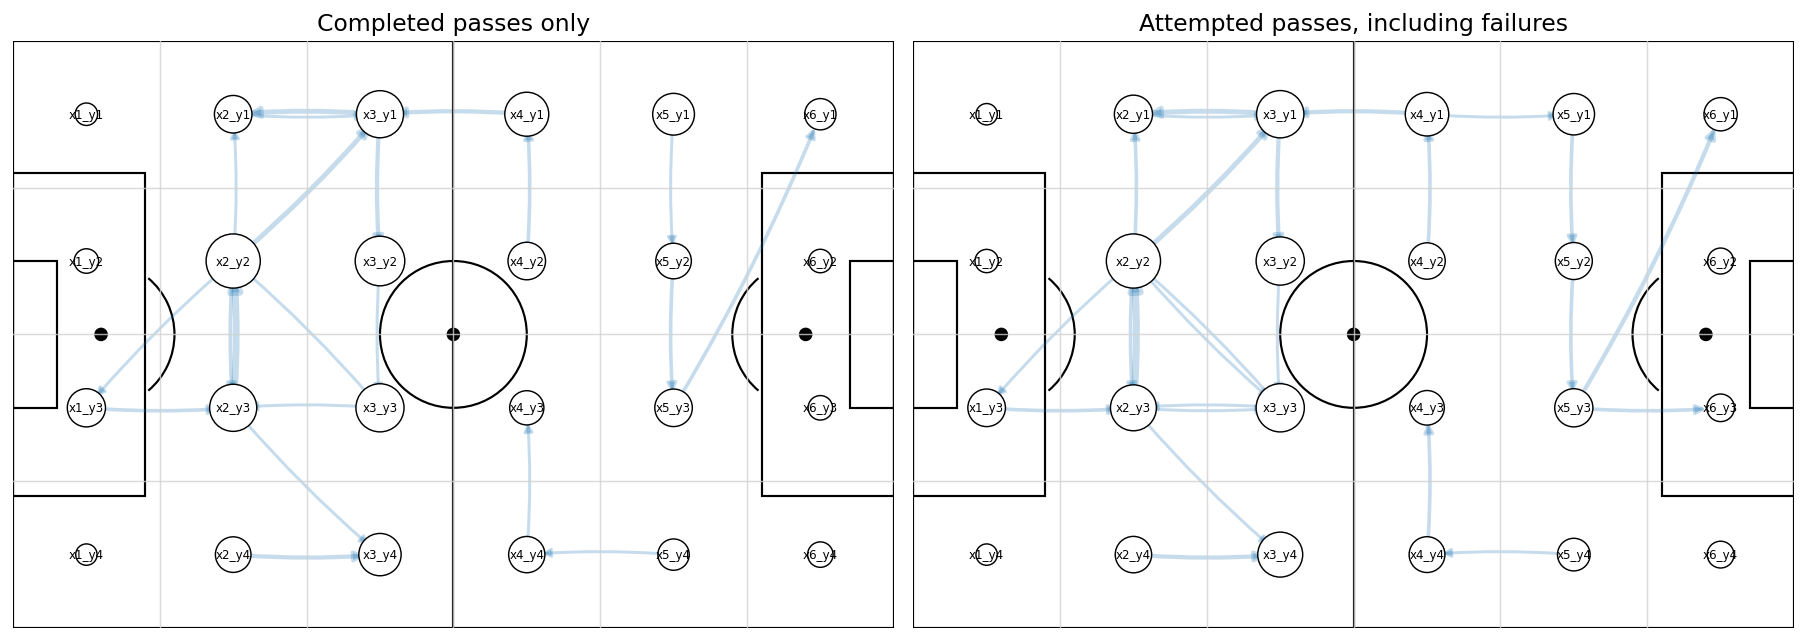

In [45]:
_, _, _, _, G_arg_h1_completed_64, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[1],
    n_cols=6,
    n_rows=4,
    completed_only=True,
    open_play_like=True,
)
_, _, _, _, G_arg_h1_attempted_64, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[1],
    n_cols=6,
    n_rows=4,
    completed_only=False,
    open_play_like=True,
)

zone_table_completed_64 = zone_metric_table(G_arg_h1_completed_64)
zone_table_attempted_64 = zone_metric_table(G_arg_h1_attempted_64)

completed_vs_attempted = pd.DataFrame(
    [network_summary(G_arg_h1_completed_64), network_summary(G_arg_h1_attempted_64)],
    index=["Completed", "Attempted"],
).round(3)

display(completed_vs_attempted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), dpi=130)

plot_zone_network_on_pitch(
    G_arg_h1_completed_64,
    node_values=dict(zip(zone_table_completed_64["zone_id"], zone_table_completed_64["involvement"])),
    n_cols=6,
    n_rows=4,
    ax=axes[0],
    min_weight=3,
    top_n_edges=35,
    title="Completed passes only",
)
plot_zone_network_on_pitch(
    G_arg_h1_attempted_64,
    node_values=dict(zip(zone_table_attempted_64["zone_id"], zone_table_attempted_64["involvement"])),
    n_cols=6,
    n_rows=4,
    ax=axes[1],
    min_weight=3,
    top_n_edges=35,
    title="Attempted passes, including failures",
)

plt.tight_layout()
plt.show()

### 15-minute windows

Half-by-half splits are useful, but they still average over a lot of game state. A standard next step is to use shorter windows.

To keep stoppage time from creating awkward extra bins, we use an official 0–120 clock and place stoppage time inside the nearest scheduled 15-minute block.

,window,total_passes,passes_per_minute,occupied_zones,density,reciprocity,out_strength_hhi
0,00–15,67.0,4.467,39.0,0.024,0.286,0.042
1,15–30,52.0,3.467,32.0,0.018,0.326,0.061
2,30–45,131.0,8.733,40.0,0.041,0.250,0.037
3,45–60,38.0,2.533,34.0,0.014,0.059,0.050
4,60–75,40.0,2.667,27.0,0.012,0.357,0.061
5,75–90,69.0,4.600,39.0,0.023,0.151,0.043
6,90–105,70.0,4.667,35.0,0.023,0.222,0.051
7,105–120,47.0,3.133,33.0,0.017,0.146,0.051


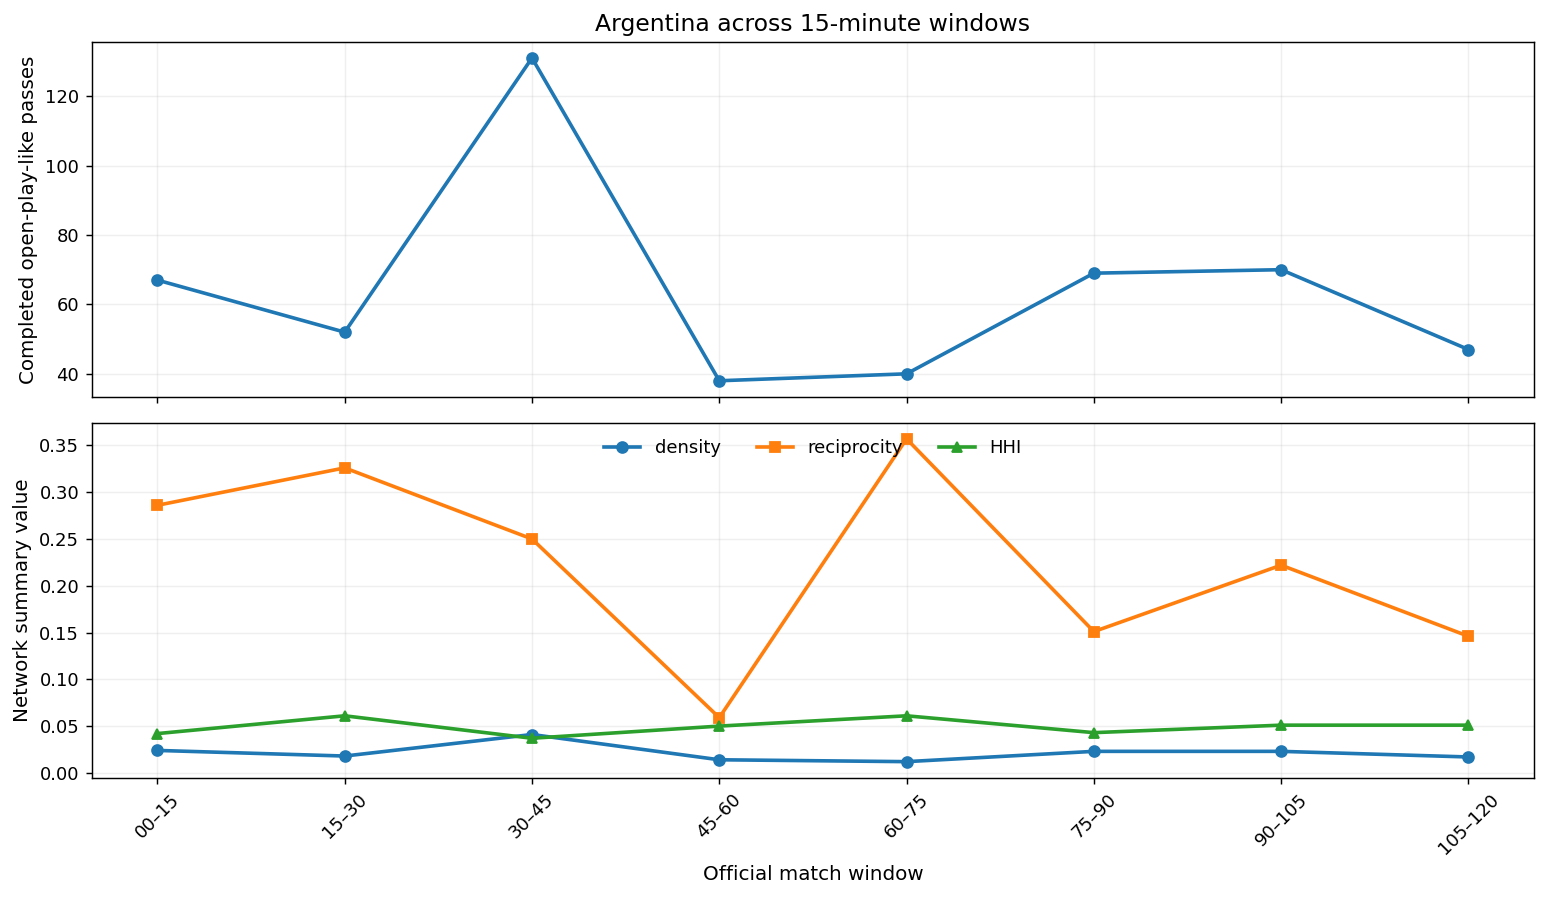

In [46]:
window_rows = []
window_bounds = [(0, 15), (15, 30), (30, 45), (45, 60), (60, 75), (75, 90), (90, 105), (105, 120)]

for minute_min, minute_max in window_bounds:
    _, _, _, _, G_tmp, _ = build_zone_network_from_events(
        events_df,
        team_name=MAIN_TEAM,
        periods=[1, 2, 3, 4],
        minute_min=minute_min,
        minute_max=minute_max,
        n_cols=7,
        n_rows=7,
        completed_only=True,
        open_play_like=True,
        clock_column="window_clock",
    )
    row = network_summary(G_tmp)
    row["window"] = f"{minute_min:02d}–{minute_max:02d}"
    row["passes_per_minute"] = row["total_passes"] / (minute_max - minute_min)
    window_rows.append(row)

window_summary_df = pd.DataFrame(window_rows)[
    ["window", "total_passes", "passes_per_minute", "occupied_zones", "density", "reciprocity", "out_strength_hhi"]
].round(3)

display(window_summary_df)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), dpi=130, sharex=True)

axes[0].plot(window_summary_df["window"], window_summary_df["total_passes"], marker="o", linewidth=2)
axes[0].set_ylabel("Completed open-play-like passes")
axes[0].set_title("Argentina across 15-minute windows")

axes[1].plot(window_summary_df["window"], window_summary_df["density"], marker="o", linewidth=2, label="density")
axes[1].plot(window_summary_df["window"], window_summary_df["reciprocity"], marker="s", linewidth=2, label="reciprocity")
axes[1].plot(window_summary_df["window"], window_summary_df["out_strength_hhi"], marker="^", linewidth=2, label="HHI")
axes[1].set_ylabel("Network summary value")
axes[1].set_xlabel("Official match window")
axes[1].legend(frameon=False, ncol=3, loc="upper center")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The broader point is methodological: a full-match pitch network is an average over phases that can be tactically very different. The 15-minute table makes that visible immediately.

Higher pass volume does not automatically imply higher density or reciprocity. Those are different properties. One window can have many passes concentrated in a few channels, while another can have fewer passes spread over a broader set of transitions.

## 13. Grid resolution as a modeling choice

The grid is part of the model. Changing it changes the graph.

A coarse grid is easier to read live. A finer grid preserves more tactical granularity. But a finer grid also tends to make the network sparser, reduce reciprocity, and spread activity over more nodes. Those are not "errors." They are consequences of the modeling choice.

We will compare the same Argentina first-half slice on three grids:

- **3 × 2** as a coarse summary,
- **6 × 4** as the main teaching grid,
- **7 × 7** as a finer research-style grid.

In [47]:
grid_rows = []
grid_zone_tables = {}

for n_cols, n_rows, label in [(3, 2, "3 × 2"), (6, 4, "6 × 4"), (7, 7, "7 × 7")]:
    _, _, _, _, G_tmp, _ = build_zone_network_from_events(
        events_df,
        team_name=MAIN_TEAM,
        periods=[1],
        n_cols=n_cols,
        n_rows=n_rows,
        completed_only=True,
        open_play_like=True,
    )
    row = network_summary(G_tmp)
    row["grid"] = label
    row["zones"] = n_cols * n_rows
    grid_rows.append(row)

    grid_zone_tables[label] = zone_metric_table(G_tmp)

grid_summary_df = pd.DataFrame(grid_rows)[
    ["grid", "zones", "total_passes", "occupied_zones", "within_zone_share", "density", "reciprocity", "out_strength_hhi"]
].round(3)

display(grid_summary_df)

,grid,zones,total_passes,occupied_zones,within_zone_share,density,reciprocity,out_strength_hhi
0,3 × 2,6,250.0,6.0,0.536,0.633,0.947,0.190
1,6 × 4,24,250.0,24.0,0.256,0.178,0.612,0.063
2,7 × 7,49,250.0,45.0,0.132,0.068,0.412,0.034


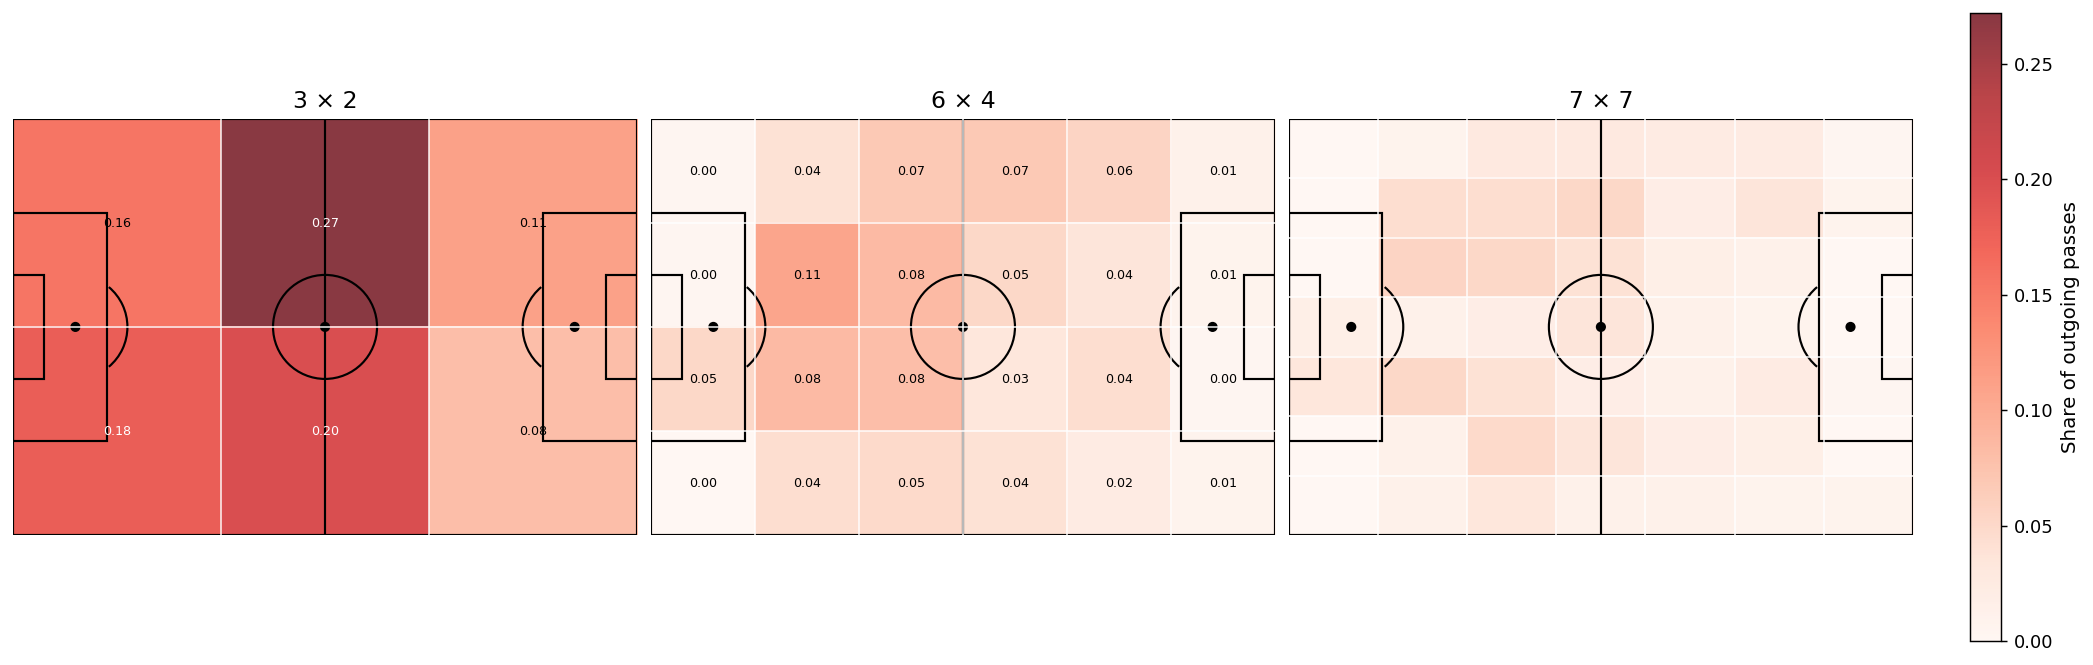

In [48]:
grid_vmax = max(
    grid_zone_tables["3 × 2"]["out_strength_share"].max(),
    grid_zone_tables["6 × 4"]["out_strength_share"].max(),
    grid_zone_tables["7 × 7"]["out_strength_share"].max(),
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=130, constrained_layout=True)

plot_zone_heatmap(
    grid_zone_tables["3 × 2"],
    metric="out_strength_share",
    n_cols=3,
    n_rows=2,
    ax=axes[0],
    cmap="Reds",
    title="3 × 2",
    vmin=0,
    vmax=grid_vmax,
    annotate=True,
    fmt="{:.2f}",
    colorbar=False,
)
plot_zone_heatmap(
    grid_zone_tables["6 × 4"],
    metric="out_strength_share",
    n_cols=6,
    n_rows=4,
    ax=axes[1],
    cmap="Reds",
    title="6 × 4",
    vmin=0,
    vmax=grid_vmax,
    annotate=True,
    fmt="{:.2f}",
    colorbar=False,
)
im = plot_zone_heatmap(
    grid_zone_tables["7 × 7"],
    metric="out_strength_share",
    n_cols=7,
    n_rows=7,
    ax=axes[2],
    cmap="Reds",
    title="7 × 7",
    vmin=0,
    vmax=grid_vmax,
    colorbar=False,
)

cbar = plt.colorbar(im, ax=axes, fraction=0.03, pad=0.03)
cbar.set_label("Share of outgoing passes")

plt.show()

The trade-offs are easy to see.

- The **3 × 2** grid is highly readable, but it hides a lot of local structure and produces a much denser graph.
- The **6 × 4** grid is a good classroom compromise.
- The **7 × 7** grid reveals more local spatial organization, but the network becomes much sparser and more sensitive to small sample sizes.

That is why "What grid should I use?" is not a purely technical question. It is a question about the balance between readability, granularity, stability, and comparability.

## 14. Extended example: extra time

Extra time is tactically different from regulation. The sample is smaller, fatigue is larger, and the score line is unstable.

That makes it a good reminder that comparisons across phases should use at least some **normalized** quantities when the time spans are very different. Here we will compare regulation and extra time for Argentina using out-strength **shares** on a 7 × 7 grid.

,total_passes,minutes,passes_per_minute,occupied_zones,density,reciprocity,out_strength_hhi
Regulation,397.0,90,4.411,48.0,0.097,0.476,0.030
Extra time,117.0,30,3.900,41.0,0.038,0.292,0.041


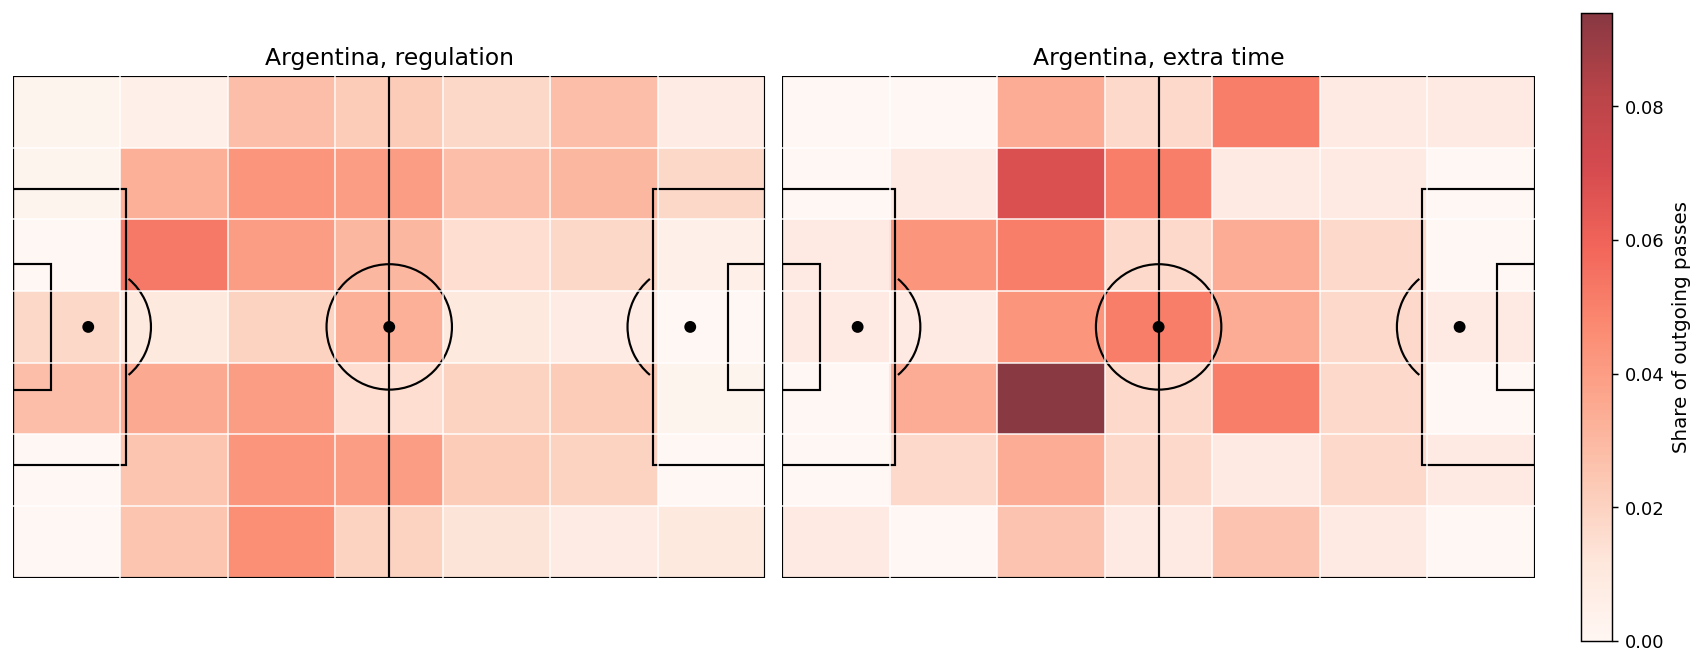

In [49]:
_, _, _, _, G_arg_reg_77, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[1, 2],
    n_cols=7,
    n_rows=7,
    completed_only=True,
    open_play_like=True,
)
_, _, _, _, G_arg_et_77, _ = build_zone_network_from_events(
    events_df,
    team_name=MAIN_TEAM,
    periods=[3, 4],
    n_cols=7,
    n_rows=7,
    completed_only=True,
    open_play_like=True,
)

zone_table_arg_reg_77 = zone_metric_table(G_arg_reg_77)
zone_table_arg_et_77 = zone_metric_table(G_arg_et_77)

reg_et_summary = pd.DataFrame(
    {
        "Regulation": network_summary(G_arg_reg_77),
        "Extra time": network_summary(G_arg_et_77),
    }
).T

reg_et_summary["minutes"] = [duration_minutes_for_periods([1, 2]), duration_minutes_for_periods([3, 4])]
reg_et_summary["passes_per_minute"] = reg_et_summary["total_passes"] / reg_et_summary["minutes"]

display(reg_et_summary[["total_passes", "minutes", "passes_per_minute", "occupied_zones", "density", "reciprocity", "out_strength_hhi"]].round(3))

vmax_reg_et = max(zone_table_arg_reg_77["out_strength_share"].max(), zone_table_arg_et_77["out_strength_share"].max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130, constrained_layout=True)

im = plot_zone_heatmap(
    zone_table_arg_reg_77,
    metric="out_strength_share",
    n_cols=7,
    n_rows=7,
    ax=axes[0],
    cmap="Reds",
    title="Argentina, regulation",
    vmin=0,
    vmax=vmax_reg_et,
    colorbar=False,
)
plot_zone_heatmap(
    zone_table_arg_et_77,
    metric="out_strength_share",
    n_cols=7,
    n_rows=7,
    ax=axes[1],
    cmap="Reds",
    title="Argentina, extra time",
    vmin=0,
    vmax=vmax_reg_et,
    colorbar=False,
)

cbar = plt.colorbar(im, ax=axes, fraction=0.032, pad=0.03)
cbar.set_label("Share of outgoing passes")

plt.show()

Even after normalizing by outgoing-pass share, the extra-time map is structurally different. That is exactly why it is dangerous to collapse regulation and extra time into one undifferentiated graph.

## 15. Optional research-style extensions

The core workflow is finished. The next step is to show how the same classroom pipeline scales into richer passing analysis.

We will do four compact extensions:

1. build a transparent **xPass-style proxy** to remind ourselves that not all passes are equally easy,
2. group similar passes into a few **pass archetypes** so that larger pass samples are easier to interpret,
3. compare the **same team across two matches** if the local files support it,
4. and stack zone-level metrics into a **long-format table** that is ready for larger-sample analysis.

The first two are inspired by Hudl StatsBomb's public note on Expected Pass and Pass Clustering, but what follows is intentionally much simpler. We do **not** have the proprietary model outputs in open data, and we only have a tiny local sample. So the goal is not to reproduce the production models exactly. The goal is to show how the logic extends beyond simple edge counts.


### Optional extension: an xPass-style proxy for pass difficulty

So far, every edge weight has been a **count**. That is useful, but it also treats a five-meter backward reset and a pressured, longer forward pass as if they were equally easy actions.

Hudl StatsBomb's public description of **Expected Pass (xPass)** motivates a richer view: pass completion depends on the conditions of the pass, including start location, target distance, angle, pressure, body part, and pattern of play. In this notebook we do **not** have their proprietary model outputs, and we only have a tiny local sample. So we will build a smaller, transparent classroom proxy.

We estimate a smoothed empirical completion rate for coarse pass bins defined by

- start $x$-band,
- pass length bin,
- forward/lateral/backward direction,
- and whether the passer was under pressure.

If $c_g$ is the number of completed passes in bin $g$, $n_g$ is the number of attempts in that bin, $\bar y$ is the global completion rate, and $\alpha$ is a smoothing constant, then our proxy baseline is

$$
\hat p_g = \frac{c_g + \alpha \bar y}{n_g + \alpha}.
$$

For each pass attempt $a$ in bin $g(a)$, we assign the classroom score

$$
\widehat{\mathrm{xPass}}_a = \hat p_{g(a)}.
$$

This is **not** Hudl StatsBomb's production xPass model. It is a deliberately simple teaching approximation that lets us ask two useful questions:

1. from which zones does a team attempt harder passes on average?
2. from which zones does the team complete more or fewer passes than this baseline would predict?


In [50]:
def add_pass_proxy_features(pass_df):
    """Add coarse, interpretable features for a classroom xPass-style proxy."""
    out = pass_df.copy()
    out["dx"] = out["end_x"] - out["x"]
    out["dy"] = out["end_y"] - out["y"]
    out["pass_length_calc"] = np.hypot(out["dx"], out["dy"])

    out["start_x_band"] = pd.cut(
        out["x"],
        bins=[0, 30, 60, 90, PITCH_LENGTH + 1e-9],
        labels=["D1", "D2", "D3", "D4"],
        include_lowest=True,
        right=False,
    )

    out["length_bin"] = pd.cut(
        out["pass_length_calc"],
        bins=[0, 10, 20, 35, np.inf],
        labels=["0-10", "10-20", "20-35", "35+"],
        include_lowest=True,
        right=False,
    )

    out["direction_bin"] = np.select(
        [out["dx"] > 5, out["dx"] < -5],
        ["forward", "backward"],
        default="lateral",
    )

    if "under_pressure" in out.columns:
        pressure_values = out["under_pressure"].apply(lambda value: bool(value) if pd.notna(value) else False)
    else:
        pressure_values = pd.Series(False, index=out.index)

    out["pressure_bin"] = np.where(
        pressure_values,
        "under_pressure",
        "not_under_pressure",
    )

    return out


def build_xpass_proxy_table(pass_df, alpha=8):
    """Estimate smoothed empirical completion rates for coarse pass bins."""
    group_cols = ["start_x_band", "length_bin", "direction_bin", "pressure_bin"]
    global_completion = float(pass_df["complete"].mean())

    proxy_table = (
        pass_df.groupby(group_cols, observed=False)
        .agg(
            attempts=("id", "size"),
            completions=("complete", "sum"),
        )
        .reset_index()
    )

    proxy_table["xpass_proxy"] = (
        proxy_table["completions"] + alpha * global_completion
    ) / (proxy_table["attempts"] + alpha)

    return proxy_table, group_cols, global_completion


available_event_paths = sorted((DATA_ROOT / "events").glob("*.json"))
baseline_frames = []
for path in available_event_paths:
    with open(path, "r", encoding="utf-8") as f:
        baseline_frames.append(flatten_statsbomb_events(json.load(f)))

baseline_events_df = pd.concat(baseline_frames, ignore_index=True)

baseline_pass_attempts = (
    baseline_events_df.loc[
        baseline_events_df["event_type"].eq("Pass")
        & ~baseline_events_df["pass_type_clean"].isin(SET_PIECE_PASS_TYPES)
    ].dropna(subset=["x", "y", "end_x", "end_y"]).copy()
)

baseline_pass_attempts = add_pass_proxy_features(baseline_pass_attempts)
xpass_proxy_table, xpass_group_cols, baseline_completion_rate = build_xpass_proxy_table(
    baseline_pass_attempts,
    alpha=8,
)

argentina_h1_attempts = (
    events_df.loc[
        events_df["event_type"].eq("Pass")
        & events_df["team_name"].eq(MAIN_TEAM)
        & events_df["period"].eq(1)
        & ~events_df["pass_type_clean"].isin(SET_PIECE_PASS_TYPES),
        [
            "id",
            "index",
            "period",
            "minute",
            "second",
            "match_time",
            "team_name",
            "player_name",
            "pass_recipient_name",
            "pass_type_clean",
            "play_pattern_name",
            "under_pressure",
            "x",
            "y",
            "end_x",
            "end_y",
            "complete",
        ],
    ]
    .dropna(subset=["x", "y", "end_x", "end_y"])
    .reset_index(drop=True)
)

argentina_h1_attempts = add_pass_proxy_features(argentina_h1_attempts)
argentina_h1_attempts = argentina_h1_attempts.merge(
    xpass_proxy_table[xpass_group_cols + ["attempts", "xpass_proxy"]],
    on=xpass_group_cols,
    how="left",
)

assert argentina_h1_attempts["xpass_proxy"].notna().all()

argentina_h1_attempts["xpass_residual"] = (
    argentina_h1_attempts["complete"].astype(float) - argentina_h1_attempts["xpass_proxy"]
)

argentina_h1_attempts = add_zone_columns(argentina_h1_attempts, n_cols=6, n_rows=4)

xpass_slice_summary = pd.DataFrame(
    {
        "baseline open-play-like attempts": [len(baseline_pass_attempts)],
        "baseline global completion rate": [baseline_completion_rate],
        "Argentina H1 attempts": [len(argentina_h1_attempts)],
        "Argentina H1 actual completion": [argentina_h1_attempts["complete"].mean()],
        "Argentina H1 mean proxy xPass": [argentina_h1_attempts["xpass_proxy"].mean()],
        "Argentina H1 net residual": [argentina_h1_attempts["xpass_residual"].sum()],
    },
    index=["summary"],
).T.rename(columns={"summary": "value"})

most_common_proxy_bins = (
    xpass_proxy_table.sort_values("attempts", ascending=False)
    .head(12)
    .reset_index(drop=True)
)

display(xpass_slice_summary.round(3))
display(most_common_proxy_bins.round({"xpass_proxy": 3}))


,value
baseline open-play-like attempts,1124.000
baseline global completion rate,0.799
Argentina H1 attempts,291.000
Argentina H1 actual completion,0.859
Argentina H1 mean proxy xPass,0.820
Argentina H1 net residual,11.500


,start_x_band,length_bin,direction_bin,pressure_bin,attempts,completions,xpass_proxy
0,D2,10-20,forward,not_under_pressure,97,85,0.870
1,D3,10-20,forward,not_under_pressure,71,55,0.777
2,D2,20-35,forward,not_under_pressure,58,44,0.764
3,D2,10-20,backward,not_under_pressure,52,52,0.973
4,D2,10-20,lateral,not_under_pressure,50,49,0.955
5,D3,20-35,forward,not_under_pressure,48,37,0.775
6,D3,10-20,backward,not_under_pressure,44,42,0.931
7,D1,10-20,forward,not_under_pressure,40,32,0.800
8,D1,20-35,forward,not_under_pressure,36,27,0.759
9,D2,20-35,lateral,not_under_pressure,35,34,0.939


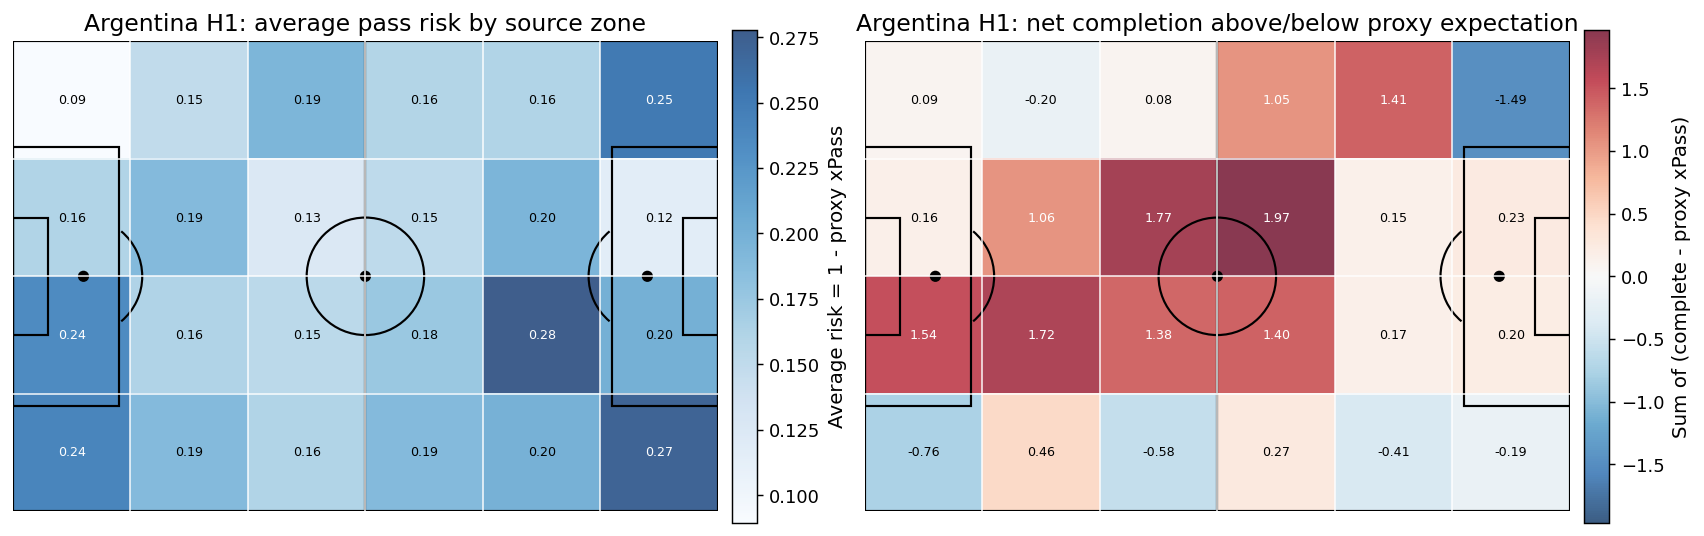

,zone_label,attempted_passes,mean_xpass_proxy,mean_pass_risk,residual_sum
18,x5_y3,15,0.722,0.278,0.168
23,x6_y4,3,0.728,0.272,-0.185
20,x6_y1,6,0.748,0.252,-1.490
3,x1_y4,1,0.759,0.241,-0.759
2,x1_y3,15,0.764,0.236,1.538
22,x6_y3,1,0.800,0.200,0.200
19,x5_y4,8,0.801,0.199,-0.409
17,x5_y2,11,0.805,0.195,0.147
8,x3_y1,21,0.806,0.194,0.083
7,x2_y4,13,0.811,0.189,0.462


In [51]:
xpass_zone_table = (
    argentina_h1_attempts.groupby(
        ["start_zone_id", "start_zone_label", "start_x_bin", "start_y_bin"],
        as_index=False,
    )
    .agg(
        attempted_passes=("id", "size"),
        actual_completion=("complete", "mean"),
        mean_xpass_proxy=("xpass_proxy", "mean"),
        mean_pass_risk=("xpass_proxy", lambda s: float((1 - s).mean())),
        residual_sum=("xpass_residual", "sum"),
        residual_mean=("xpass_residual", "mean"),
    )
    .rename(
        columns={
            "start_zone_id": "zone_id",
            "start_zone_label": "zone_label",
            "start_x_bin": "x_bin",
            "start_y_bin": "y_bin",
        }
    )
)

risk_vmin = float(xpass_zone_table["mean_pass_risk"].min())
risk_vmax = float(xpass_zone_table["mean_pass_risk"].max())
resid_abs = float(np.abs(xpass_zone_table["residual_sum"]).max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130, constrained_layout=True)

plot_zone_heatmap(
    xpass_zone_table,
    metric="mean_pass_risk",
    n_cols=6,
    n_rows=4,
    ax=axes[0],
    cmap="Blues",
    title="Argentina H1: average pass risk by source zone",
    vmin=risk_vmin,
    vmax=risk_vmax,
    annotate=True,
    fmt="{:.2f}",
    colorbar=True,
    cbar_label="Average risk = 1 - proxy xPass",
)

plot_zone_heatmap(
    xpass_zone_table,
    metric="residual_sum",
    n_cols=6,
    n_rows=4,
    ax=axes[1],
    cmap="RdBu_r",
    title="Argentina H1: net completion above/below proxy expectation",
    vmin=-resid_abs,
    vmax=resid_abs,
    annotate=True,
    fmt="{:.2f}",
    colorbar=True,
    cbar_label="Sum of (complete - proxy xPass)",
)

plt.show()

display(
    xpass_zone_table.sort_values("mean_pass_risk", ascending=False)[
        ["zone_label", "attempted_passes", "mean_xpass_proxy", "mean_pass_risk", "residual_sum"]
    ].head(10).round(3)
)


These maps are noisy because one half contains only 291 open-play-like attempts. But they still make the logic visible.

A count network told us where Argentina moved the ball often. The proxy xPass view adds a different question: **how difficult** were the attempted passes from each source zone? In a larger study, the same idea could be pushed further by defining difficulty-adjusted edge weights rather than using simple counts alone.


### Optional extension: pass archetypes via simple clustering

Raw pass plots quickly become dense. The same Hudl StatsBomb note argues that clustering similar passes can make larger pass samples much more interpretable. That is a different modeling move from a pitch network. A zone network fixes the spatial bins first and aggregates flow between them. Pass clustering keeps individual passes longer and groups them by geometric similarity.

For a compact classroom version, we cluster Argentina's completed open-play-like passes from the final using the normalized feature vector

$$
\mathbf{z}_a = \left(
\frac{x_a}{120},
\frac{y_a}{80},
\frac{\Delta x_a}{120},
\frac{\Delta y_a}{80},
\frac{\ell_a}{120}
\right),
$$

where $(x_a, y_a)$ is the start location of pass $a$, $(\Delta x_a, \Delta y_a)$ is its displacement, and $\ell_a$ is its length.

We will keep only a small number of clusters so that the plots stay readable. Again, this is not meant to reproduce the production pass-clustering model exactly. It is a compact way to summarize recurring **pass archetypes** inside the same match.


,cluster_id,passes,share,label
0,0,87,0.169,medium lateral angled pass from the left lane ...
1,3,86,0.167,medium lateral angled pass from the left lane ...
2,6,68,0.132,medium lateral angled pass from the right lane...
3,7,65,0.126,medium forward angled pass from the left lane ...
4,2,60,0.117,medium forward diagonal pass from the central ...
5,5,60,0.117,medium lateral flat pass from the right lane o...
6,1,55,0.107,medium forward angled pass from the central la...
7,4,33,0.064,long forward diagonal pass from the right lane...


cluster_id,0,3,6,7,2,5,1,4
phase,,,,,,,,
ET,0.162,0.171,0.162,0.128,0.188,0.051,0.077,0.060
H1,0.168,0.204,0.108,0.124,0.084,0.088,0.144,0.080
H2,0.177,0.102,0.150,0.129,0.116,0.218,0.068,0.041


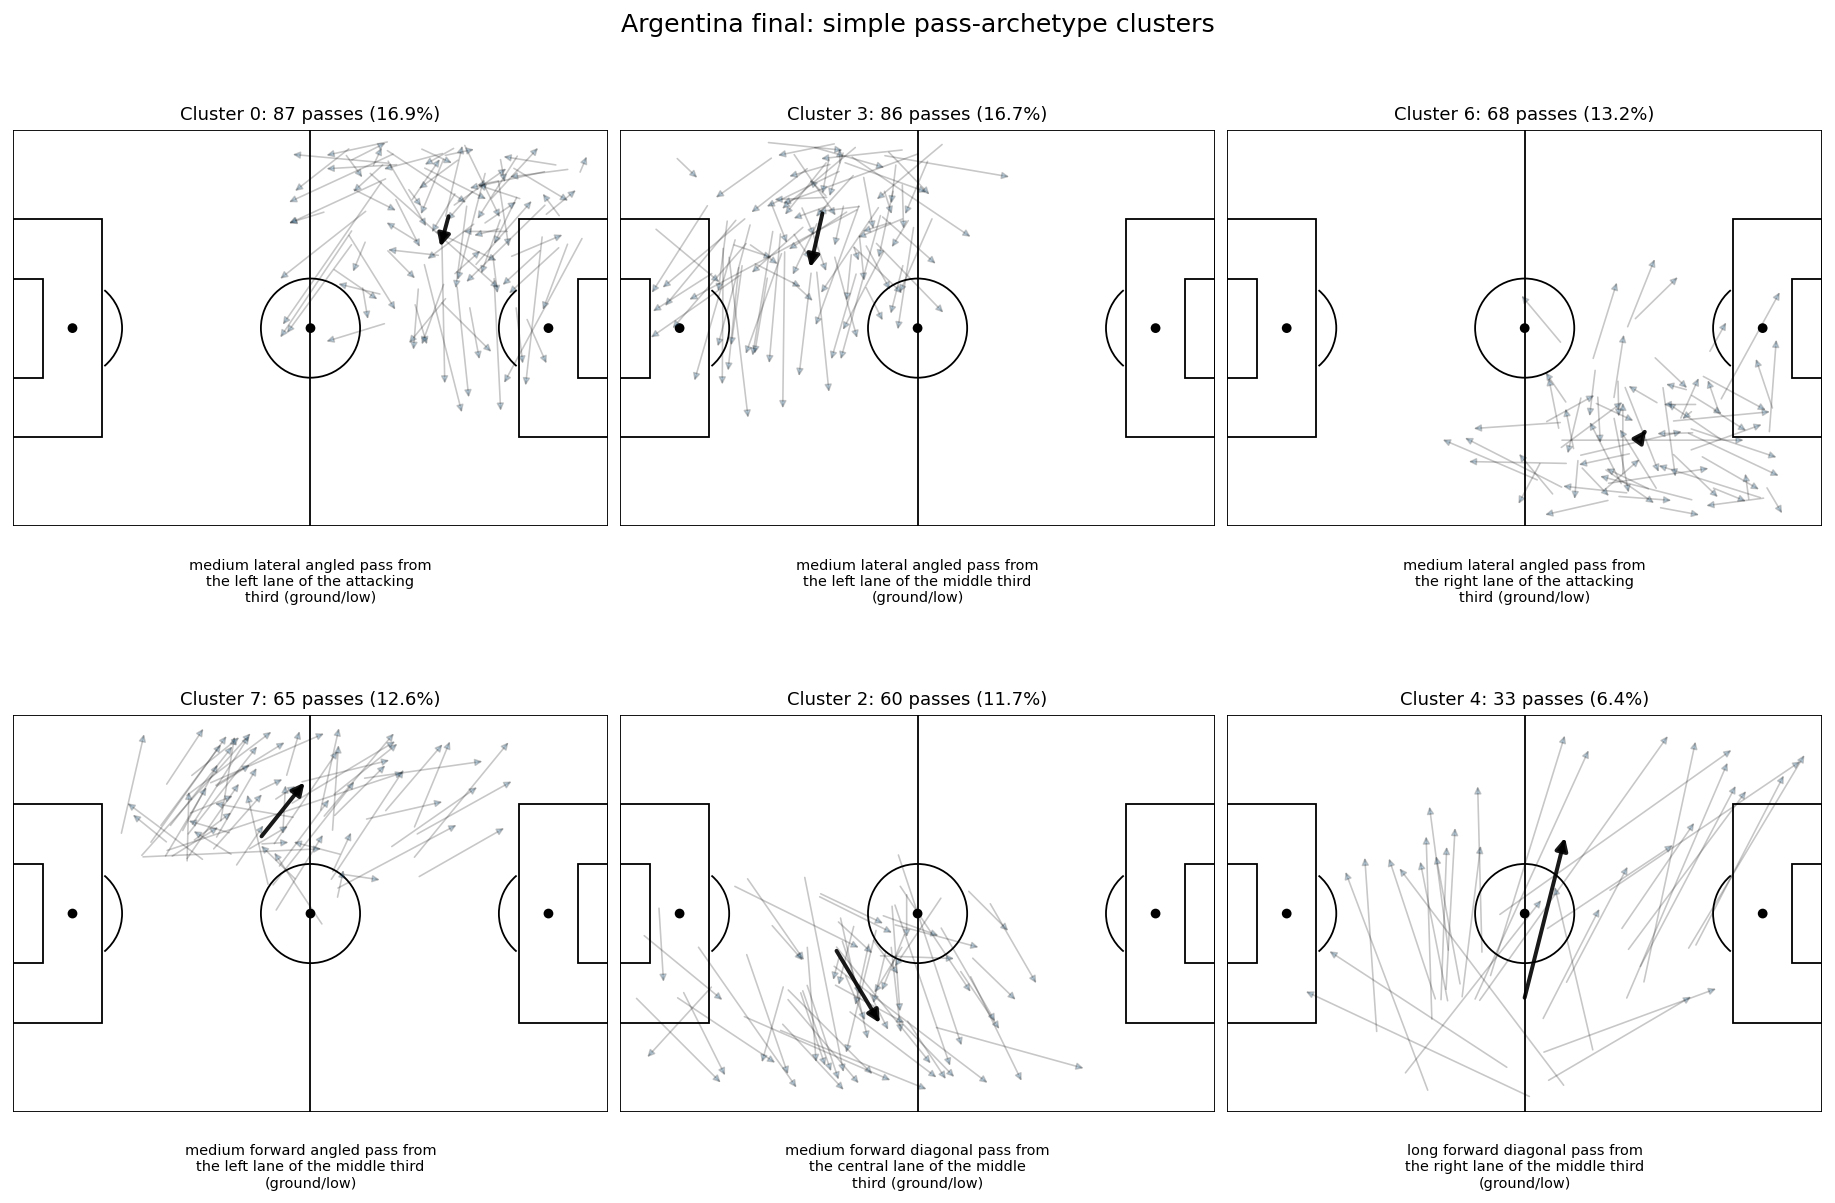

In [52]:
import textwrap
from sklearn.cluster import KMeans

def build_pass_cluster_features(pass_df):
    """Create normalized spatial features for a simple pass-archetype clustering."""
    out = pass_df.copy()
    out["dx"] = out["end_x"] - out["x"]
    out["dy"] = out["end_y"] - out["y"]
    out["pass_length_calc"] = np.hypot(out["dx"], out["dy"])

    X = np.column_stack(
        [
            out["x"] / PITCH_LENGTH,
            out["y"] / PITCH_WIDTH,
            out["dx"] / PITCH_LENGTH,
            out["dy"] / PITCH_WIDTH,
            out["pass_length_calc"] / PITCH_LENGTH,
        ]
    )
    return out, X


def describe_pass_cluster(center_row, height_mode):
    """Convert a cluster centroid into a short human-readable label."""
    start_x = float(center_row["x"])
    start_y = float(center_row["y"])
    dx = float(center_row["dx"])
    dy = float(center_row["dy"])
    length = float(center_row["pass_length_calc"])

    third = "defensive third" if start_x < 40 else ("middle third" if start_x < 80 else "attacking third")
    lane = "left lane" if start_y < PITCH_WIDTH / 3 else ("central lane" if start_y < 2 * PITCH_WIDTH / 3 else "right lane")
    direction = "forward" if dx > 5 else ("backward" if dx < -5 else "lateral")

    if length < 10:
        length_label = "short"
    elif length < 25:
        length_label = "medium"
    else:
        length_label = "long"

    if abs(dy) > 12 and abs(dx) > 5:
        shape_label = "diagonal"
    elif abs(dx) > abs(dy):
        shape_label = "vertical" if direction in {"forward", "backward"} else "flat"
    else:
        shape_label = "angled"

    if height_mode in {"Ground Pass", "Low Pass"}:
        height_label = "ground/low"
    elif pd.isna(height_mode):
        height_label = "mixed height"
    else:
        height_label = str(height_mode).lower()

    return f"{length_label} {direction} {shape_label} pass from the {lane} of the {third} ({height_label})"


argentina_final_completed = (
    events_df.loc[
        events_df["event_type"].eq("Pass")
        & events_df["team_name"].eq(MAIN_TEAM)
        & events_df["period"].isin([1, 2, 3, 4])
        & events_df["complete"]
        & ~events_df["pass_type_clean"].isin(SET_PIECE_PASS_TYPES),
        [
            "id",
            "period",
            "minute",
            "second",
            "match_time",
            "x",
            "y",
            "end_x",
            "end_y",
            "pass.height.name",
        ],
    ]
    .dropna(subset=["x", "y", "end_x", "end_y"])
    .reset_index(drop=True)
)

argentina_final_completed, cluster_X = build_pass_cluster_features(argentina_final_completed)

n_clusters = 8
cluster_model = KMeans(n_clusters=n_clusters, random_state=5442, n_init=30)
argentina_final_completed["cluster_id"] = cluster_model.fit_predict(cluster_X)
argentina_final_completed["phase"] = np.select(
    [
        argentina_final_completed["period"].eq(1),
        argentina_final_completed["period"].eq(2),
        argentina_final_completed["period"].isin([3, 4]),
    ],
    ["H1", "H2", "ET"],
    default="Other",
)

cluster_centers = pd.DataFrame(
    cluster_model.cluster_centers_,
    columns=["x", "y", "dx", "dy", "pass_length_calc"],
)
cluster_centers["x"] *= PITCH_LENGTH
cluster_centers["y"] *= PITCH_WIDTH
cluster_centers["dx"] *= PITCH_LENGTH
cluster_centers["dy"] *= PITCH_WIDTH
cluster_centers["pass_length_calc"] *= PITCH_LENGTH
cluster_centers["end_x"] = cluster_centers["x"] + cluster_centers["dx"]
cluster_centers["end_y"] = cluster_centers["y"] + cluster_centers["dy"]

cluster_counts = argentina_final_completed["cluster_id"].value_counts().sort_index()
cluster_height_mode = argentina_final_completed.groupby("cluster_id")["pass.height.name"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else np.nan
)

cluster_centers["passes"] = cluster_centers.index.map(cluster_counts)
cluster_centers["share"] = cluster_centers["passes"] / len(argentina_final_completed)
cluster_centers["height_mode"] = cluster_centers.index.map(cluster_height_mode)
cluster_centers["label"] = [
    describe_pass_cluster(cluster_centers.loc[idx], cluster_centers.loc[idx, "height_mode"])
    for idx in cluster_centers.index
]

cluster_summary = (
    cluster_centers.loc[:, ["passes", "share", "label", "height_mode", "x", "y", "end_x", "end_y", "pass_length_calc"]]
    .sort_values("passes", ascending=False)
    .reset_index()
    .rename(columns={"index": "cluster_id"})
)

phase_cluster_share = (
    pd.crosstab(argentina_final_completed["phase"], argentina_final_completed["cluster_id"], normalize="index")
    .reindex(columns=cluster_summary["cluster_id"].tolist())
    .fillna(0)
)

display(cluster_summary[["cluster_id", "passes", "share", "label"]].round({"share": 3}))
display(phase_cluster_share.round(3))

top_cluster_ids = cluster_summary["cluster_id"].head(5).tolist()
longest_cluster_id = int(cluster_summary.sort_values("pass_length_calc", ascending=False)["cluster_id"].iloc[0])
if longest_cluster_id not in top_cluster_ids:
    top_cluster_ids.append(longest_cluster_id)

fig, axes = plt.subplots(2, 3, figsize=(14, 9), dpi=130, constrained_layout=True)

for ax, cluster_id in zip(axes.flat, top_cluster_ids):
    draw_statsbomb_pitch(ax, lw=1.0)
    subset = argentina_final_completed.loc[argentina_final_completed["cluster_id"].eq(cluster_id)]

    for row in subset.itertuples():
        arrow = FancyArrowPatch(
            (row.x, row.y),
            (row.end_x, row.end_y),
            arrowstyle="-|>",
            mutation_scale=8,
            lw=0.9,
            alpha=0.22,
        )
        ax.add_patch(arrow)

    center_row = cluster_centers.loc[cluster_id]
    center_arrow = FancyArrowPatch(
        (center_row["x"], center_row["y"]),
        (center_row["end_x"], center_row["end_y"]),
        arrowstyle="-|>",
        mutation_scale=14,
        lw=2.2,
        color="black",
        alpha=0.9,
    )
    ax.add_patch(center_arrow)

    ax.set_title(
        f"Cluster {cluster_id}: {int(cluster_counts.loc[cluster_id])} passes ({cluster_counts.loc[cluster_id] / len(argentina_final_completed):.1%})",
        fontsize=10,
    )
    ax.text(
        0.5,
        -0.08,
        "\n".join(textwrap.wrap(cluster_centers.loc[cluster_id, "label"], width=34)),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=8,
    )

for ax in axes.flat[len(top_cluster_ids):]:
    ax.axis("off")

fig.suptitle("Argentina final: simple pass-archetype clusters", y=1.02, fontsize=14)
plt.show()


The contrast with the zone network is the main methodological point.

Pitch passing networks are **space-first**: we choose the cells first and then aggregate traffic between them. Pass archetypes are **pattern-first**: we keep individual passes and group similar trajectories later. Each simplification makes different things legible, so the two views are complementary rather than interchangeable.


In [53]:
if HAS_SEMIFINAL:
    with open(DATA_ROOT / "events" / f"{SEMIFINAL_MATCH_ID}.json", "r", encoding="utf-8") as f:
        semifinal_events = json.load(f)
    semifinal_events_df = flatten_statsbomb_events(semifinal_events)

    _, _, _, _, G_arg_semi_h1_77, _ = build_zone_network_from_events(
        semifinal_events_df,
        team_name=MAIN_TEAM,
        periods=[1],
        n_cols=7,
        n_rows=7,
        completed_only=True,
        open_play_like=True,
    )
    zone_table_arg_semi_h1_77 = zone_metric_table(G_arg_semi_h1_77)

    semifinal_vs_final = pd.DataFrame(
        [
            network_summary(G_arg_semi_h1_77),
            network_summary(G_arg_h1_77),
        ],
        index=[
            "Argentina vs Croatia, semifinal H1",
            "Argentina vs France, final H1",
        ],
    ).round(3)

    display(semifinal_vs_final)

    shared_vmin = min(zone_table_arg_semi_h1_77["out_harmonic"].min(), zone_table_arg_h1_77["out_harmonic"].min())
    shared_vmax = max(zone_table_arg_semi_h1_77["out_harmonic"].max(), zone_table_arg_h1_77["out_harmonic"].max())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130, constrained_layout=True)

    im = plot_zone_heatmap(
        zone_table_arg_semi_h1_77,
        metric="out_harmonic",
        n_cols=7,
        n_rows=7,
        ax=axes[0],
        cmap="Purples",
        title="Argentina vs Croatia, semifinal H1",
        vmin=shared_vmin,
        vmax=shared_vmax,
        colorbar=False,
    )
    plot_zone_heatmap(
        zone_table_arg_h1_77,
        metric="out_harmonic",
        n_cols=7,
        n_rows=7,
        ax=axes[1],
        cmap="Purples",
        title="Argentina vs France, final H1",
        vmin=shared_vmin,
        vmax=shared_vmax,
        colorbar=False,
    )

    cbar = plt.colorbar(im, ax=axes, fraction=0.032, pad=0.03)
    cbar.set_label("Outward harmonic centrality")

    plt.show()
else:
    print("Optional same-team match comparison skipped because the semifinal files are not available locally.")

Optional same-team match comparison skipped because the semifinal files are not available locally.


In [54]:
long_format_frames = []

long_slices = [
    ("Argentina_final_H1", zone_table_arg_h1_77, {"team": "Argentina", "match": "Final", "window": "H1"}),
    ("Argentina_final_H2", zone_table_arg_h2_77, {"team": "Argentina", "match": "Final", "window": "H2"}),
    ("France_final_H1", zone_table_fra_h1_77, {"team": "France", "match": "Final", "window": "H1"}),
]

if HAS_SEMIFINAL:
    long_slices.append(
        ("Argentina_semifinal_H1", zone_table_arg_semi_h1_77, {"team": "Argentina", "match": "Semifinal", "window": "H1"})
    )

for slice_name, table, extra_cols in long_slices:
    tmp = table.copy()
    tmp["slice_name"] = slice_name
    for key, value in extra_cols.items():
        tmp[key] = value
    long_format_frames.append(tmp)

zone_metric_long_df = pd.concat(long_format_frames, ignore_index=True)

zone_metric_long_tidy = zone_metric_long_df.melt(
    id_vars=["slice_name", "team", "match", "window", "zone_id", "zone_label", "x_bin", "y_bin"],
    value_vars=["out_strength_share", "in_strength_share", "out_harmonic", "betweenness"],
    var_name="metric",
    value_name="value",
)

display(zone_metric_long_tidy.head(20))
print(f"Long-format zone-metric table shape: {zone_metric_long_tidy.shape}")

,slice_name,team,match,window,zone_id,zone_label,x_bin,y_bin,metric,value
0,Argentina_final_H1,Argentina,Final,H1,1,x1_y1,1,1,out_strength_share,0.000
1,Argentina_final_H1,Argentina,Final,H1,2,x1_y2,1,2,out_strength_share,0.000
2,Argentina_final_H1,Argentina,Final,H1,3,x1_y3,1,3,out_strength_share,0.000
3,Argentina_final_H1,Argentina,Final,H1,4,x1_y4,1,4,out_strength_share,0.016
4,Argentina_final_H1,Argentina,Final,H1,5,x1_y5,1,5,out_strength_share,0.032
5,Argentina_final_H1,Argentina,Final,H1,6,x1_y6,1,6,out_strength_share,0.000
6,Argentina_final_H1,Argentina,Final,H1,7,x1_y7,1,7,out_strength_share,0.000
7,Argentina_final_H1,Argentina,Final,H1,8,x2_y1,2,1,out_strength_share,0.008
8,Argentina_final_H1,Argentina,Final,H1,9,x2_y2,2,2,out_strength_share,0.044
9,Argentina_final_H1,Argentina,Final,H1,10,x2_y3,2,3,out_strength_share,0.056


Long-format zone-metric table shape: (588, 10)


### Optional Appendix: transition matrices and a Markov-style view

A pitch passing network can also be read as a **transition matrix**. If we row-normalize the adjacency matrix, each row becomes an empirical transition distribution,

$$
P_{ij} = \frac{w_{ij}}{\sum_k w_{ik}},
$$

where $P_{ij}$ is the probability that the next completed pass ends in zone $j$, conditional on starting in zone $i$.

This does **not** make the match a perfect Markov chain. But it is still a useful way to think about recurrent spatial movement.

end_zone_label,x1_y1,x1_y2,x1_y3,x1_y4,x2_y1,x2_y2,x2_y3,x2_y4,x3_y1,x3_y2,...,x4_y3,x4_y4,x5_y1,x5_y2,x5_y3,x5_y4,x6_y1,x6_y2,x6_y3,x6_y4
start_zone_label,,,,,,,,,,,,,,,,,,,,,
x2_y2,0.0,0.0,0.111,0.0,0.111,0.259,0.148,0.000,0.222,0.037,...,0.000,0.000,0.000,0.000,0.0,0.0,0.00,0.0,0.0,0.0
x3_y2,0.0,0.0,0.000,0.0,0.000,0.095,0.000,0.000,0.095,0.429,...,0.048,0.048,0.000,0.000,0.0,0.0,0.00,0.0,0.0,0.0
x2_y3,0.0,0.0,0.048,0.0,0.000,0.429,0.143,0.048,0.000,0.048,...,0.000,0.000,0.000,0.000,0.0,0.0,0.00,0.0,0.0,0.0
x3_y3,0.0,0.0,0.000,0.0,0.000,0.150,0.150,0.000,0.050,0.100,...,0.050,0.050,0.050,0.000,0.0,0.0,0.05,0.0,0.0,0.0
x3_y1,0.0,0.0,0.000,0.0,0.353,0.000,0.059,0.000,0.235,0.294,...,0.000,0.000,0.000,0.000,0.0,0.0,0.00,0.0,0.0,0.0
x4_y1,0.0,0.0,0.000,0.0,0.059,0.000,0.000,0.000,0.294,0.118,...,0.000,0.000,0.059,0.059,0.0,0.0,0.00,0.0,0.0,0.0


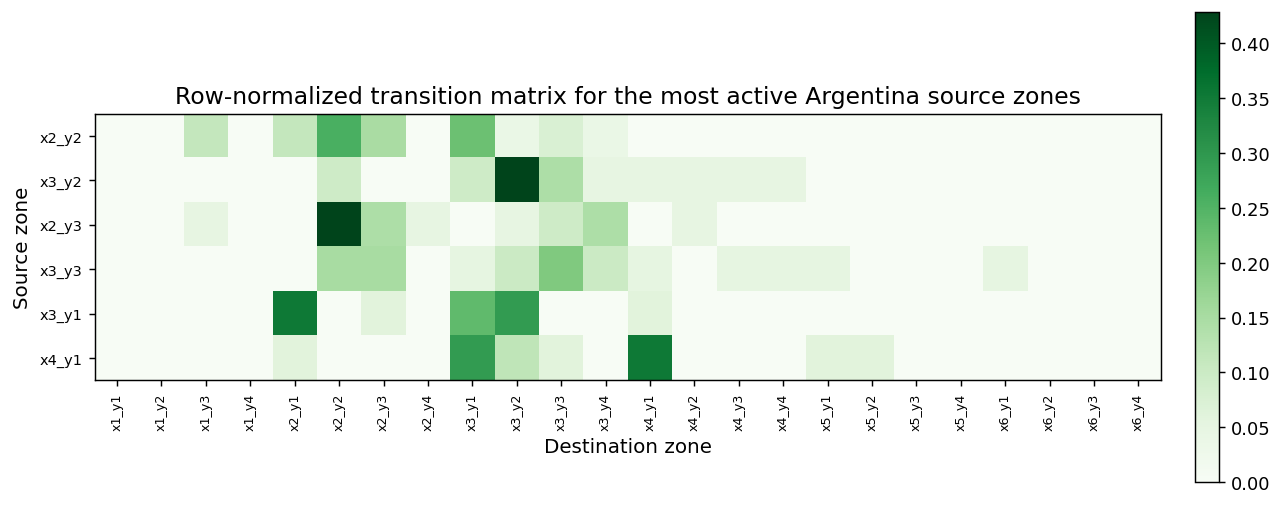

In [55]:
transition_matrix_64 = adjacency_64.div(adjacency_64.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

top_source_zones = zone_table_64.sort_values("out_strength", ascending=False)["zone_label"].head(6).tolist()
transition_focus = transition_matrix_64.loc[top_source_zones]

display(transition_focus.round(3))

fig, ax = plt.subplots(figsize=(10, 4), dpi=130)

im = ax.imshow(transition_focus.to_numpy(), cmap="Greens", vmin=0, vmax=transition_focus.to_numpy().max())
ax.set_xticks(range(len(transition_focus.columns)))
ax.set_yticks(range(len(transition_focus.index)))
ax.set_xticklabels(transition_focus.columns, rotation=90, fontsize=7)
ax.set_yticklabels(transition_focus.index, fontsize=8)
ax.set_xlabel("Destination zone")
ax.set_ylabel("Source zone")
ax.set_title("Row-normalized transition matrix for the most active Argentina source zones")
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
plt.tight_layout()
plt.show()

## 16. Closing synthesis

At this point, you should be able to see the whole chain clearly.

We started with a raw event log. We inspected the JSON structure, extracted the fields we needed, and noted that the data contain much more than any single graph can keep. We then discretized the pitch, first on a toy example and then on a real match slice, and turned repeated zone-to-zone transitions into a directed weighted graph.

That construction made several modeling choices visible:

- the nodes were pitch zones rather than players,
- the edges were zone-to-zone pass transitions,
- the weights were pass counts,
- the time window was chosen explicitly,
- the pass definition excluded obvious set pieces,
- self-loops were kept for local circulation but removed for path-based metrics,
- and the grid resolution was treated as part of the model.

We then used several complementary visualizations and a compact set of measures to interpret the network. Strength, degree, density, reciprocity, harmonic centrality, betweenness, and HHI all emphasized different aspects of the same object. Mapping those quantities back onto the pitch let us study **space** directly.

The player-vs-pitch comparison showed why the two representations are not substitutes. The player network preserves identity and role relationships. The pitch network preserves territorial flow and spatial bridges. Each is useful precisely because each leaves something out.

The optional extensions pushed the same lesson a little further. An xPass-style proxy reminded us that not all passes are equally easy, and the pass-archetype clusters showed that we can also summarize repeated **shapes** of ball movement rather than only zone-to-zone counts.

Finally, the time-slice, completed-vs-attempted, grid-resolution, and extra-time sections all reinforced the same idea: pitch passing networks are powerful because they simplify. And because they simplify, they necessarily omit part of the game.

That is not a flaw to hide. It is the main methodological fact to understand.


## 17. References

- Buldú, J. M., Busquets, J., Martínez, J. H., Herrera-Diestra, J. L., Echegoyen, I., Galeano, J., & Luque, J. (2018). *Using network science to analyse football passing networks: Dynamics, space, time and the multilayer nature of the game*. *Frontiers in Psychology, 9*, 1900. https://doi.org/10.3389/fpsyg.2018.01900
- Caicedo-Parada, S., Lago-Peñas, C., & Ortega-Toro, E. (2020). *Passing Networks and Tactical Action in Football: A Systematic Review*. *International Journal of Environmental Research and Public Health, 17*(18), 6649. https://doi.org/10.3390/ijerph17186649
- Garrido, D., Antequera, D. R., Busquets, J., López del Campo, R., Resta Serra, R., Jos Vielcazat, S., & Buldú, J. M. (2020). *Consistency and identifiability of football teams: A network science perspective*. *Scientific Reports, 10*, 19735. https://doi.org/10.1038/s41598-020-76835-3
- Grund, T. U. (2012). *Network structure and team performance: The case of English Premier League soccer teams*. *Social Networks, 34*(4), 682–690. https://doi.org/10.1016/j.socnet.2012.08.004
- Herrera-Diestra, J. L., Echegoyen, I., Martínez, J. H., Garrido, D., Busquets, J., Io, F. S., & Buldú, J. M. (2020). *Pitch networks reveal organizational and spatial patterns of Guardiola's F.C. Barcelona*. *Chaos, Solitons & Fractals, 138*, 109934. https://doi.org/10.1016/j.chaos.2020.109934
- Hudl StatsBomb. (2023, October 5). *Hudl Statsbomb Release New Models: Expected Pass (xPass) and Pass Clustering*. Hudl.
- Huang, K., Zhou, C., Gong, B., Yang, X., Buldú, J. M., & Gómez Ruano, M. Á. (2025). *The impact of team quality, match outcomes, and match location on pitch-passing networks*. *Scientific Reports, 15*, 23199. https://doi.org/10.1038/s41598-025-04507-1
- López Peña, J., & Touchette, H. (2012). *A network theory analysis of football strategies*. arXiv:1206.6904. https://arxiv.org/abs/1206.6904
- Narizuka, T., Yamamoto, K., & Yamazaki, Y. (2014). *Statistical properties of position-dependent ball-passing networks in football games*. *Physica A: Statistical Mechanics and its Applications, 412*, 157–168. https://doi.org/10.1016/j.physa.2014.06.037
- StatsBomb. *open-data* [GitHub repository]. https://github.com/statsbomb/open-data
